# Independent Cherenkov and ice-absorption study

**Research question:** How does the chosen wavelength interval change the
distribution of photons that could reach a sensor, particularly below 250 nm
and above 700 nm? The 160–1000 nm study range is a chosen reference interval,
not a physical cutoff. All retained fractions depend on that interval and on
the assumed absorption law.

Photons are aimed at an ideal sensor and travel along straight paths. The
simulation includes absorption, but no scattering, Cherenkov cone, track
length, sensor geometry, angular acceptance, or quantum efficiency. An
"arrival" is therefore survival to a perfect sensor, not a realistic DOM hit.

Run from the top after changing settings. Section 1 holds editable variables;
Section 2 contains models and calculations; Section 3 holds the grouped
figures; Section 4 contains pooled and individual-wavelength absorption PDFs.
The headings can be collapsed in VS Code.


## 1. Variables and settings

In [2]:
import numpy as np
try:
    from numpy import trapezoid as integrate_trapezoid
except ImportError:
    from numpy import trapz as integrate_trapezoid
import matplotlib.pyplot as plt
import yaml
import pandas as pd
from pathlib import Path

# Project location and reproducible source/Monte Carlo settings.
PROJECT_ROOT = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in (PROJECT_ROOT, *PROJECT_ROOT.parents)
     if (p / 'independent_cherenkov_simulation.ipynb').is_file()),
    PROJECT_ROOT,
)
rng = np.random.default_rng(42)
STUDY_WAVELENGTH_MIN = 160.0
STUDY_WAVELENGTH_MAX = 1000.0
BETA = 1.0
N_PHOTONS = 100_000
distances_m = np.array([1, 10, 50, 100, 200, 500], dtype=float)

# One measured layer near 2200 m and comparison distances.
ACK_DEPTH_M = 2205
D_ZOOM = 100.0
D_SENSOR = 100.0
selected_wavelengths = np.array([195, 205, 225, 250, 300, 400, 500, 700],
                                dtype=float)
N_PER_WAVELENGTH = 100_000
UV_SCENARIOS = {
    'Constant below 313': 0.0,
    'Continue power law': 1.08,
    'Steeper UV rise': 2.0,
}

# Depth profiles and three-model comparison.
DEPTH_REFERENCE_NM = 405.
DEPTH_INTERVAL_M = (1450., 2330.)
DEPTH_VIOLIN_NM = np.array([325., 350., 405., 450., 500., 550.])
COMPARISON_WAVELENGTH_NM = DEPTH_REFERENCE_NM
EXTENDED_INPUT_RANGE_NM = (500., 700.)  # New comparison plot; beyond 560 nm is a formula continuation.
N_INPUT_POINT_MC_PHOTONS = 2_000  # Per model and tabulated wavelength; controls MC error bars.
INPUT_POINT_MC_RANDOM_SEED = 2034
COMPARISON_DEPTH_RANGE_M = DEPTH_INTERVAL_M
COMPARISON_PPC_ROOT = PROJECT_ROOT.parent / 'ppc'
DUST_LOGGER_FILE = PROJECT_ROOT / 'dust_logger.txt'

# Published, logger-derived IceCube composite: separate dust-concentration axis.
PUBLIC_DUST_STRING = 86  # Central depth-reference string on the Dust Map site.
PUBLIC_DUST_PROFILE_FILE = (
    PROJECT_ROOT / 'data/dustmap2011' / f'string_{PUBLIC_DUST_STRING}_dust.dat'
)
PUBLIC_DUST_BIN_WIDTH_M = 1.0  # Display arithmetic means in 1 m depth bins.

# Dust profiles near AMANDA, whose centre is closest to IceCube String 48.
AMANDA_REFERENCE_STRING = 48
AMANDA_DUST_STRINGS = (48, 50, 66, 86)  # Mapped vicinity, nearby logged holes, old reference.
AMANDA_DUST_PROFILE_DIR = PROJECT_ROOT / 'data/dustmap2011'
AMANDA_STRING_POSITIONS_FILE = AMANDA_DUST_PROFILE_DIR / 'icecube_string_positions.csv'

# Published Figure 6b compared with the public Dust Map, without a fitted calibration.
PAPER_DUST_DATA_DIR = PROJECT_ROOT / 'data/icecube_glaciology2013'
PAPER_DUST_DIGITISED_FILE = PAPER_DUST_DATA_DIR / 'figure6b_south_pole_digitised.csv'
PAPER_DUST_PROFILE_STRINGS = (86, 48)  # Paper's central reference and AMANDA vicinity.
PAPER_DUST_BIN_WIDTH_M = 10.  # Figure pixels represent about 3.75 m in depth.

# Final pooled-wavelength PDF comparison.
PDF_WAVELENGTH_RANGE_NM = (313., 560.)
N_PDF_PHOTONS = 100_000  # Same emitted wavelengths reused for each model.
PDF_RANDOM_SEED = 2029
PDF_BIN_COUNT = 95
PDF_COMPONENT_MODEL = 'WB + Ackermann dust'  # Change to either other dusty model.

# Linear-axis range for the pooled PDF; restored wavelength-specific PDFs below.
PDF_PLOT_MAX_M = 1000.
PER_WL_WAVELENGTHS_NM = np.array([325., 405., 500., 510., 520., 530., 540., 550., 560.])
N_PER_WL_PDF_SAMPLES = 40_000  # Per model and wavelength.
PER_WL_PDF_RANDOM_SEED = 2029

# Fixed-wavelength PDF comparison and dust/ice crossover scan.
PDF_SINGLE_WAVELENGTH_NM = 550.
PDF_SINGLE_PLOT_MAX_M = 200.
PDF_SINGLE_BIN_COUNT = 90
PDF_CROSSOVER_RANGE_NM = (313., 560.)
PDF_CROSSOVER_GRID_POINTS = 2000
PDF_CROSSOVER_RANDOM_SEED = 2030

# Per-wavelength PDF residuals relative to WB pure ice.
PDF_RESIDUAL_MAX_M = 1000.
PDF_RESIDUAL_MIN_M = 200.
PDF_RESIDUAL_MEAN_MULTIPLIER = 6.
PDF_RESIDUAL_POINTS = 600
PDF_COMPARISON_BIN_COUNT = 100  # Shared Monte Carlo bins per wavelength.
PDF_COLORS = {
    'WB pure ice': 'black',
    'WB + Ackermann dust': 'tab:blue',
    'Ackermann original': 'tab:green',
    'SPICE BFR-v2 scalar': 'tab:orange',
}
PDF_LINESTYLES = {
    'WB pure ice': '-',
    'WB + Ackermann dust': '--',
    'Ackermann original': '-.',
    'SPICE BFR-v2 scalar': ':',
}


## 2. Model code and calculations

### Warren–Brandt ice data from GitHub

The next cell loads the project-local file `data/refractiveindex.info/Warren-2008.yml`.
It is already downloaded; subsequent runs work offline. If the file is missing,
the cell downloads that one file from the pinned GitHub revision and verifies its
SHA-256 hash before saving it. Run the notebook with the project folder as its
working directory, or set `PROJECT_ROOT` below explicitly.

Source: [refractiveindex.info database — Warren-2008.yml](https://github.com/polyanskiy/refractiveindex.info-database/blob/c5c2f188e848453def5970e347399d653df2ffc2/database/data/main/H2O/nk/Warren-2008.yml).
The file tabulates wavelength in micrometres, real index **n**, and extinction
coefficient **k** for water ice at **−7 °C**. The loader converts wavelength to nm.
This is the pure-ice optical baseline, not the depth-dependent IceCube dust model.

No `refract` or `refractiveindex` Python wrapper is required. The imports use
NumPy, Matplotlib, and PyYAML. If `yaml` is missing in your Conda kernel, run
`conda install -n icecube-analysis -c conda-forge pyyaml` in Anaconda Prompt,
then restart the notebook kernel. The existing Conda YAML already includes it.


**Provenance and limits:** [Warren and Brandt (2008)](https://doi.org/10.1029/2007JD009744)
compiled these constants for ice near 266 K. From roughly 202–390 nm the
tabulated $k=2\times10^{-11}$ is an upper-limit placeholder, not an exact
measurement of pure-ice absorption. The 390–600 nm values use snow-transmission
inference from [Warren et al. (2006)](https://www.atmos.washington.edu/~sgw/PAPERS/2006_icemcx.pdf),
whose authors treated the resulting ice absorption as a conditional upper
bound because trace impurities may still absorb light. Interpolation does not
remove these source uncertainties.


In [3]:
# Project-local Warren & Brandt (2008) data; automatic download only if missing.
import hashlib
from urllib.request import Request, urlopen
from urllib.error import URLError

# Permit launching from a subfolder of the project.
WB_COMMIT = "c5c2f188e848453def5970e347399d653df2ffc2"
WB_SHA256 = "a8577eaa1fabb9245957397344ce23efb20dd4c57cd7f442710d2d2373e0bbd6"
WB_URL = (
    "https://raw.githubusercontent.com/polyanskiy/refractiveindex.info-database/"
    + WB_COMMIT + "/database/data/main/H2O/nk/Warren-2008.yml"
)
warren_file = PROJECT_ROOT / "data" / "refractiveindex.info" / "Warren-2008.yml"

if not warren_file.exists():
    try:
        request = Request(WB_URL, headers={"User-Agent": "Cherenkov-notebook"})
        with urlopen(request, timeout=60) as response:
            content = response.read()
    except URLError as exc:
        raise RuntimeError(
            f"Download failed. Download {WB_URL} manually to {warren_file}, "
            "then rerun this cell."
        ) from exc
    if hashlib.sha256(content).hexdigest() != WB_SHA256:
        raise ValueError("Downloaded data does not match the pinned SHA-256 hash.")
    warren_file.parent.mkdir(parents=True, exist_ok=True)
    temporary = warren_file.with_suffix(".download")
    temporary.write_bytes(content)
    temporary.replace(warren_file)

if hashlib.sha256(warren_file.read_bytes()).hexdigest() != WB_SHA256:
    raise ValueError("Local Warren-2008.yml differs from the pinned data; check the file before continuing.")
print("Optical data:", warren_file)
print("Verified GitHub revision:", WB_COMMIT)

with open(
    warren_file,
    "r",
    encoding="utf-8"
) as f:

    warren_yaml = yaml.safe_load(f)


rows = []

for section in warren_yaml["DATA"]:

    if "tabulated nk" in section["type"].lower():

        for line in section["data"].strip().splitlines():

            values = line.split()

            wavelength_um = float(values[0])
            n = float(values[1])
            k = float(values[2])

            rows.append(
                [
                    wavelength_um,
                    n,
                    k
                ]
            )


data = np.asarray(
    rows,
    dtype=float
)

data = data[
    np.argsort(data[:, 0])
]


# micrometres -> nanometres
WB_WAVELENGTH_NM = (
    data[:, 0] * 1000.0
)

WB_N = data[:, 1]
WB_K = data[:, 2]


print(
    f"Loaded {len(WB_WAVELENGTH_NM)} "
    f"Warren-Brandt optical points"
)

print(
    f"Available wavelength range: "
    f"{WB_WAVELENGTH_NM.min():.1f} "
    f"to {WB_WAVELENGTH_NM.max():.3g} nm"
)


# Validate the table before any interpolation or log(k) calculations.
assert data.ndim == 2 and data.shape[1] == 3 and len(data) > 2
assert np.all(np.isfinite(data))
assert np.all(np.diff(WB_WAVELENGTH_NM) > 0)
assert np.all(WB_N > 0) and np.all(WB_K > 0)
assert WB_WAVELENGTH_NM.min() <= 160 and WB_WAVELENGTH_NM.max() >= 1000
print("Dataset comment:", warren_yaml.get("COMMENTS", "").strip())
print("Optical data validation passed.")

Optical data: C:\Users\JonatanEmilSvendsen\OneDrive - Sparrow Quantum Aps\Desktop\Master Project\data\refractiveindex.info\Warren-2008.yml
Verified GitHub revision: c5c2f188e848453def5970e347399d653df2ffc2
Loaded 486 Warren-Brandt optical points
Available wavelength range: 44.3 to 2e+09 nm
Dataset comment: Water ice (solid H<sub>2</sub>O) at -7 °C
Optical data validation passed.


In [4]:
def refractive_index_ice(wavelength_nm):
    """
    Real refractive index of ice from
    Warren & Brandt (2008).

    No extrapolation is allowed.
    """

    wavelength_nm = np.asarray(
        wavelength_nm,
        dtype=float
    )

    if np.any(wavelength_nm < WB_WAVELENGTH_NM.min()):
        raise ValueError(
            "Requested wavelength is below "
            "the Warren-Brandt data range."
        )

    if np.any(wavelength_nm > WB_WAVELENGTH_NM.max()):
        raise ValueError(
            "Requested wavelength is above "
            "the Warren-Brandt data range."
        )

    return np.interp(
        wavelength_nm,
        WB_WAVELENGTH_NM,
        WB_N
    )

In [5]:
def extinction_coefficient_ice(wavelength_nm):
    """Warren–Brandt k, interpolated in log(k); no extrapolation."""
    wavelength_nm = np.asarray(wavelength_nm, dtype=float)

    if np.any((wavelength_nm < WB_WAVELENGTH_NM.min()) |
              (wavelength_nm > WB_WAVELENGTH_NM.max())):
        raise ValueError("Wavelength outside Warren–Brandt range.")

    if np.any(WB_K <= 0):
        raise ValueError("Log interpolation requires positive tabulated k.")

    return np.exp(np.interp(
        wavelength_nm, WB_WAVELENGTH_NM, np.log(WB_K)
    ))

In [6]:
def pure_ice_absorption_coefficient(wavelength_nm):
    """
    Intrinsic absorption coefficient of pure ice [1/m].

    a = 4*pi*k/lambda
    """

    wavelength_nm = np.asarray(
        wavelength_nm,
        dtype=float
    )

    k = extinction_coefficient_ice(
        wavelength_nm
    )

    wavelength_m = (
        wavelength_nm * 1e-9
    )

    return (
        4.0
        * np.pi
        * k
        / wavelength_m
    )

In [7]:
def pure_ice_absorption_length(wavelength_nm):

    a = pure_ice_absorption_coefficient(
        wavelength_nm
    )

    return 1.0 / a

### 2.1 Source spectrum and pure-ice survival

The Frank–Tamm wavelength density is proportional to
$\lambda^{-2}[1-1/(\beta^2n^2(\lambda))]$ above threshold, here with
$\beta=1$. The fixed `N_PHOTONS` samples its *relative* wavelengths, not the
absolute light yield of a charged track. Histogram bins and numerical grids
do not discretize the emitted wavelengths.

For each photon the notebook converts Warren–Brandt's imaginary refractive
index into $a_{\rm WB}=4\pi k/\lambda$ with $\lambda$ in metres, then draws
$d_{\rm abs}=-\ln U/a$. An ideal sensor at distance $D$ is reached when
$d_{\rm abs}>D$; the predicted survival probability is $e^{-aD}$. The same
emitted photons and sampled distances are compared at all sensor distances.
The plotted $L=1/a$ is a *mean*, not an individual photon distance.


In [8]:
# ============================================================
# FRANK-TAMM CHERENKOV WAVELENGTH SPECTRUM
# ============================================================

def cherenkov_spectrum(
    wavelength_nm,
    beta=1.0
):
    """
    Relative Cherenkov photon production
    per unit wavelength.

    Based directly on the Frank-Tamm
    wavelength spectrum from the PDG.

    The overall constant is omitted because
    we currently only need the wavelength PDF.
    """

    wavelength_nm = np.asarray(
        wavelength_nm,
        dtype=float
    )

    n = refractive_index_ice(
        wavelength_nm
    )

    cherenkov_factor = (
        1.0
        - 1.0 / (
            beta**2 * n**2
        )
    )


    # No Cherenkov emission below threshold
    allowed = (
        beta * n > 1.0
    )

    spectrum = np.zeros_like(
        wavelength_nm,
        dtype=float
    )

    spectrum[allowed] = (
        cherenkov_factor[allowed]
        / wavelength_nm[allowed]**2
    )

    return spectrum

In [9]:
wavelength_abs = np.linspace(
    STUDY_WAVELENGTH_MIN,
    STUDY_WAVELENGTH_MAX,
    10000
)

L_abs = pure_ice_absorption_length(
    wavelength_abs
)

In [10]:
wavelength_plot = np.linspace(
    STUDY_WAVELENGTH_MIN,
    STUDY_WAVELENGTH_MAX,
    10000
)

source = cherenkov_spectrum(
    wavelength_plot,
    beta=BETA
)

# Normalize only for plotting
source_pdf = (
    source
    / integrate_trapezoid(
        source,
        wavelength_plot
    )
)

In [11]:
def sample_cherenkov_wavelengths(
    number_of_photons,
    wavelength_min,
    wavelength_max,
    beta=1.0,
    rng=rng
):
    """
    Sample continuous Cherenkov wavelengths
    directly from the Frank-Tamm spectrum.

    No wavelength bins are assigned to photons.
    """

    # Dense grid used ONLY to estimate
    # the maximum of the probability density.
    test_grid = np.linspace(
        wavelength_min,
        wavelength_max,
        20000
    )

    spectrum_max = (
        1.05
        * np.max(
            cherenkov_spectrum(
                test_grid,
                beta
            )
        )
    )


    accepted = []

    while len(accepted) < number_of_photons:

        remaining = (
            number_of_photons
            - len(accepted)
        )

        # Generate a larger batch for efficiency
        batch_size = max(
            10000,
            remaining * 3
        )


        # Continuous candidate wavelengths
        candidates = rng.uniform(
            wavelength_min,
            wavelength_max,
            batch_size
        )


        probabilities = (
            cherenkov_spectrum(
                candidates,
                beta
            )
        )


        random_height = rng.uniform(
            0,
            spectrum_max,
            batch_size
        )


        keep = (
            random_height
            < probabilities
        )

        accepted.extend(
            candidates[keep]
        )


    return np.asarray(
        accepted[:number_of_photons]
    )

In [12]:
photon_wavelengths = (
    sample_cherenkov_wavelengths(
        N_PHOTONS,
        STUDY_WAVELENGTH_MIN,
        STUDY_WAVELENGTH_MAX,
        beta=BETA
    )
)


print(
    photon_wavelengths[:10]
)

[319.15594163 733.29622334 277.39208623 166.18430659 256.20526177
 208.97430302 179.07814143 233.62593223 259.12495778 762.18775889]


In [13]:
# ============================================================
# NUMERICAL VALIDATION OF WAVELENGTH SAMPLER
# ============================================================

validation_edges = np.array([
    160,
    200,
    250,
    300,
    400,
    500,
    600,
    700,
    800,
    1000
], dtype=float)


print(
    "Band          Theory       Monte Carlo     Difference"
)

print(
    "------------------------------------------------------"
)

full_wl = np.linspace(
    STUDY_WAVELENGTH_MIN,
    STUDY_WAVELENGTH_MAX,
    20000
)

full_integral = integrate_trapezoid(
    cherenkov_spectrum(
        full_wl,
        beta=BETA
    ),
    full_wl
)


for low, high in zip(
    validation_edges[:-1],
    validation_edges[1:]
):

    # Dense grid for numerical integration
    wl = np.linspace(
        low,
        high,
        5000
    )

    theory_band = integrate_trapezoid(
        cherenkov_spectrum(
            wl,
            beta=BETA
        ),
        wl
    )

    # Normalize relative to entire study range
   
    theory_fraction = (
        theory_band / full_integral
    )


    monte_carlo_fraction = np.mean(
        (photon_wavelengths >= low)
        &
        (photon_wavelengths < high)
    )


    difference = (
        monte_carlo_fraction
        - theory_fraction
    )


    print(
        f"{low:4.0f}-{high:4.0f} nm   "
        f"{theory_fraction:9.5f}     "
        f"{monte_carlo_fraction:9.5f}     "
        f"{difference:+.5f}"
    )

Band          Theory       Monte Carlo     Difference
------------------------------------------------------
 160- 200 nm     0.27373       0.27342     -0.00031
 200- 250 nm     0.19410       0.19341     -0.00069
 250- 300 nm     0.12318       0.12355     +0.00037
 300- 400 nm     0.14918       0.14994     +0.00076
 400- 500 nm     0.08765       0.08818     +0.00053
 500- 600 nm     0.05783       0.05892     +0.00109
 600- 700 nm     0.04104       0.04000     -0.00104
 700- 800 nm     0.03064       0.03037     -0.00027
 800-1000 nm     0.04265       0.04221     -0.00044


In [14]:
a_photons = pure_ice_absorption_coefficient(photon_wavelengths)
assert np.all(np.isfinite(a_photons)) and np.all(a_photons >= 0)

# generator.random returns values in [0, 1); 1-U is in (0, 1].
u = 1.0 - rng.random(len(photon_wavelengths))

d_abs_m = np.full(len(photon_wavelengths), np.inf)
absorbing = a_photons > 0
d_abs_m[absorbing] = -np.log(u[absorbing]) / a_photons[absorbing]

arrives = {
    D: d_abs_m > D
    for D in distances_m
}

In [15]:
edges_nm = np.linspace(STUDY_WAVELENGTH_MIN, STUDY_WAVELENGTH_MAX, 85)
width_nm = np.diff(edges_nm)

emitted_counts, _ = np.histogram(photon_wavelengths, bins=edges_nm)
emitted_density = emitted_counts / (len(photon_wavelengths) * width_nm)

In [16]:
print(
    "D [m]   arrive   survival   <250 nm       250–700 nm     >700 nm"
)
for D in distances_m:
    mask = arrives[D]
    n = mask.sum()
    wl = photon_wavelengths[mask]

    counts = np.array([
        np.count_nonzero(wl < 250),
        np.count_nonzero((wl >= 250) & (wl <= 700)),
        np.count_nonzero(wl > 700),
    ])
    fractions = counts / n if n else np.full(3, np.nan)

    print(
        f"{D:5g}  {n:7,d}   {n / len(photon_wavelengths):7.4f}   "
        f"{counts[0]:6,d} ({fractions[0]:6.2%})  "
        f"{counts[1]:6,d} ({fractions[1]:6.2%})  "
        f"{counts[2]:6,d} ({fractions[2]:6.2%})"
    )

D [m]   arrive   survival   <250 nm       250–700 nm     >700 nm
    1   70,182    0.7018   24,186 (34.46%)  44,737 (63.74%)   1,259 ( 1.79%)
   10   61,478    0.6148   21,785 (35.44%)  39,690 (64.56%)       3 ( 0.00%)
   50   54,037    0.5404   19,464 (36.02%)  34,573 (63.98%)       0 ( 0.00%)
  100   49,697    0.4970   17,871 (35.96%)  31,826 (64.04%)       0 ( 0.00%)
  200   43,787    0.4379   15,642 (35.72%)  28,145 (64.28%)       0 ( 0.00%)
  500   31,904    0.3190   10,864 (34.05%)  21,040 (65.95%)       0 ( 0.00%)


In [17]:
wavelength_grid = np.linspace(
    STUDY_WAVELENGTH_MIN, STUDY_WAVELENGTH_MAX, 2000
)
mean_absorption_distance = pure_ice_absorption_length(wavelength_grid)

# Show a small, reproducible subset of the photons as individual points.
plot_rng = np.random.default_rng(123)
shown = plot_rng.choice(
    len(photon_wavelengths),
    size=min(3000, len(photon_wavelengths)),
    replace=False
)

In [18]:
print("Distance   Monte Carlo   Predicted   Difference")
print("  [m]       fraction      fraction")

for D in distances_m:
    simulated = np.mean(arrives[D])
    predicted = np.mean(np.exp(-a_photons * D))

    print(
        f"{D:5g}       {simulated:8.5f}    "
        f"{predicted:8.5f}    {simulated - predicted:+.5f}"
    )

Distance   Monte Carlo   Predicted   Difference
  [m]       fraction      fraction
    1        0.70182     0.70268    -0.00086
   10        0.61478     0.61352    +0.00126
   50        0.54037     0.54011    +0.00026
  100        0.49697     0.49785    -0.00088
  200        0.43787     0.43934    -0.00147
  500        0.31904     0.32065    -0.00161


### 2.2 Intrinsic-ice UV sensitivity

The 200–390 nm factors of 0, 1, 10, and 100 are stress tests of weakly
constrained intrinsic absorption, **not** published uncertainty bounds.
Expected arrivals are sums of $e^{-a(\lambda_i)D}$ over the same emitted
wavelengths, avoiding a second layer of Monte Carlo noise. Fractional expected
counts represent expectations, not fractional photons in one realization.
The later tests vary dust and intrinsic-ice assumptions separately.


In [19]:
uncertain_uv = (
    (photon_wavelengths >= 200) &
    (photon_wavelengths < 390)
)

# These are sensitivity scenarios, NOT measured uncertainty bounds.
uv_factors = {
    "zero absorption in gap": 0.0,
    "Warren–Brandt baseline": 1.0,
    "10× baseline absorption": 10.0,
    "100× baseline absorption": 100.0,
}

print("Expected arrivals; fraction below 250 nm is among arrivals")
print(f"{'Scenario':29s} {'D [m]':>6s} {'Arrivals':>10s} {'<250 nm':>10s}")

for label, factor in uv_factors.items():
    a_scenario = a_photons.copy()
    a_scenario[uncertain_uv] *= factor

    for D in distances_m:
        survival_probability = np.exp(-a_scenario * D)
        expected_arrivals = survival_probability.sum()
        fraction_below_250 = (
            survival_probability[photon_wavelengths < 250].sum()
            / expected_arrivals
        )

        print(
            f"{label:29s} {D:6g} "
            f"{expected_arrivals:10.1f} {fraction_below_250:10.2%}"
        )

Expected arrivals; fraction below 250 nm is among arrivals
Scenario                       D [m]   Arrivals    <250 nm
zero absorption in gap             1    70312.5     34.50%
zero absorption in gap            10    61794.1     35.55%
zero absorption in gap            50    56176.8     36.63%
zero absorption in gap           100    54006.5     37.18%
zero absorption in gap           200    51961.6     37.89%
zero absorption in gap           500    49443.5     39.25%
Warren–Brandt baseline             1    70268.0     34.49%
Warren–Brandt baseline            10    61351.9     35.44%
Warren–Brandt baseline            50    54011.3     36.05%
Warren–Brandt baseline           100    49785.3     36.03%
Warren–Brandt baseline           200    43933.8     35.63%
Warren–Brandt baseline           500    32065.4     33.94%
10× baseline absorption            1    69870.3     34.39%
10× baseline absorption           10    57572.9     34.44%
10× baseline absorption           50    38798.6     31.0

In [20]:
print(
    f"{'Scenario':29s} {'D [m]':>6s} "
    f"{'160–200':>16s} {'200–250':>16s} {'250–1000':>16s}"
)
print("Each entry is: expected arrivals (fraction of all arrivals)")

bands = [
    (160, 200),
    (200, 250),
    (250, 1000),
]

for label, factor in uv_factors.items():
    a_scenario = a_photons.copy()
    a_scenario[uncertain_uv] *= factor

    for D in distances_m:
        survival_probability = np.exp(-a_scenario * D)
        total_arrivals = survival_probability.sum()

        entries = []
        for low, high in bands:
            in_band = (
                (photon_wavelengths >= low) &
                (photon_wavelengths < high)
            )
            band_arrivals = survival_probability[in_band].sum()
            entries.append(
                f"{band_arrivals:7.1f} ({band_arrivals / total_arrivals:5.1%})"
            )

        print(
            f"{label:29s} {D:6g} "
            + " ".join(f"{entry:>16s}" for entry in entries)
        )

Scenario                       D [m]          160–200          200–250         250–1000
Each entry is: expected arrivals (fraction of all arrivals)
zero absorption in gap             1   4916.3 ( 7.0%)  19341.0 (27.5%)  46055.1 (65.5%)
zero absorption in gap            10   2627.2 ( 4.3%)  19341.0 (31.3%)  39825.9 (64.4%)
zero absorption in gap            50   1236.7 ( 2.2%)  19341.0 (34.4%)  35599.1 (63.4%)
zero absorption in gap           100    736.9 ( 1.4%)  19341.0 (35.8%)  33928.6 (62.8%)
zero absorption in gap           200    349.6 ( 0.7%)  19341.0 (37.2%)  32271.0 (62.1%)
zero absorption in gap           500     66.7 ( 0.1%)  19341.0 (39.1%)  30035.8 (60.7%)
Warren–Brandt baseline             1   4916.3 ( 7.0%)  19318.2 (27.5%)  46033.5 (65.5%)
Warren–Brandt baseline            10   2627.2 ( 4.3%)  19114.7 (31.2%)  39610.1 (64.6%)
Warren–Brandt baseline            50   1236.7 ( 2.3%)  18236.8 (33.8%)  34537.8 (63.9%)
Warren–Brandt baseline           100    736.9 ( 1.5%)  17198

### 2.3 Measured deep ice and conditional dust extensions

[Ackermann et al. (2006)](https://doi.org/10.1029/2005JD006687) fit
absorption over approximately 313–560 nm. The selected `ACK_DEPTH_M` row
supplies the published 400 nm dust coefficient; the original total fit is

$$a_{\rm Ack}(\lambda)=a_{\rm dust}(400)(\lambda/400)^{-1.08}
    +7000e^{-6600/\lambda},$$

with wavelength in nm and coefficients in m$^{-1}$. The original total already
includes its own intrinsic term: do not add Warren–Brandt absorption to it.
The notebook also constructs a separate *hybrid* WB-plus-Ackermann-dust model.

Below 313 nm the constant, continued $1.08$, and steeper $2$ dust laws are
illustrative extensions, not confidence limits. The 200–560 nm tests and the
later 160–1000 nm cutoff exercise have different denominators. The latter
continues dust assumptions beyond the measured range, and its 99%, 99.9%,
and 99.99% windows are equal-tail intervals of *arriving* light, not uniquely
optimal cutoffs. Numerical integration-grid convergence does not measure
physical uncertainty.


In [21]:
# Select a measured Ackermann Table 3 depth near 2200 m.
# This one setting controls the fixed-depth dust calculation below.
import pandas as pd
ackermann_table_path = PROJECT_ROOT / 'data/ackermann2006/table3_optical_depth.csv'
ackermann_table = pd.read_csv(ackermann_table_path)
ackermann_selected = ackermann_table.loc[ackermann_table.depth_m == ACK_DEPTH_M]
if len(ackermann_selected) != 1:
    raise ValueError(f'Choose a published Ackermann table depth: {ACK_DEPTH_M} m')
ACK_DUST_400 = float(ackermann_selected.adust400_per_m.iloc[0])  # 1/m
print(f'Ackermann {ACK_DEPTH_M} m: a_dust(400 nm) = {ACK_DUST_400:.4f} 1/m')

def ackermann_absorption_components(wavelength_nm):
    """Return dust, intrinsic-fit, and total absorption [1/m].

    Use here only over the directly studied 313–560 nm interval.
    This is the Ackermann fit, not Warren–Brandt plus dust.
    """
    wl = np.asarray(wavelength_nm, dtype=float)
    if np.any((wl < 313) | (wl > 560)):
        raise ValueError("Outside the 313–560 nm measurement interval.")

    dust = ACK_DUST_400 * (wl / 400.0)**(-1.08)
    intrinsic_fit = 7000.0 * np.exp(-6600.0 / wl)
    return dust, intrinsic_fit, dust + intrinsic_fit

wl_comparison = np.linspace(313, 560, 500)
ack_dust, ack_intrinsic, ack_total = (
    ackermann_absorption_components(wl_comparison)
)
wb_pure = pure_ice_absorption_coefficient(wl_comparison)

Ackermann 2205 m: a_dust(400 nm) = 0.0081 1/m


In [22]:
# Compare both models using the SAME emitted photons,
# restricted to Ackermann's measured wavelength interval.
in_measured_range = (
    (photon_wavelengths >= 313) &
    (photon_wavelengths <= 560)
)
comparison_wavelengths = photon_wavelengths[in_measured_range]

a_wb = pure_ice_absorption_coefficient(comparison_wavelengths)
a_ack = ackermann_absorption_components(comparison_wavelengths)[2]

# Same random numbers for both models make the comparison less noisy.
comparison_rng = np.random.default_rng(2026)
optical_depth = -np.log(
    1.0 - comparison_rng.random(len(comparison_wavelengths))
)

distance_wb = optical_depth / a_wb
distance_ack = optical_depth / a_ack

print(f"Emitted photons in 313–560 nm: {len(comparison_wavelengths):,}")
print("Fractions below are relative to this restricted emitted sample.")
print()
print("D [m]    WB Monte Carlo    Ack Monte Carlo    Ack predicted")

for D in distances_m:
    wb_survival = np.mean(distance_wb > D)
    ack_survival = np.mean(distance_ack > D)
    ack_prediction = np.mean(np.exp(-a_ack * D))

    print(
        f"{D:5g}       {wb_survival:9.5f}         "
        f"{ack_survival:9.5f}        {ack_prediction:9.5f}"
    )

Emitted photons in 313–560 nm: 25,073
Fractions below are relative to this restricted emitted sample.

D [m]    WB Monte Carlo    Ack Monte Carlo    Ack predicted
    1         0.99310           0.98668          0.98640
   10         0.94337           0.87744          0.87549
   50         0.80836           0.54166          0.54640
  100         0.72939           0.32358          0.32316
  200         0.63223           0.11929          0.12086
  500         0.46700           0.00762          0.00721


In [23]:
# UV sensitivity test at the selected Ackermann depth.
# All wavelengths and wavelength ratios below use nm.


DUST_AT_313 = ACK_DUST_400 * (313.0 / 400.0)**(-1.08)

def dust_uv_scenario(wavelength_nm, uv_exponent):
    wl = np.asarray(wavelength_nm, dtype=float)

    if np.any(~np.isfinite(wl)) or np.any((wl < 200) | (wl > 560)):
        raise ValueError("This test is restricted to 200–560 nm.")

    measured_law = ACK_DUST_400 * (wl / 400.0)**(-1.08)
    uv_extension = DUST_AT_313 * (wl / 313.0)**(-uv_exponent)

    return np.where(wl < 313.0, uv_extension, measured_law)


# Checks: all scenarios meet at 313 nm and reproduce the
# chosen dust normalization at 400 nm.
for exponent in UV_SCENARIOS.values():
    assert np.isclose(
        dust_uv_scenario(313.0, exponent), DUST_AT_313
    )
    assert np.isclose(
        dust_uv_scenario(400.0, exponent), ACK_DUST_400
    )
    assert np.isclose(
        dust_uv_scenario(313.0 - 1e-6, exponent),
        DUST_AT_313, rtol=1e-7, atol=0
    )

wl_uv = np.linspace(200, 313, 400)
wl_measured = np.linspace(313, 560, 400)

In [24]:
selected_uv = (
    (photon_wavelengths >= 200) &
    (photon_wavelengths < 250)
)
uv_wavelengths = photon_wavelengths[selected_uv]
assert uv_wavelengths.size > 0

a_pure_uv = pure_ice_absorption_coefficient(uv_wavelengths)

print(f"Emitted photons in 200–250 nm: {uv_wavelengths.size:,}")
print("Expected fraction of THESE photons surviving")
print(f"{'Scenario':25s} " + " ".join(
    f"{D:>8g} m" for D in distances_m
))

for label, exponent in UV_SCENARIOS.items():
    a_total_uv = (
        a_pure_uv + dust_uv_scenario(uv_wavelengths, exponent)
    )
    survival = np.array([
        np.mean(np.exp(-a_total_uv * D))
        for D in distances_m
    ])

    assert np.all((survival >= 0) & (survival <= 1))
    assert np.all(np.diff(survival) <= 0)

    print(
        f"{label:25s} "
        + " ".join(f"{fraction:9.6%}" for fraction in survival)
    )

Emitted photons in 200–250 nm: 19,341
Expected fraction of THESE photons surviving
Scenario                         1 m       10 m       50 m      100 m      200 m      500 m
Constant below 313        98.833449% 88.928506% 55.620831% 30.942305% 9.580644% 0.285297%
Continue power law        98.366152% 84.817713% 43.963081% 19.399472% 3.818249% 0.031488%
Steeper UV rise           97.801196% 80.094228% 33.228800% 11.261085% 1.365808% 0.003393%


In [25]:
# Work on copies so the original absorption model is preserved.
a_pure_baseline = pure_ice_absorption_coefficient(uv_wavelengths)
a_pure_zero_gap = a_pure_baseline.copy()

in_uncertain_gap = (
    (uv_wavelengths >= 202.0) &
    (uv_wavelengths < 390.0)
)
a_pure_zero_gap[in_uncertain_gap] = 0.0

print("Survival among photons emitted in 200–250 nm")
print("Increase is in percentage points.")
print(
    f"{'Dust scenario':25s} {'D [m]':>6s} "
    f"{'WB baseline':>13s} {'Zero intrinsic':>15s} "
    f"{'Increase':>12s}"
)

for label, exponent in UV_SCENARIOS.items():
    a_dust = dust_uv_scenario(uv_wavelengths, exponent)

    for D in distances_m:
        p_baseline = np.exp(-(a_dust + a_pure_baseline) * D)
        p_zero_gap = np.exp(-(a_dust + a_pure_zero_gap) * D)

        # Removing absorption cannot reduce survival.
        assert np.all(p_zero_gap >= p_baseline)

        # Photons outside the changed interval must be unaffected.
        assert np.allclose(
            p_zero_gap[~in_uncertain_gap],
            p_baseline[~in_uncertain_gap],
            rtol=0, atol=0
        )

        baseline = p_baseline.mean()
        zero_gap = p_zero_gap.mean()
        increase_pp = 100.0 * (zero_gap - baseline)

        print(
            f"{label:25s} {D:6g} "
            f"{baseline:13.6%} {zero_gap:15.6%} "
            f"{increase_pp:11.6f}"
        )
    print()

Survival among photons emitted in 200–250 nm
Increase is in percentage points.
Dust scenario              D [m]   WB baseline  Zero intrinsic     Increase
Constant below 313             1    98.833449%      98.938963%    0.105515
Constant below 313            10    88.928506%      89.883159%    0.954652
Constant below 313            50    55.620831%      58.680498%    3.059668
Constant below 313           100    30.942305%      34.452922%    3.510617
Constant below 313           200     9.580644%      11.893361%    2.312716
Constant below 313           500     0.285297%       0.493257%    0.207959

Continue power law             1    98.366152%      98.471171%    0.105019
Continue power law            10    84.817713%      85.728519%    0.910806
Continue power law            50    43.963081%      46.384377%    2.421296
Continue power law           100    19.399472%      21.603954%    2.204482
Continue power law           200     3.818249%       4.740091%    0.921842
Continue power law 

In [26]:
# Reference interval for this test: 200–560 nm.
reference_mask = (
    (photon_wavelengths >= 200.0) &
    (photon_wavelengths <= 560.0)
)
reference_wl = photon_wavelengths[reference_mask]
assert reference_wl.size > 0

below_cutoff = reference_wl < 250.0
uncertain_gap = (
    (reference_wl >= 202.0) &
    (reference_wl < 390.0)
)

pure_baseline = pure_ice_absorption_coefficient(reference_wl)
pure_zero_gap = pure_baseline.copy()
pure_zero_gap[uncertain_gap] = 0.0

intrinsic_cases = {
    "WB baseline": pure_baseline,
    "Zero in gap": pure_zero_gap,
}

targets = [0.99, 0.999, 0.9999]
cutoff_results = []

print(f"Reference: {reference_wl.size:,} photons emitted in 200–560 nm")
print("Lost/retained percentages are fractions of expected ARRIVALS.")
print("Pass columns refer only to this reference interval.")

for dust_label, exponent in UV_SCENARIOS.items():
    dust_absorption = dust_uv_scenario(reference_wl, exponent)

    for intrinsic_label, pure_absorption in intrinsic_cases.items():
        total_absorption = dust_absorption + pure_absorption
        assert np.all(np.isfinite(total_absorption))
        assert np.all(total_absorption >= 0)

        print(f"\n{dust_label} | {intrinsic_label}")
        print(
            "D [m]   All arrivals   Below 250    Lost [%]  "
            "Retained [%]   99%  99.9%  99.99%"
        )

        for D in distances_m:
            weights = np.exp(-total_absorption * D)

            all_arrivals = weights.sum()
            removed_arrivals = weights[below_cutoff].sum()
            kept_arrivals = weights[~below_cutoff].sum()

            assert all_arrivals > 0
            assert np.isclose(
                removed_arrivals + kept_arrivals, all_arrivals
            )

            lost_fraction = removed_arrivals / all_arrivals
            retained_fraction = kept_arrivals / all_arrivals

            passes = [
                "yes" if retained_fraction >= target else "no"
                for target in targets
            ]

            cutoff_results.append({
                "dust": dust_label,
                "intrinsic": intrinsic_label,
                "distance_m": float(D),
                "lost_fraction": float(lost_fraction),
                "retained_fraction": float(retained_fraction),
            })

            print(
                f"{D:5g}   {all_arrivals:12.3f} "
                f"{removed_arrivals:11.3f} "
                f"{100 * lost_fraction:11.6f} "
                f"{100 * retained_fraction:13.6f} "
                + " ".join(f"{p:>6s}" for p in passes)
            )

Reference: 59,274 photons emitted in 200–560 nm
Lost/retained percentages are fractions of expected ARRIVALS.
Pass columns refer only to this reference interval.

Constant below 313 | WB baseline
D [m]   All arrivals   Below 250    Lost [%]  Retained [%]   99%  99.9%  99.99%
    1      58509.441   19115.377   32.670586     67.329414     no     no     no
   10      52190.266   17199.662   32.955690     67.044310     no     no     no
   50      32465.120   10757.625   33.135946     66.864054     no     no     no
  100      18497.631    5984.551   32.353069     67.646931     no     no     no
  200       6194.065    1852.992   29.915613     70.084387     no     no     no
  500        259.837      55.179   21.236103     78.763897     no     no     no

Constant below 313 | Zero in gap
D [m]   All arrivals   Below 250    Lost [%]  Retained [%]   99%  99.9%  99.99%
    1      58551.294   19135.785   32.682087     67.317913     no     no     no
   10      52569.911   17384.302   33.068920     6

In [27]:
def full_range_cutoffs(step_nm):
    # Include model boundaries and optical-data knots as integration edges.
    knots = WB_WAVELENGTH_NM[
        (WB_WAVELENGTH_NM > 160) & (WB_WAVELENGTH_NM < 1000)
    ]
    edges = np.unique(np.concatenate([
        np.linspace(160, 1000, int(np.ceil(840 / step_nm)) + 1),
        knots,
        [202, 250, 313, 390, 560, 700]
    ]))

    wl = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    # Midpoint integration avoids averaging across the zero-gap boundaries.
    source_mass = cherenkov_spectrum(wl, beta=BETA) * widths
    source_integral = source_mass.sum()
    pure_wb = pure_ice_absorption_coefficient(wl)

    targets = [0.99, 0.999, 0.9999]
    results = {}

    for dust_label, exponent in UV_SCENARIOS.items():
        # Explicit extrapolations outside 313–560 nm.
        dust = np.where(
            wl < 313,
            DUST_AT_313 * (wl / 313.0)**(-exponent),
            ACK_DUST_400 * (wl / 400.0)**(-1.08)
        )

        for zero_gap in [False, True]:
            intrinsic_label = "Zero in gap" if zero_gap else "WB baseline"
            pure = pure_wb.copy()
            if zero_gap:
                pure[(wl >= 202) & (wl < 390)] = 0.0

            a_total = pure + dust
            assert np.all(np.isfinite(a_total))
            assert np.all(a_total >= 0)

            for D in distances_m:
                arrival_mass = source_mass * np.exp(-a_total * D)
                total = arrival_mass.sum()
                assert total > 0

                # Cumulative arriving fraction at each integration edge.
                cdf = np.concatenate([[0.0], np.cumsum(arrival_mass)])
                cdf /= cdf[-1]

                intervals = []
                for target in targets:
                    tail = (1.0 - target) / 2.0
                    low, high = np.interp(
                        [tail, 1.0 - tail], cdf, edges
                    )
                    intervals.append((low, high))

                results[(dust_label, intrinsic_label, float(D))] = {
                    "survival": total / source_integral,
                    "retained_250_700": (
                        arrival_mass[(wl >= 250) & (wl <= 700)].sum()
                        / total
                    ),
                    "intervals": np.array(intervals),
                }

    return results

In [28]:
coarse = full_range_cutoffs(0.02)
broad_cutoff_results = full_range_cutoffs(0.01)

max_shift_nm = max(
    np.max(np.abs(
        broad_cutoff_results[key]["intervals"]
        - coarse[key]["intervals"]
    ))
    for key in broad_cutoff_results
)
print(f"Maximum endpoint shift when refining grid: {max_shift_nm:.4f} nm")
print("Reference interval: 160–1000 nm")
print("Intervals discard equal fractions from the two wavelength tails.")

for dust_label in UV_SCENARIOS:
    for intrinsic_label in ["WB baseline", "Zero in gap"]:
        print(f"\n{dust_label} | {intrinsic_label}")
        print(
            "D [m]  Survival [%]  Retained 250–700 [%]  "
            "99% interval       99.9% interval     99.99% interval"
        )

        for D in distances_m:
            row = broad_cutoff_results[
                (dust_label, intrinsic_label, float(D))
            ]
            interval_text = "  ".join(
                f"{low:6.1f}–{high:6.1f} nm"
                for low, high in row["intervals"]
            )
            print(
                f"{D:5g}  {100 * row['survival']:12.6f}  "
                f"{100 * row['retained_250_700']:20.6f}  "
                f"{interval_text}"
            )

Maximum endpoint shift when refining grid: 0.0001 nm
Reference interval: 160–1000 nm
Intervals discard equal fractions from the two wavelength tails.

Constant below 313 | WB baseline
D [m]  Survival [%]  Retained 250–700 [%]  99% interval       99.9% interval     99.99% interval
    1     69.591501             63.487184   190.1– 764.8 nm   188.1– 845.3 nm   187.0– 879.7 nm
   10     55.700800             64.661523   194.3– 610.2 nm   192.3– 663.4 nm   191.2– 696.8 nm
   50     33.170487             65.218278   197.1– 529.3 nm   195.2– 565.3 nm   194.2– 592.7 nm
  100     18.726592             66.546529   198.4– 505.5 nm   196.5– 533.0 nm   195.4– 553.6 nm
  200      6.227487             69.463233   199.6– 487.8 nm   197.7– 509.3 nm   196.7– 525.1 nm
  500      0.260052             78.583081   201.3– 471.8 nm   199.4– 486.6 nm   198.4– 497.6 nm

Constant below 313 | Zero in gap
D [m]  Survival [%]  Retained 250–700 [%]  99% interval       99.9% interval     99.99% interval
    1     69

### 2.4 PPC/SPICE scalar benchmark

The cells below read the nearest `spice_bfr-v2` layer from the local PPC
checkout at the **current selected depth**. PPC photon propagation is not run.
The benchmark evaluates the scalar absorption formula before PPC's
direction-dependent adjustment. SPICE and Ackermann have related South Pole
calibration ancestry, so agreement is not fully independent validation.

Where plotted outside 313–560 nm, the PPC scalar law and hybrid dust law are
mathematical continuations, not measured UV or infrared predictions. The
spread between three UV dust assumptions holds the WB intrinsic term fixed;
it is not an experimental confidence band.


In [29]:
# PPC/SPICE BFR-v2 benchmark at the nearest physical layer to ACK_DEPTH_M.
# Read the selected layer and model parameters instead of retaining 1600 m constants.
ppc_bfr_folder = PROJECT_ROOT.parent / 'ppc' / 'ice' / 'spice_bfr-v2'
ppc_bfr_layers = np.loadtxt(ppc_bfr_folder / 'icemodel.dat', ndmin=2)
ppc_bfr_parameters = np.loadtxt(ppc_bfr_folder / 'icemodel.par', ndmin=2)
if ppc_bfr_layers.shape[1] < 4 or ppc_bfr_parameters.shape != (4, 2):
    raise ValueError('Expected a four-parameter SPICE BFR-v2 ice table.')
ppc_bfr_valid = ppc_bfr_layers[
    (ppc_bfr_layers[:, 2] >= 0.) & (ppc_bfr_layers[:, 2] < 1.)
]
ppc_bfr_row = ppc_bfr_valid[np.argmin(np.abs(ppc_bfr_valid[:, 0] - ACK_DEPTH_M))]
PPC_DEPTH_M = float(ppc_bfr_row[0])
PPC_DUST_400 = float(ppc_bfr_row[2])  # 1/m
PPC_DELTA_T = float(ppc_bfr_row[3])  # K relative to model reference
_, PPC_KAPPA, PPC_A, PPC_B = ppc_bfr_parameters[:, 0]
print(f'Nearest SPICE BFR-v2 layer: {PPC_DEPTH_M:.2f} m')

def ppc_bfr_scalar_absorption(wavelength_nm):
    """Selected model's scalar coefficient, before anisotropy [1/m].

    Restricted here to our 313–560 nm comparison interval.
    """
    wl = np.asarray(wavelength_nm, dtype=float)
    if np.any(~np.isfinite(wl)) or np.any((wl < 313) | (wl > 560)):
        raise ValueError("Comparison restricted to 313–560 nm.")

    dust = PPC_DUST_400 * (wl / 400.0)**(-PPC_KAPPA)
    intrinsic = (
        PPC_A * np.exp(-PPC_B / wl)
        * (1.0 + 0.01 * PPC_DELTA_T)
    )
    return dust + intrinsic


wl_compare = np.linspace(313, 560, 1000)

a_wb_compare = pure_ice_absorption_coefficient(wl_compare)
a_dust_compare = ACK_DUST_400 * (wl_compare / 400.0)**(-1.08)
a_combined_compare = a_wb_compare + a_dust_compare
a_ack_compare = ackermann_absorption_components(wl_compare)[2]
a_ppc_compare = ppc_bfr_scalar_absorption(wl_compare)

# Same four absorption inputs on an exact 500-560 nm grid for the close-up plot.
wl_input_zoom = np.linspace(500., 560., 601)
a_wb_input_zoom = pure_ice_absorption_coefficient(wl_input_zoom)
a_combined_input_zoom = (
    a_wb_input_zoom + ACK_DUST_400 * (wl_input_zoom / 400.) ** -1.08
)
a_ack_input_zoom = ackermann_absorption_components(wl_input_zoom)[2]
a_ppc_input_zoom = ppc_bfr_scalar_absorption(wl_input_zoom)


Nearest SPICE BFR-v2 layer: 2208.47 m


In [30]:
# Full-range comparison of absorption INPUTS.
# This evaluates formulas continuously; it does not run PPC.
wl_full = np.linspace(160.0, 1000.0, 10000)

# Our main model: WB intrinsic absorption + continued dust power law.
pure_full = pure_ice_absorption_coefficient(wl_full)
dust_continued = ACK_DUST_400 * (wl_full / 400.0)**(-1.08)
our_mean_distance = 1.0 / (pure_full + dust_continued)

# Our alternative UV dust scenarios, holding WB intrinsic absorption fixed.
scenario_lengths = []
for exponent in UV_SCENARIOS.values():
    dust = np.where(
        wl_full < 313.0,
        DUST_AT_313 * (wl_full / 313.0)**(-exponent),
        dust_continued
    )
    scenario_lengths.append(1.0 / (pure_full + dust))

scenario_lengths = np.asarray(scenario_lengths)

# Analytic continuation of the extracted PPC BFR-v2 scalar formula.
# No directional absorption correction is included.
ppc_absorption_full = (
    PPC_DUST_400 * (wl_full / 400.0)**(-PPC_KAPPA)
    + PPC_A * np.exp(-PPC_B / wl_full)
    * (1.0 + 0.01 * PPC_DELTA_T)
)
ppc_mean_distance = 1.0 / ppc_absorption_full

# Separate long-wavelength comparison; retain the guarded Ackermann endpoint.
if not (313. <= EXTENDED_INPUT_RANGE_NM[0] < 560. < EXTENDED_INPUT_RANGE_NM[1] <= WB_WAVELENGTH_NM.max()):
    raise ValueError('The extended input range must include 560 nm and stay within the WB table.')
wl_extended_compare = np.unique(np.r_[
    np.linspace(*EXTENDED_INPUT_RANGE_NM, 2001), 560.
])
ackermann_extended_mask = wl_extended_compare <= 560.
a_wb_extended = pure_ice_absorption_coefficient(wl_extended_compare)
a_hybrid_extended = (
    a_wb_extended + ACK_DUST_400 * (wl_extended_compare / 400.) ** -1.08
)
a_ackermann_through_560 = ackermann_absorption_components(
    wl_extended_compare[ackermann_extended_mask]
)[2]
# This explicitly continues the PPC scalar formula outside the guarded comparison function.
a_ppc_extended = (
    PPC_DUST_400 * (wl_extended_compare / 400.) ** (-PPC_KAPPA)
    + PPC_A * np.exp(-PPC_B / wl_extended_compare)
    * (1.0 + 0.01 * PPC_DELTA_T)
)


In [31]:
wl_zoom = np.linspace(190.0, 350.0, 4000)

# Our model: WB intrinsic absorption + continued dust power law.
a_ours_zoom = (
    pure_ice_absorption_coefficient(wl_zoom)
    + ACK_DUST_400 * (wl_zoom / 400.0)**(-1.08)
)

# Analytic continuation of PPC's scalar absorption formula.
a_ppc_zoom = (
    PPC_DUST_400 * (wl_zoom / 400.0)**(-PPC_KAPPA)
    + PPC_A * np.exp(-PPC_B / wl_zoom)
    * (1.0 + 0.01 * PPC_DELTA_T)
)

# Normalize the source over the FULL study interval, not the zoom.
wl_norm = np.linspace(
    STUDY_WAVELENGTH_MIN, STUDY_WAVELENGTH_MAX, 100001
)
source_norm = integrate_trapezoid(
    cherenkov_spectrum(wl_norm, beta=BETA), wl_norm
)
emitted_zoom = cherenkov_spectrum(wl_zoom, beta=BETA) / source_norm

arriving_ours = emitted_zoom * np.exp(-a_ours_zoom * D_ZOOM)
arriving_ppc = emitted_zoom * np.exp(-a_ppc_zoom * D_ZOOM)

In [32]:
# Each group contains photons with exactly the stated wavelength.
# This diagnostic does not change the continuous source sampler.
violin_rng = np.random.default_rng(2027)

wl = selected_wavelengths

a_ours = (
    pure_ice_absorption_coefficient(wl)
    + ACK_DUST_400 * (wl / 400.0)**(-1.08)
)

# Analytic continuation of the PPC scalar formula, before anisotropy.
a_ppc = (
    PPC_DUST_400 * (wl / 400.0)**(-PPC_KAPPA)
    + PPC_A * np.exp(-PPC_B / wl)
    * (1.0 + 0.01 * PPC_DELTA_T)
)

# Same random optical depths for both models.
tau = violin_rng.exponential(
    scale=1.0,
    size=(len(wl), N_PER_WAVELENGTH)
)
distances_ours = tau / a_ours[:, None]
distances_ppc = tau / a_ppc[:, None]

# Construct violins in log10(distance), then label ticks in metres.
# This handles the very wide range without smoothing across zero.
log_ours = [np.log10(row) for row in distances_ours]
log_ppc = [np.log10(row) for row in distances_ppc]

positions = np.arange(len(wl))

In [33]:
positions = np.arange(len(selected_wavelengths))

In [34]:
# INDEPENDENT DEPTH SETTINGS

import pandas as pd
depth_source = PROJECT_ROOT / 'data/ackermann2006/table3_optical_depth.csv'
depth_all = pd.read_csv(depth_source)
depth_table = depth_all.loc[
    depth_all.depth_m.between(*DEPTH_INTERVAL_M)
].copy()
if len(depth_table) < 3:
    raise ValueError('Choose a depth interval containing at least three table rows.')
depth_m = depth_table.depth_m.to_numpy()
depth_output_dir = PROJECT_ROOT / 'independent_results/wb_ackermann_depth'
depth_output_dir.mkdir(parents=True, exist_ok=True)

def independent_depth_properties(wavelength_nm):
    wl = np.atleast_1d(np.asarray(wavelength_nm, dtype=float))
    if np.any(~np.isfinite(wl)) or np.any((wl < 313.) | (wl > 560.)):
        raise ValueError('Use 313–560 nm for this measured-range depth comparison.')
    dust_scale = (wl[None, :] / 400.) ** -1.08
    scatter_scale = (wl[None, :] / 400.) ** -0.9
    dust = depth_table.adust400_per_m.to_numpy()[:, None]
    dust_error = depth_table.adust400_error_per_m.to_numpy()[:, None]
    pure = pure_ice_absorption_coefficient(wl)[None, :]
    a = pure + dust * dust_scale
    a_lo = pure + np.maximum(dust - dust_error, 0.) * dust_scale
    a_hi = pure + (dust + dust_error) * dust_scale
    be = depth_table.be400_per_m.to_numpy()[:, None] * scatter_scale
    be_error = depth_table.be400_error_per_m.to_numpy()[:, None] * scatter_scale
    return {
        'a': (a, a_lo, a_hi),
        'L': (1./a, 1./a_hi, 1./a_lo),
        'be': (be, np.maximum(be-be_error, 0.), be+be_error),
    }

# Check the independent depth table against the normalization used earlier.
row_selected = depth_all.loc[depth_all.depth_m == ACK_DEPTH_M]
assert len(row_selected) == 1
assert np.isclose(row_selected.adust400_per_m.iloc[0], ACK_DUST_400)
depth_properties = independent_depth_properties(DEPTH_REFERENCE_NM)
for nominal, lower, upper in depth_properties.values():
    known = np.isfinite(lower) & np.isfinite(upper)
    assert np.all(lower[known] <= nominal[known])
    assert np.all(nominal[known] <= upper[known])
print(f'{len(depth_table)} layers: {depth_m.min():.0f}–{depth_m.max():.0f} m; '
      f'{depth_table.adust400_error_per_m.isna().sum()} rows have no reported dust error.')
print('Model: Warren–Brandt pure ice + Ackermann dust; no SPICE inputs.')

88 layers: 1455–2325 m; 6 rows have no reported dust error.
Model: Warren–Brandt pure ice + Ackermann dust; no SPICE inputs.


In [35]:
depth_violin = independent_depth_properties(DEPTH_VIOLIN_NM)

In [36]:
# THREE-MODEL COMPARISON SETTINGS

if not 313. <= COMPARISON_WAVELENGTH_NM <= 560.:
    raise ValueError('Choose 313–560 nm for the Ackermann dust law comparison.')

def independent_length_from_dust(dust_400_per_m, wavelength_nm):
    """Shared WB + Ackermann-law calculation for every dust profile."""
    dust_400_per_m = np.asarray(dust_400_per_m, dtype=float)
    if not np.all(np.isfinite(dust_400_per_m)) or np.any(dust_400_per_m < 0):
        raise ValueError('Expected finite, nonnegative dust absorption at 400 nm.')
    absorption = (
        pure_ice_absorption_coefficient(wavelength_nm)
        + dust_400_per_m * (wavelength_nm / 400.) ** -1.08
    )
    return 1. / absorption

def spice_dust_profile(model_name, depth_range_m):
    folder = COMPARISON_PPC_ROOT / 'ice' / model_name
    if not folder.is_dir():
        raise FileNotFoundError(f'Set COMPARISON_PPC_ROOT to the PPC checkout: {folder}')
    table = np.loadtxt(folder / 'icemodel.dat', ndmin=2)
    if table.shape[1] < 4:
        raise ValueError(f'Expected depth, scattering, dust and temperature in {folder}')
    version = folder / 'version'
    if version.exists() and int(version.read_text().strip()) == 20:
        raise ValueError('FULL400 table column 3 includes pure ice; it is not dust-only.')
    selected = (
        (table[:, 0] >= depth_range_m[0])
        & (table[:, 0] <= depth_range_m[1])
        & (table[:, 2] >= 0.)
        & (table[:, 2] < 1.)  # Exclude absorbing boundary guards.
    )
    rows = table[selected]
    if len(rows) < 2:
        raise ValueError(f'No usable depth layers for {model_name} in this interval.')
    return rows[:, 0], rows[:, 2]

comparison_dust = {
    name: spice_dust_profile(name, COMPARISON_DEPTH_RANGE_M)
    for name in ('spice_ftp-v3m', 'spice_bfr-v2')
}
comparison_ack = depth_all.loc[
    depth_all.depth_m.between(*COMPARISON_DEPTH_RANGE_M)
]
if len(comparison_ack) < 2:
    raise ValueError('Choose an interval containing at least two Ackermann depths.')
comparison_dust['Ackermann'] = (
    comparison_ack.depth_m.to_numpy(),
    comparison_ack.adust400_per_m.to_numpy(),
)

### 2.5 Data prepared for the figures

In [37]:
# Data for Sections 3 and 4 figures, including exports and plot-only jitter.
arriving_density_by_distance = {}
for D in distances_m:
    counts, _ = np.histogram(photon_wavelengths[arrives[D]], bins=edges_nm)
    arriving_density_by_distance[D] = counts / (len(photon_wavelengths) * width_nm)

depth_positions = np.arange(len(DEPTH_VIOLIN_NM))
layer_rng = np.random.default_rng(123)
depth_violin_jitter = {
    (key, j): layer_rng.uniform(-.07, .07, len(column))
    for key in ('a', 'L')
    for j, column in enumerate(depth_violin[key][0].T)
}

comparison_plot_data = {}
comparison_export = []
for source, (depths, dust_400) in comparison_dust.items():
    lengths = independent_length_from_dust(dust_400, COMPARISON_WAVELENGTH_NM)
    assert np.all(np.isfinite(lengths)) and np.all(lengths > 0)
    comparison_plot_data[source] = (depths, lengths)
    comparison_export.append(pd.DataFrame({
        'dust_source': source,
        'depth_m': depths,
        'dust_absorption_400_per_m': dust_400,
        'wavelength_nm': COMPARISON_WAVELENGTH_NM,
        'absorption_length_m': lengths,
    }))
comparison_output = PROJECT_ROOT / 'independent_results/three_model_comparison'
comparison_output.mkdir(parents=True, exist_ok=True)
pd.concat(comparison_export, ignore_index=True).to_csv(
    comparison_output / 'absorption_length_vs_depth.csv', index=False
)
figure_folder = PROJECT_ROOT / 'independent_results'
figure_folder.mkdir(parents=True, exist_ok=True)


# Supplied optical logger record for the depth-aligned plot in Section 5.
# Its second column is an uncalibrated signal, not an absorption coefficient.
if not DUST_LOGGER_FILE.is_file():
    raise FileNotFoundError(f'Expected the supplied dust logger file: {DUST_LOGGER_FILE}')
dust_logger_table = np.loadtxt(DUST_LOGGER_FILE, ndmin=2)
if (dust_logger_table.ndim != 2 or dust_logger_table.shape[1] != 2
        or len(dust_logger_table) < 2 or not np.all(np.isfinite(dust_logger_table))
        or not np.all(np.diff(dust_logger_table[:, 0]) > 0)
        or not np.all(dust_logger_table[:, 1] > 0)):
    raise ValueError('Expected increasing depth and positive finite logger signal in two columns.')
dust_logger_depth_m = dust_logger_table[:, 0]
dust_logger_signal = dust_logger_table[:, 1]
dust_logger_visible = (
    (dust_logger_depth_m >= COMPARISON_DEPTH_RANGE_M[0])
    & (dust_logger_depth_m <= COMPARISON_DEPTH_RANGE_M[1])
)
if dust_logger_visible.sum() < 2:
    raise ValueError('The logger file does not overlap the depth-profile plot.')
dust_logger_plot_depth_m = dust_logger_depth_m[dust_logger_visible]
dust_logger_plot_signal = dust_logger_signal[dust_logger_visible]


# Documented IceCube Dust Map profile for Section 5.2 (2011 release).
# The second column is approximately Dome C-normalized dust mass in ppb.
# Keep it in these units: no ppb-to-absorption calibration is assumed.
if not PUBLIC_DUST_PROFILE_FILE.is_file():
    raise FileNotFoundError(
        f'Expected the downloaded public dust profile: {PUBLIC_DUST_PROFILE_FILE}'
    )
if not np.isfinite(PUBLIC_DUST_BIN_WIDTH_M) or PUBLIC_DUST_BIN_WIDTH_M <= 0:
    raise ValueError('PUBLIC_DUST_BIN_WIDTH_M must be positive and finite.')
public_dust_table = np.loadtxt(PUBLIC_DUST_PROFILE_FILE, ndmin=2)
if (public_dust_table.shape[1] != 2 or len(public_dust_table) < 2
        or not np.all(np.isfinite(public_dust_table))
        or not np.all(np.diff(public_dust_table[:, 0]) > 0)
        or not np.all(public_dust_table[:, 1] > 0)):
    raise ValueError('Expected increasing depth and positive finite dust concentration.')
public_dust_visible = (
    (public_dust_table[:, 0] >= COMPARISON_DEPTH_RANGE_M[0])
    & (public_dust_table[:, 0] <= COMPARISON_DEPTH_RANGE_M[1])
)
if public_dust_visible.sum() < 2:
    raise ValueError('The public profile does not overlap the comparison depth range.')
public_dust_frame = pd.DataFrame(
    public_dust_table[public_dust_visible],
    columns=['depth_m', 'dust_mass_ppb_approx'],
)
public_dust_frame['depth_bin'] = np.floor(
    public_dust_frame['depth_m'] / PUBLIC_DUST_BIN_WIDTH_M
).astype(np.int64)
public_dust_binned = public_dust_frame.groupby('depth_bin', sort=True).agg(
    depth_m=('depth_m', 'mean'),
    dust_mass_ppb_approx=('dust_mass_ppb_approx', 'mean'),
    logger_samples=('dust_mass_ppb_approx', 'size'),
).reset_index(drop=True)
public_dust_plot_depth_m = public_dust_binned['depth_m'].to_numpy()
public_dust_plot_ppb = public_dust_binned['dust_mass_ppb_approx'].to_numpy()
public_dust_binned.to_csv(
    comparison_output / f'public_string_{PUBLIC_DUST_STRING}_dust_depth_bins.csv',
    index=False,
)


# AMANDA-vicinity comparison for Section 5.3; all new inputs are local public downloads.
if AMANDA_REFERENCE_STRING not in AMANDA_DUST_STRINGS:
    raise ValueError('Include AMANDA_REFERENCE_STRING in AMANDA_DUST_STRINGS.')
amanda_output = comparison_output / 'amanda_vicinity'
amanda_output.mkdir(parents=True, exist_ok=True)
amanda_string_positions = pd.read_csv(AMANDA_STRING_POSITIONS_FILE).set_index('string')
amanda_reference_xy = amanda_string_positions.loc[
    AMANDA_REFERENCE_STRING, ['x_m', 'y_m']
].to_numpy(dtype=float)
amanda_dust_raw = {}
amanda_dust_binned = {}
amanda_profile_summary_rows = []
for amanda_string in dict.fromkeys(AMANDA_DUST_STRINGS):
    amanda_path = AMANDA_DUST_PROFILE_DIR / f'string_{amanda_string}_dust.dat'
    if not amanda_path.is_file():
        raise FileNotFoundError(
            f'Missing {amanda_path}; public source: '
            f'https://dustmap.icecube.wisc.edu/profiles/string_{amanda_string}_dust.dat'
        )
    amanda_raw = np.loadtxt(amanda_path, ndmin=2)
    if (amanda_raw.shape[1] != 2 or len(amanda_raw) < 2
            or not np.all(np.isfinite(amanda_raw))
            or not np.all(np.diff(amanda_raw[:, 0]) > 0)
            or not np.all(amanda_raw[:, 1] > 0)):
        raise ValueError(f'Invalid depth/concentration profile for String {amanda_string}.')
    amanda_dust_raw[amanda_string] = amanda_raw
    amanda_visible = (
        (amanda_raw[:, 0] >= COMPARISON_DEPTH_RANGE_M[0])
        & (amanda_raw[:, 0] < COMPARISON_DEPTH_RANGE_M[1])
    )
    if amanda_visible.sum() < 2:
        raise ValueError(f'String {amanda_string} does not overlap the plot depth range.')
    amanda_frame = pd.DataFrame(
        amanda_raw[amanda_visible], columns=['depth_m', 'dust_mass_ppb_approx']
    )
    amanda_frame['depth_bin'] = np.floor(
        amanda_frame['depth_m'] / PUBLIC_DUST_BIN_WIDTH_M
    ).astype(np.int64)
    amanda_bins = amanda_frame.groupby('depth_bin', sort=True).agg(
        depth_m=('depth_m', 'mean'),
        dust_mass_ppb_approx=('dust_mass_ppb_approx', 'mean'),
        logger_samples=('dust_mass_ppb_approx', 'size'),
    ).reset_index(drop=True)
    amanda_dust_binned[amanda_string] = amanda_bins
    amanda_bins.to_csv(amanda_output / f'string_{amanda_string}_depth_bins.csv', index=False)
    amanda_xy = amanda_string_positions.loc[amanda_string, ['x_m', 'y_m']].to_numpy(dtype=float)
    amanda_profile_summary_rows.append({
        'string': amanda_string,
        'hole_was_logged': amanda_string in (21, 50, 66, 52, 10, 2, 86, 14),
        'distance_to_string48_m': float(np.linalg.norm(amanda_xy - amanda_reference_xy)),
        'x_m': float(amanda_xy[0]), 'y_m': float(amanda_xy[1]),
        'profile_min_depth_m': float(amanda_raw[:, 0].min()),
        'profile_max_depth_m': float(amanda_raw[:, 0].max()),
    })
amanda_profile_summary = pd.DataFrame(amanda_profile_summary_rows)
amanda_profile_summary.to_csv(amanda_output / 'profile_locations.csv', index=False)

# Same dust law as the existing three length curves, at the chosen comparison wavelength.
# These are dust-only coefficients; total lengths additionally include Warren-Brandt ice.
amanda_dust_wavelength_scale = (COMPARISON_WAVELENGTH_NM / 400.) ** -1.08
amanda_coefficient_plot_data = {
    amanda_source: (amanda_depths, amanda_a400 * amanda_dust_wavelength_scale)
    for amanda_source, (amanda_depths, amanda_a400) in comparison_dust.items()
}
amanda_ack_errors = depth_table.loc[
    np.isfinite(depth_table.adust400_error_per_m),
    ['depth_m', 'adust400_per_m', 'adust400_error_per_m'],
].copy()
amanda_ack_errors['dust_absorption_per_m'] = (
    amanda_ack_errors.adust400_per_m * amanda_dust_wavelength_scale
)
amanda_ack_errors['dust_absorption_error_per_m'] = (
    amanda_ack_errors.adust400_error_per_m * amanda_dust_wavelength_scale
)

def amanda_layer_average_dust(profile_table, centres_m, layer_width_m=10.):
    """Depth-average a concentration profile over each layer; do not fit a calibration."""
    profile_depth = profile_table[:, 0]
    profile_dust = profile_table[:, 1]
    averages = []
    for layer_centre in centres_m:
        lower = float(layer_centre) - layer_width_m / 2.
        upper = float(layer_centre) + layer_width_m / 2.
        if lower < profile_depth[0] or upper > profile_depth[-1]:
            averages.append(np.nan)
            continue
        inside = (profile_depth > lower) & (profile_depth < upper)
        integration_depths = np.r_[lower, profile_depth[inside], upper]
        integration_dust = np.r_[
            np.interp(lower, profile_depth, profile_dust),
            profile_dust[inside],
            np.interp(upper, profile_depth, profile_dust),
        ]
        averages.append(integrate_trapezoid(integration_dust, integration_depths) / layer_width_m)
    return np.asarray(averages)

# Export paired values for a future calibration. Nominal depths are compared without a new shift.
amanda_matched_rows = []
for amanda_source, (amanda_depths, amanda_a400) in comparison_dust.items():
    for amanda_string, amanda_raw in amanda_dust_raw.items():
        amanda_layer_means = amanda_layer_average_dust(amanda_raw, amanda_depths)
        amanda_matched_rows.append(pd.DataFrame({
            'dust_source': amanda_source, 'logger_profile_string': amanda_string,
            'nominal_layer_depth_m': amanda_depths,
            'dust_mass_10m_mean_ppb_approx': amanda_layer_means,
            'dust_absorption_400_per_m': amanda_a400,
            'wavelength_nm': COMPARISON_WAVELENGTH_NM,
            'dust_absorption_per_m': amanda_a400 * amanda_dust_wavelength_scale,
        }))
amanda_matched_table = pd.concat(amanda_matched_rows, ignore_index=True)
amanda_matched_table.to_csv(amanda_output / 'dust_and_coefficients_at_layer_depths.csv', index=False)

# Paper Figure 6b and website profiles for Section 5.4: native units and shape comparison.
# Only the pre-extracted CSV is required; no PDF libraries or network calls in this notebook.
paper_dust_output = comparison_output / 'paper_dust_comparison'
paper_dust_output.mkdir(parents=True, exist_ok=True)
if PAPER_DUST_BIN_WIDTH_M <= 0:
    raise ValueError('PAPER_DUST_BIN_WIDTH_M must be positive.')
paper_dust_figure_data = pd.read_csv(PAPER_DUST_DIGITISED_FILE)
paper_dust_xy = paper_dust_figure_data[['depth_m', 'paper_curve_axis_value']].to_numpy(float)
if (not np.isfinite(paper_dust_xy).all()
        or not (np.diff(paper_dust_xy[:, 0]) > 0).all()
        or not (paper_dust_xy[:, 1] > 0).all()):
    raise ValueError('Invalid digitised Figure 6b curve.')
paper_dust_website_data = {}
for paper_dust_string in dict.fromkeys(PAPER_DUST_PROFILE_STRINGS):
    paper_dust_profile = amanda_dust_raw.get(paper_dust_string)
    if paper_dust_profile is None:
        paper_dust_profile = np.loadtxt(
            AMANDA_DUST_PROFILE_DIR / f'string_{paper_dust_string}_dust.dat', ndmin=2
        )
    if (paper_dust_profile.shape[1] != 2
            or not np.isfinite(paper_dust_profile).all()
            or not (np.diff(paper_dust_profile[:, 0]) > 0).all()
            or not (paper_dust_profile[:, 1] > 0).all()):
        raise ValueError(f'Invalid public dust profile for String {paper_dust_string}.')
    paper_dust_website_data[paper_dust_string] = paper_dust_profile
if not paper_dust_website_data:
    raise ValueError('Select at least one public string profile to compare.')
paper_dust_common_lower = max(
    COMPARISON_DEPTH_RANGE_M[0], paper_dust_xy[0, 0],
    *(profile[0, 0] for profile in paper_dust_website_data.values()),
)
paper_dust_common_upper = min(
    COMPARISON_DEPTH_RANGE_M[1], paper_dust_xy[-1, 0],
    *(profile[-1, 0] for profile in paper_dust_website_data.values()),
)
paper_dust_edges = np.arange(
    np.ceil(paper_dust_common_lower / PAPER_DUST_BIN_WIDTH_M) * PAPER_DUST_BIN_WIDTH_M,
    np.floor(paper_dust_common_upper / PAPER_DUST_BIN_WIDTH_M) * PAPER_DUST_BIN_WIDTH_M
        + .5 * PAPER_DUST_BIN_WIDTH_M,
    PAPER_DUST_BIN_WIDTH_M,
)
if len(paper_dust_edges) < 3:
    raise ValueError('Not enough complete overlapping depth bins for the comparison.')
paper_dust_centres = (paper_dust_edges[:-1] + paper_dust_edges[1:]) / 2.
paper_dust_proxy_means = amanda_layer_average_dust(
    paper_dust_xy, paper_dust_centres, PAPER_DUST_BIN_WIDTH_M
)
paper_dust_normalised = paper_dust_proxy_means / np.median(paper_dust_proxy_means)
paper_dust_comparison_table = pd.DataFrame({
    'depth_m': paper_dust_centres,
    'paper_proxy_depth_mean': paper_dust_proxy_means,
    'paper_median_normalised': paper_dust_normalised,
})
paper_dust_public_means = {}
paper_dust_public_normalised = {}
paper_dust_metric_rows = []
for paper_dust_string, paper_dust_profile in paper_dust_website_data.items():
    paper_dust_means = amanda_layer_average_dust(
        paper_dust_profile, paper_dust_centres, PAPER_DUST_BIN_WIDTH_M
    )
    paper_dust_scaled = paper_dust_means / np.median(paper_dust_means)
    paper_dust_public_means[paper_dust_string] = paper_dust_means
    paper_dust_public_normalised[paper_dust_string] = paper_dust_scaled
    paper_dust_comparison_table[f'string_{paper_dust_string}_mass_ppb_depth_mean'] = paper_dust_means
    paper_dust_comparison_table[f'string_{paper_dust_string}_median_normalised'] = paper_dust_scaled
    paper_dust_metric_rows.append({
        'string': paper_dust_string, 'bin_width_m': PAPER_DUST_BIN_WIDTH_M,
        'bins': len(paper_dust_centres),
        'pearson_r': float(np.corrcoef(paper_dust_proxy_means, paper_dust_means)[0, 1]),
        'normalised_rmse': float(np.sqrt(np.mean((paper_dust_normalised - paper_dust_scaled) ** 2))),
        'paper_proxy_median': float(np.median(paper_dust_proxy_means)),
        'website_mass_ppb_median': float(np.median(paper_dust_means)),
    })
paper_dust_metrics = pd.DataFrame(paper_dust_metric_rows)
paper_dust_caption = 'Shape correlation: ' + '; '.join(
    f'String {int(row.string)} r = {row.pearson_r:.3f}'
    for row in paper_dust_metrics.itertuples()
) + '. Shared measurements: this is a consistency check, not independent validation.'
paper_dust_comparison_table.to_csv(paper_dust_output / 'paper_and_website_depth_comparison.csv', index=False)
paper_dust_metrics.to_csv(paper_dust_output / 'shape_comparison_metrics.csv', index=False)


In [38]:
# Numerical summaries for the plots below.
print("At 400 nm:")
print(f"  Ackermann dust:  {ACK_DUST_400:.5f} 1/m")
print(f"  Ackermann total: {ackermann_absorption_components(400)[2]:.5f} 1/m")
print(f"  Warren–Brandt:   {pure_ice_absorption_coefficient(400):.5f} 1/m")

print("At 400 nm:")
values = {
    "WB pure ice":
        pure_ice_absorption_coefficient(400.0),
    "Our WB + Ackermann dust":
        pure_ice_absorption_coefficient(400.0) + ACK_DUST_400,
    "Ackermann original":
        ackermann_absorption_components(400.0)[2],
    "PPC BFR-v2 scalar":
        ppc_bfr_scalar_absorption(400.0),
}
for label, coefficient in values.items():
    print(
        f"{label:26s} a = {coefficient:.6f} 1/m; "
        f"L = {1 / coefficient:.2f} m"
    )

print(f"Survival to the perfect sensor at {D_SENSOR:g} m:")
print("Wavelength   Our median   PPC median   Our survival   PPC survival")
for w, ao, ap in zip(wl, a_ours, a_ppc):
    print(
        f"{w:7.0f} nm  "
        f"{np.log(2)/ao:9.2f} m  {np.log(2)/ap:9.2f} m  "
        f"{np.exp(-ao*D_SENSOR):12.4%}  "
        f"{np.exp(-ap*D_SENSOR):12.4%}"
    )

print('All three depth curves: WB pure ice + dust law.')
print('SPICE dust values depend on IceCube calibration involving PPC.')


At 400 nm:
  Ackermann dust:  0.00810 1/m
  Ackermann total: 0.00858 1/m
  Warren–Brandt:   0.00074 1/m
At 400 nm:
WB pure ice                a = 0.000743 1/m; L = 1345.92 m
Our WB + Ackermann dust    a = 0.008843 1/m; L = 113.08 m
Ackermann original         a = 0.008578 1/m; L = 116.58 m
PPC BFR-v2 scalar          a = 0.009635 1/m; L = 103.79 m
Survival to the perfect sensor at 100 m:
Wavelength   Our median   PPC median   Our survival   PPC survival
    195 nm       9.76 m      34.84 m       0.0824%      13.6726%
    205 nm      38.73 m      36.78 m      16.6976%      15.1864%
    225 nm      42.80 m      40.68 m      19.7991%      18.1983%
    250 nm      47.93 m      45.60 m      23.5466%      21.8727%
    300 nm      58.30 m      55.56 m      30.4550%      28.7212%
    400 nm      78.38 m      71.94 m      41.3004%      38.1556%
    500 nm      32.75 m      33.09 m      12.0440%      12.3122%
    700 nm       1.32 m       1.14 m       0.0000%       0.0000%
All three depth curves: 

### 2.6 PDF models and Monte Carlo samples

In [39]:
# PDF MODEL AND MONTE CARLO — change settings in Section 1, then rerun.
PDF_MODELS = (
    'WB pure ice', 'WB + Ackermann dust',
    'Ackermann original', 'SPICE BFR-v2 scalar',
)

def pdf_absorption_rates(model, wavelength_nm):
    """Dust and intrinsic-ice absorption coefficients [1/m]."""
    wl = np.asarray(wavelength_nm, dtype=float)
    if model == 'WB pure ice':
        return np.zeros_like(wl), pure_ice_absorption_coefficient(wl)
    if model == 'WB + Ackermann dust':
        return (ACK_DUST_400 * (wl / 400.) ** -1.08,
                pure_ice_absorption_coefficient(wl))
    if model == 'Ackermann original':
        dust, intrinsic, _ = ackermann_absorption_components(wl)
        return dust, intrinsic
    if model == 'SPICE BFR-v2 scalar':
        dust = PPC_DUST_400 * (wl / 400.) ** -PPC_KAPPA
        intrinsic = PPC_A * np.exp(-PPC_B / wl) * (1. + .01 * PPC_DELTA_T)
        return dust, intrinsic
    raise ValueError(f'Unknown model: {model}')

if N_PDF_PHOTONS < 1000 or PDF_BIN_COUNT < 10:
    raise ValueError('Increase the PDF sample or bin count.')
if not (313. <= PDF_WAVELENGTH_RANGE_NM[0] <
        PDF_WAVELENGTH_RANGE_NM[1] <= 560.):
    raise ValueError('Use a range within the measured 313–560 nm interval.')

pdf_rng = np.random.default_rng(PDF_RANDOM_SEED)
pdf_wavelengths = sample_cherenkov_wavelengths(
    N_PDF_PHOTONS, *PDF_WAVELENGTH_RANGE_NM, beta=BETA, rng=pdf_rng
)
# Independent unit-rate clocks, reused across models for a paired comparison.
dust_unit_distance = pdf_rng.exponential(size=N_PDF_PHOTONS)
ice_unit_distance = pdf_rng.exponential(size=N_PDF_PHOTONS)
pdf_samples = {}
pdf_summary_rows = []
for model in PDF_MODELS:
    dust_rate, ice_rate = pdf_absorption_rates(model, pdf_wavelengths)
    if not (np.all(np.isfinite(dust_rate)) and np.all(dust_rate >= 0.)
            and np.all(np.isfinite(ice_rate)) and np.all(ice_rate > 0.)):
        raise ValueError(f'Invalid absorption rates for {model}')
    dust_distance = np.divide(
        dust_unit_distance, dust_rate,
        out=np.full(N_PDF_PHOTONS, np.inf), where=dust_rate > 0.
    )
    ice_distance = ice_unit_distance / ice_rate
    combined_distance = np.minimum(dust_distance, ice_distance)
    dust_wins = dust_distance < ice_distance
    pdf_samples[model] = {
        'dust_distance_m': dust_distance,
        'ice_distance_m': ice_distance,
        'combined_distance_m': combined_distance,
        'absorbed_by_dust': dust_wins,
    }
    pdf_summary_rows.append({
        'model': model,
        'sample_count': N_PDF_PHOTONS,
        'mean_distance_mc_m': combined_distance.mean(),
        'median_distance_mc_m': np.median(combined_distance),
        'dust_fraction_mc': dust_wins.mean(),
        'expected_dust_fraction': np.mean(dust_rate / (dust_rate + ice_rate)),
    })
pdf_summary = pd.DataFrame(pdf_summary_rows)


# Numerical Cherenkov weighting gives the expected mixed-wavelength PDFs.
pdf_wl_grid = np.linspace(*PDF_WAVELENGTH_RANGE_NM, 1200)
pdf_emission_weight = cherenkov_spectrum(pdf_wl_grid, beta=BETA)
pdf_emission_weight /= integrate_trapezoid(pdf_emission_weight, pdf_wl_grid)
pdf_linear_edges = np.linspace(0., PDF_PLOT_MAX_M, PDF_BIN_COUNT + 1)
pdf_centres = (pdf_linear_edges[:-1] + pdf_linear_edges[1:]) / 2.
pdf_histograms = {}
pdf_expected = {}
for model in PDF_MODELS:
    distances = pdf_samples[model]['combined_distance_m']
    counts, _ = np.histogram(distances, bins=pdf_linear_edges)
    # Divide by all photons, so the plotted 0-1000 m portion is not renormalized.
    pdf_histograms[model] = counts / (
        N_PDF_PHOTONS * np.diff(pdf_linear_edges)
    )
    dust_grid, ice_grid = pdf_absorption_rates(model, pdf_wl_grid)
    total_grid = dust_grid + ice_grid
    pdf_expected[model] = integrate_trapezoid(
        pdf_emission_weight[None, :] * total_grid[None, :]
        * np.exp(-pdf_centres[:, None] * total_grid[None, :]),
        pdf_wl_grid, axis=1
    )

pdf_output_dir = PROJECT_ROOT / 'independent_results/absorption_cause_pdfs'
pdf_output_dir.mkdir(parents=True, exist_ok=True)
pdf_summary.to_csv(pdf_output_dir / 'pooled_composite_summary.csv', index=False)
print(pdf_summary.to_string(index=False, float_format=lambda x: f'{x:.4g}'))


              model  sample_count  mean_distance_mc_m  median_distance_mc_m  dust_fraction_mc  expected_dust_fraction
        WB pure ice        100000               904.7                 421.7                 0                       0
WB + Ackermann dust        100000               88.17                 55.61            0.7365                  0.7364
 Ackermann original        100000                91.6                 58.31            0.7663                   0.767
SPICE BFR-v2 scalar        100000               81.95                 52.42            0.7718                  0.7724


In [40]:
# Cause-resolved pooled PDFs for Section 4.5.
# Pooled component clocks and the cause that wins for each photon.
if PDF_COMPONENT_MODEL not in PDF_MODELS[1:]:
    raise ValueError(f'Select one of the dusty models: {PDF_MODELS[1:]}')

component = pdf_samples[PDF_COMPONENT_MODEL]
dust_distance = component['dust_distance_m']
ice_distance = component['ice_distance_m']
combined_distance = component['combined_distance_m']
dust_wins = component['absorbed_by_dust']
ice_wins = ~dust_wins

assert np.array_equal(combined_distance, np.minimum(dust_distance, ice_distance))
assert np.all((dust_distance < ice_distance) == dust_wins)

def pooled_distance_pdf(distances, edges):
    # Use all emitted photons as denominator, including those beyond the axis.
    counts, _ = np.histogram(distances, bins=edges)
    return counts / (N_PDF_PHOTONS * np.diff(edges))

component_pdfs = {
    'dust_only': pooled_distance_pdf(dust_distance, pdf_linear_edges),
    'ice_only': pooled_distance_pdf(ice_distance, pdf_linear_edges),
    'composite': pooled_distance_pdf(combined_distance, pdf_linear_edges),
    'dust_wins': pooled_distance_pdf(combined_distance[dust_wins], pdf_linear_edges),
    'ice_wins': pooled_distance_pdf(combined_distance[ice_wins], pdf_linear_edges),
}
assert np.allclose(
    component_pdfs['dust_wins'] + component_pdfs['ice_wins'],
    component_pdfs['composite'],
)

dust_fraction = dust_wins.mean()
ice_fraction = ice_wins.mean()
print(f'{PDF_COMPONENT_MODEL}: {N_PDF_PHOTONS:,} pooled photons')
print(f'Dust first: {dust_wins.sum():,} ({dust_fraction:.1%}); '
      f'intrinsic ice first: {ice_wins.sum():,} ({ice_fraction:.1%})')


WB + Ackermann dust: 100,000 pooled photons
Dust first: 73,652 (73.7%); intrinsic ice first: 26,348 (26.3%)


In [41]:
# PER-WAVELENGTH MONTE CARLO — settings are in Section 1.

if N_PER_WL_PDF_SAMPLES < 1000:
    raise ValueError('Use at least 1000 photons per model and wavelength.')
if np.any((PER_WL_WAVELENGTHS_NM < 313.) | (PER_WL_WAVELENGTHS_NM > 560.)):
    raise ValueError('Keep this comparison within the measured 313–560 nm interval.')

def composite_absorption_rates(model, wavelength_nm):
    """Return dust and intrinsic-ice absorption coefficients [1/m]."""
    wl = np.asarray(wavelength_nm, dtype=float)
    if model == 'WB pure ice':
        return np.zeros_like(wl), pure_ice_absorption_coefficient(wl)
    if model == 'WB + Ackermann dust':
        return (ACK_DUST_400 * (wl / 400.) ** -1.08,
                pure_ice_absorption_coefficient(wl))
    if model == 'Ackermann original':
        dust, intrinsic, _ = ackermann_absorption_components(wl)
        return dust, intrinsic
    if model == 'SPICE BFR-v2 scalar':
        dust = PPC_DUST_400 * (wl / 400.) ** -PPC_KAPPA
        intrinsic = PPC_A * np.exp(-PPC_B / wl) * (1. + .01 * PPC_DELTA_T)
        return dust, intrinsic
    raise ValueError(f'Unknown model: {model}')

PER_WL_MODELS = (
    'WB pure ice', 'WB + Ackermann dust',
    'Ackermann original', 'SPICE BFR-v2 scalar',
)
per_wl_rng = np.random.default_rng(PER_WL_PDF_RANDOM_SEED)
per_wl_samples = {}      # Keep both clocks, their minimum, and the cause flag.
per_wl_histograms = {}   # Bin heights and analytic PDFs for plotting only.
per_wl_summary_rows = []
per_wl_bin_rows = []

for model in PER_WL_MODELS:
    dust_rates, ice_rates = composite_absorption_rates(model, PER_WL_WAVELENGTHS_NM)
    for wavelength_nm, dust_rate, ice_rate in zip(
        PER_WL_WAVELENGTHS_NM, dust_rates, ice_rates
    ):
        dust_rate, ice_rate = float(dust_rate), float(ice_rate)
        if not (np.isfinite(dust_rate) and dust_rate >= 0. and
                np.isfinite(ice_rate) and ice_rate > 0.):
            raise ValueError(f'Invalid absorption rates for {model} at {wavelength_nm} nm')
        total_rate = dust_rate + ice_rate
        dust_distance = (
            per_wl_rng.exponential(1. / dust_rate, N_PER_WL_PDF_SAMPLES)
            if dust_rate > 0.
            else np.full(N_PER_WL_PDF_SAMPLES, np.inf)
        )
        ice_distance = per_wl_rng.exponential(
            1. / ice_rate, N_PER_WL_PDF_SAMPLES
        )
        # The requested composite model: one minimum for every photon.
        combined_distance = np.minimum(dust_distance, ice_distance)
        absorbed_by_dust = dust_distance < ice_distance
        key = (model, float(wavelength_nm))
        per_wl_samples[key] = {
            'dust_distance_m': dust_distance,
            'ice_distance_m': ice_distance,
            'combined_distance_m': combined_distance,
            'absorbed_by_dust': absorbed_by_dust,
        }

        expected_dust_fraction = dust_rate / total_rate
        sampled_dust_fraction = absorbed_by_dust.mean()
        fraction_se = np.sqrt(
            expected_dust_fraction * (1. - expected_dust_fraction)
            / N_PER_WL_PDF_SAMPLES
        )
        assert abs(sampled_dust_fraction - expected_dust_fraction) < (
            6. * fraction_se + 1. / N_PER_WL_PDF_SAMPLES
        )
        assert np.isclose(
            combined_distance.mean(), 1. / total_rate,
            rtol=6. / np.sqrt(N_PER_WL_PDF_SAMPLES)
        )
        per_wl_summary_rows.append({
            'model': model, 'wavelength_nm': wavelength_nm,
            'depth_m': np.nan if model == 'WB pure ice' else (
                PPC_DEPTH_M if model == 'SPICE BFR-v2 scalar' else ACK_DEPTH_M
            ),
            'dust_rate_per_m': dust_rate, 'intrinsic_rate_per_m': ice_rate,
            'total_rate_per_m': total_rate,
            'combined_mean_mc_m': combined_distance.mean(),
            'combined_mean_expected_m': 1. / total_rate,
            'dust_fraction_mc': sampled_dust_fraction,
            'dust_fraction_expected': expected_dust_fraction,
        })

        # PDF heights are divided by ALL samples. Cause areas are therefore
        # cause probabilities, and cause PDFs add to the composite PDF.
        edges = np.linspace(0., 6. / total_rate, 70)
        centres = (edges[:-1] + edges[1:]) / 2.
        widths = np.diff(edges)
        histogram = {'edges': edges, 'centres': centres}
        for cause, mask, rate in (
            ('combined', np.ones(N_PER_WL_PDF_SAMPLES, dtype=bool), total_rate),
            ('dust', absorbed_by_dust, dust_rate),
            ('intrinsic ice', ~absorbed_by_dust, ice_rate),
        ):
            counts, _ = np.histogram(combined_distance[mask], bins=edges)
            mc_pdf = counts / (N_PER_WL_PDF_SAMPLES * widths)
            exact_pdf = rate * np.exp(-total_rate * centres)
            histogram[cause] = {'mc': mc_pdf, 'exact': exact_pdf}
            for centre, estimate, exact in zip(centres, mc_pdf, exact_pdf):
                per_wl_bin_rows.append({
                    'model': model, 'wavelength_nm': wavelength_nm,
                    'cause': cause, 'distance_m': centre,
                    'mc_joint_pdf_per_m': estimate,
                    'analytic_joint_pdf_per_m': exact,
                })
        np.testing.assert_allclose(
            histogram['combined']['mc'],
            histogram['dust']['mc'] + histogram['intrinsic ice']['mc'],
            rtol=0., atol=1e-15,
        )
        per_wl_histograms[key] = histogram

per_wl_summary = pd.DataFrame(per_wl_summary_rows)
per_wl_output = PROJECT_ROOT / 'independent_results/absorption_cause_pdfs'
per_wl_output.mkdir(parents=True, exist_ok=True)
per_wl_summary.to_csv(per_wl_output / 'absorption_cause_summary.csv', index=False)
pd.DataFrame(per_wl_bin_rows).to_csv(
    per_wl_output / 'absorption_cause_pdf_bins.csv', index=False
)
print(f'Sampled {N_PER_WL_PDF_SAMPLES:,} photons per model and wavelength.')
print('For every photon: combined_distance_m = min(dust_distance_m, ice_distance_m).')
print('Summary and PDF bins saved in:', per_wl_output)

Sampled 40,000 photons per model and wavelength.
For every photon: combined_distance_m = min(dust_distance_m, ice_distance_m).
Summary and PDF bins saved in: C:\Users\JonatanEmilSvendsen\OneDrive - Sparrow Quantum Aps\Desktop\Master Project\independent_results\absorption_cause_pdfs


In [42]:
# Fixed-wavelength analysis and crossover calculations; plotting follows below.
if not (313. <= PDF_SINGLE_WAVELENGTH_NM <= 560.):
    raise ValueError('Choose a wavelength in the measured 313-560 nm interval.')
if not np.any(np.isclose(PER_WL_WAVELENGTHS_NM, PDF_SINGLE_WAVELENGTH_NM)):
    raise ValueError('Add PDF_SINGLE_WAVELENGTH_NM to PER_WL_WAVELENGTHS_NM in Section 1.')
if PDF_SINGLE_BIN_COUNT < 10 or PDF_SINGLE_PLOT_MAX_M <= 0.:
    raise ValueError('Choose positive fixed-wavelength plot settings.')
if not (313. <= PDF_CROSSOVER_RANGE_NM[0] < PDF_CROSSOVER_RANGE_NM[1] <= 560.):
    raise ValueError('Keep the crossover scan in the measured 313-560 nm interval.')
if PDF_CROSSOVER_GRID_POINTS < 50:
    raise ValueError('Use at least 50 crossover grid points.')

single_wl = float(PDF_SINGLE_WAVELENGTH_NM)
single_edges = np.linspace(0., PDF_SINGLE_PLOT_MAX_M, PDF_SINGLE_BIN_COUNT + 1)
single_centres = (single_edges[:-1] + single_edges[1:]) / 2.
single_widths = np.diff(single_edges)

def fixed_wavelength_histogram(distances):
    # Divide by all sampled photons; the visible 0-to-max range is not renormalized.
    return np.histogram(distances, bins=single_edges)[0] / (
        N_PER_WL_PDF_SAMPLES * single_widths
    )

single_histograms = {}
single_exact = {}
single_component_histograms = {}
single_component_exact = {}
single_summary_rows = []
for model in PER_WL_MODELS:
    dust_rate, ice_rate = pdf_absorption_rates(model, single_wl)
    dust_rate, ice_rate = float(dust_rate), float(ice_rate)
    total_rate = dust_rate + ice_rate
    sample = per_wl_samples[(model, single_wl)]
    dust_wins = sample['absorbed_by_dust']
    distances = sample['combined_distance_m']
    single_histograms[model] = fixed_wavelength_histogram(distances)
    single_exact[model] = total_rate * np.exp(-total_rate * single_centres)
    if model != 'WB pure ice':
        cause = {
            'dust_only': fixed_wavelength_histogram(sample['dust_distance_m']),
            'ice_only': fixed_wavelength_histogram(sample['ice_distance_m']),
            'dust_wins': fixed_wavelength_histogram(distances[dust_wins]),
            'ice_wins': fixed_wavelength_histogram(distances[~dust_wins]),
        }
        np.testing.assert_allclose(
            cause['dust_wins'] + cause['ice_wins'], single_histograms[model],
            rtol=0., atol=1e-15,
        )
        single_component_histograms[model] = cause
        single_component_exact[model] = {
            'dust_only': dust_rate * np.exp(-dust_rate * single_centres),
            'ice_only': ice_rate * np.exp(-ice_rate * single_centres),
            'dust_wins': dust_rate * np.exp(-total_rate * single_centres),
            'ice_wins': ice_rate * np.exp(-total_rate * single_centres),
        }
    single_summary_rows.append({
        'model': model, 'wavelength_nm': single_wl,
        'dust_rate_per_m': dust_rate, 'intrinsic_rate_per_m': ice_rate,
        'total_rate_per_m': total_rate,
        'mean_distance_mc_m': distances.mean(),
        'mean_distance_exact_m': 1. / total_rate,
        'dust_fraction_mc': dust_wins.mean(),
        'dust_fraction_exact': dust_rate / total_rate,
    })

single_summary = pd.DataFrame(single_summary_rows)
single_summary.to_csv(
    per_wl_output / f'fixed_{single_wl:g}nm_pdf_summary.csv', index=False
)
print(single_summary.to_string(index=False, float_format=lambda x: f'{x:.5g}'))

# For competing exponential clocks, the dust-win probability is exactly
# a_dust/(a_dust+a_ice). A 50% crossing is therefore a_dust=a_ice.
crossover_models = PER_WL_MODELS[1:]
crossover_wl = np.linspace(*PDF_CROSSOVER_RANGE_NM,
                           PDF_CROSSOVER_GRID_POINTS)
crossover_rates = {}
crossover_roots = {}

def rate_difference(model, wavelength_nm):
    dust, ice = pdf_absorption_rates(model, wavelength_nm)
    return float(dust - ice)

for model in crossover_models:
    dust, ice = pdf_absorption_rates(model, crossover_wl)
    difference = dust - ice
    crossover_rates[model] = {
        'dust': dust, 'ice': ice, 'difference': difference,
        'dust_fraction': dust / (dust + ice),
    }
    roots = []
    for index in np.flatnonzero(difference[:-1] * difference[1:] < 0.):
        lo, hi = crossover_wl[index:index+2]
        sign_lo = np.sign(difference[index])
        for _ in range(50):
            mid = (lo + hi) / 2.
            if np.sign(rate_difference(model, mid)) == sign_lo:
                lo = mid
            else:
                hi = mid
        roots.append((lo + hi) / 2.)
    crossover_roots[model] = roots
    if roots:
        for root in roots:
            d, i = pdf_absorption_rates(model, root)
            np.testing.assert_allclose(float(d), float(i), rtol=1e-11)
        print(f'{model}: dust=ice at ' + ', '.join(f'{x:.2f} nm' for x in roots))
    else:
        print(f'{model}: no 50% dust/ice crossover in '
              f'{PDF_CROSSOVER_RANGE_NM[0]:g}-{PDF_CROSSOVER_RANGE_NM[1]:g} nm')

crossover_summary = pd.DataFrame([
    {
        'model': model, 'depth_m': PPC_DEPTH_M if model == 'SPICE BFR-v2 scalar'
        else ACK_DEPTH_M, 'crossover_wavelength_nm': root,
        'dust_rate_per_m': float(pdf_absorption_rates(model, root)[0]),
        'intrinsic_rate_per_m': float(pdf_absorption_rates(model, root)[1]),
    }
    for model in crossover_models for root in crossover_roots[model]
])
crossover_summary.to_csv(per_wl_output / 'dust_ice_crossover_wavelengths.csv',
                         index=False)


              model  wavelength_nm  dust_rate_per_m  intrinsic_rate_per_m  total_rate_per_m  mean_distance_mc_m  mean_distance_exact_m  dust_fraction_mc  dust_fraction_exact
        WB pure ice            550                0              0.052299          0.052299              19.104                 19.121                 0                    0
WB + Ackermann dust            550        0.0057427              0.052299          0.058042               17.22                 17.229           0.09715             0.098941
 Ackermann original            550        0.0057427              0.043009          0.048752              20.259                 20.512           0.11768              0.11779
SPICE BFR-v2 scalar            550        0.0064655              0.045888          0.052353              19.167                 19.101           0.12693               0.1235
WB + Ackermann dust: dust=ice at 476.89 nm
Ackermann original: dust=ice at 476.26 nm
SPICE BFR-v2 scalar: dust=ice at 478.15 nm


In [43]:
# Analytic PDF comparisons and shared-bin Monte Carlo PDFs for each wavelength.
if PDF_COMPARISON_BIN_COUNT < 10:
    raise ValueError('Use at least 10 bins for fixed-wavelength comparison figures.')

per_wl_comparison_data = {}
for wavelength_nm in PER_WL_WAVELENGTHS_NM:
    wavelength_nm = float(wavelength_nm)
    rates = {}
    for model in PER_WL_MODELS:
        dust_rate, ice_rate = pdf_absorption_rates(model, wavelength_nm)
        dust_rate, ice_rate = float(dust_rate), float(ice_rate)
        rates[model] = {
            'dust': dust_rate,
            'intrinsic ice': ice_rate,
            'total': dust_rate + ice_rate,
        }

    max_distance = min(
        PDF_RESIDUAL_MAX_M,
        max(PDF_RESIDUAL_MIN_M,
            PDF_RESIDUAL_MEAN_MULTIPLIER / min(rate['total'] for rate in rates.values()))
    )
    distance_grid = np.linspace(0., max_distance, PDF_RESIDUAL_POINTS)
    bin_edges = np.linspace(0., max_distance, PDF_COMPARISON_BIN_COUNT + 1)
    bin_widths = np.diff(bin_edges)
    exact_pdfs = {}
    mc_pdfs = {}

    for model in PER_WL_MODELS:
        rate = rates[model]
        survival = np.exp(-rate['total'] * distance_grid)
        exact_pdfs[model] = {
            'combined': rate['total'] * survival,
            'dust': rate['dust'] * survival,
            'intrinsic ice': rate['intrinsic ice'] * survival,
        }
        sample = per_wl_samples[(model, wavelength_nm)]
        distances = sample['combined_distance_m']
        dust_wins = sample['absorbed_by_dust']
        mc_pdfs[model] = {
            cause: np.histogram(values, bins=bin_edges)[0]
            / (N_PER_WL_PDF_SAMPLES * bin_widths)
            for cause, values in (
                ('combined', distances),
                ('dust', distances[dust_wins]),
                ('intrinsic ice', distances[~dust_wins]),
            )
        }
        np.testing.assert_allclose(
            mc_pdfs[model]['dust'] + mc_pdfs[model]['intrinsic ice'],
            mc_pdfs[model]['combined'], rtol=0., atol=1e-15,
        )
        np.testing.assert_allclose(
            exact_pdfs[model]['dust'] + exact_pdfs[model]['intrinsic ice'],
            exact_pdfs[model]['combined'], rtol=1e-14,
        )

    wb_pdf = exact_pdfs['WB pure ice']['combined']
    per_wl_comparison_data[wavelength_nm] = {
        'distance_m': distance_grid,
        'bin_edges_m': bin_edges,
        'rates': rates,
        'exact_pdfs': exact_pdfs,
        'mc_pdfs': mc_pdfs,
        'residuals': {
            model: exact_pdfs[model]['combined'] - wb_pdf
            for model in crossover_models
        },
        'ratios': {
            model: exact_pdfs[model]['combined'] / wb_pdf
            for model in crossover_models
        },
    }


In [44]:
# Cause-PDF curves at each model-specific crossover wavelength.
crossover_pdf_profiles = {}
for model in crossover_models:
    if len(crossover_roots[model]) != 1:
        continue
    wavelength_nm = crossover_roots[model][0]
    dust_rate, ice_rate = pdf_absorption_rates(model, wavelength_nm)
    total_rate = float(dust_rate + ice_rate)
    max_distance = 6. / total_rate
    distance = np.linspace(0., max_distance, 500)
    crossover_pdf_profiles[model] = {
        'distance_m': distance,
        'max_distance_m': max_distance,
        'dust_pdf': float(dust_rate) * np.exp(-total_rate * distance),
        'ice_pdf': float(ice_rate) * np.exp(-total_rate * distance),
    }


### 2.7 Monte Carlo means at tabulated wavelengths

The continuous comparison uses exact `1 / absorption_coefficient` curves. This calculation samples first-absorption distances at the 500–700 nm wavelengths present in the Warren–Brandt table. Ackermann original is evaluated only through 560 nm. The 95% intervals below quantify finite Monte Carlo sampling error of the **mean**, not uncertainty in the tabulated optical constants or fitted ice-model parameters.


In [45]:
# Discrete Monte Carlo means and sampling intervals for the dotted comparison.
if N_INPUT_POINT_MC_PHOTONS < 100:
    raise ValueError('Use at least 100 photons per model and wavelength for the normal-approximation CI.')
input_point_wavelengths_nm = WB_WAVELENGTH_NM[
    (WB_WAVELENGTH_NM >= EXTENDED_INPUT_RANGE_NM[0])
    & (WB_WAVELENGTH_NM <= EXTENDED_INPUT_RANGE_NM[1])
]
if len(input_point_wavelengths_nm) < 3 or not np.any(np.isclose(input_point_wavelengths_nm, 560.)):
    raise ValueError('Expected tabulated WB wavelengths including 560 nm.')
input_point_rng = np.random.default_rng(INPUT_POINT_MC_RANDOM_SEED)
input_point_rows = []
for model in PDF_MODELS:
    model_wavelengths = (
        input_point_wavelengths_nm[input_point_wavelengths_nm <= 560.]
        if model == 'Ackermann original' else input_point_wavelengths_nm
    )
    dust_rates, ice_rates = pdf_absorption_rates(model, model_wavelengths)
    for wavelength_nm, dust_rate, ice_rate in zip(model_wavelengths, dust_rates, ice_rates):
        dust_rate, ice_rate = float(dust_rate), float(ice_rate)
        if not (np.isfinite(dust_rate) and dust_rate >= 0.
                and np.isfinite(ice_rate) and ice_rate > 0.):
            raise ValueError(f'Invalid rates for {model} at {wavelength_nm:g} nm')
        dust_distance = (
            input_point_rng.exponential(1. / dust_rate, N_INPUT_POINT_MC_PHOTONS)
            if dust_rate > 0. else np.full(N_INPUT_POINT_MC_PHOTONS, np.inf)
        )
        ice_distance = input_point_rng.exponential(1. / ice_rate, N_INPUT_POINT_MC_PHOTONS)
        first_absorption = np.minimum(dust_distance, ice_distance)
        sampled_mean = float(first_absorption.mean())
        mean_se = float(first_absorption.std(ddof=1) / np.sqrt(N_INPUT_POINT_MC_PHOTONS))
        input_point_rows.append({
            'model': model, 'wavelength_nm': float(wavelength_nm),
            'photons': N_INPUT_POINT_MC_PHOTONS,
            'analytic_mean_m': 1. / (dust_rate + ice_rate),
            'mc_mean_m': sampled_mean, 'mc_mean_se_m': mean_se,
            'mc_mean_ci95_low_m': sampled_mean - 1.96 * mean_se,
            'mc_mean_ci95_high_m': sampled_mean + 1.96 * mean_se,
        })
input_point_mc_summary = pd.DataFrame(input_point_rows)
input_point_mc_summary.to_csv(
    figure_folder / 'absorption_input_mc_point_summary.csv', index=False
)
print(f'Sampled {N_INPUT_POINT_MC_PHOTONS:,} photons per model and tabulated wavelength; '
      f'{len(input_point_mc_summary)} model/wavelength points.')


Sampled 2,000 photons per model and tabulated wavelength; 70 model/wavelength points.


## 3. Analytic and tabulated plots


### 3.1 Pure-ice and Cherenkov source inputs

These plots evaluate the Warren–Brandt optical-constant table and the analytic Frank–Tamm source spectrum. Photon wavelength and absorption-distance sampling diagnostics are collected in Section 4.1.


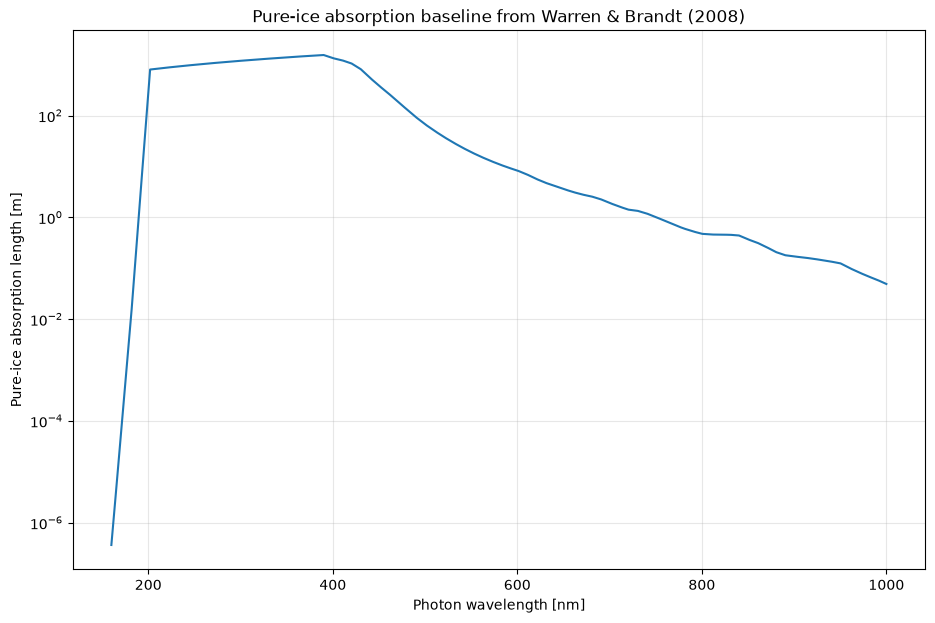

In [46]:
plt.figure(figsize=(11, 7))

plt.plot(
    wavelength_abs,
    L_abs
)

plt.yscale("log")

plt.xlabel(
    "Photon wavelength [nm]"
)

plt.ylabel(
    "Pure-ice absorption length [m]"
)

plt.title(
    "Pure-ice absorption baseline from Warren & Brandt (2008)"
)

plt.grid(
    alpha=0.3,
    which="both"
)

plt.show()

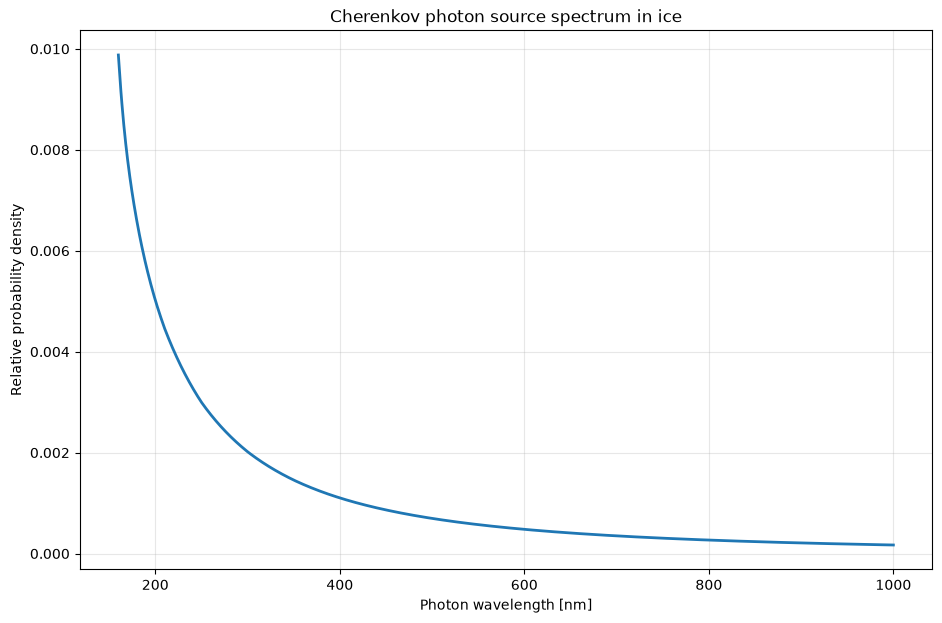

In [47]:
plt.figure(figsize=(11, 7))

plt.plot(
    wavelength_plot,
    source_pdf,
    linewidth=2
)

plt.xlabel(
    "Photon wavelength [nm]"
)

plt.ylabel(
    "Relative probability density"
)

plt.title(
    "Cherenkov photon source spectrum in ice"
)

plt.grid(alpha=0.3)

plt.show()

### 3.2 Dust and absorption comparisons

Here the WB-plus-dust hybrid, Ackermann's original total fit, and PPC's scalar
formula are distinct absorption assumptions. Dashed segments outside the
measured range are continuations. The UV shading spans chosen dust laws with
WB intrinsic ice held fixed, not an uncertainty interval. In the arriving
spectrum plot, every curve uses the same emitted-source normalization.


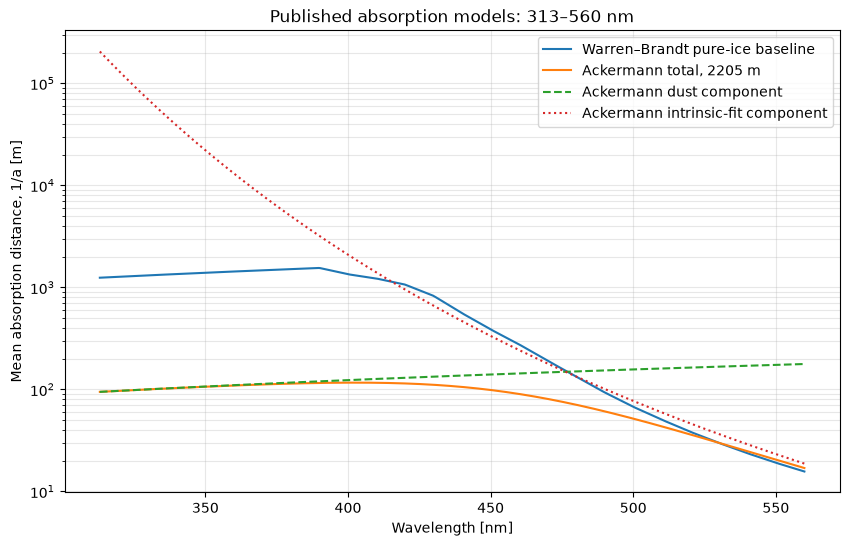

In [48]:
plt.figure(figsize=(10, 6))
plt.semilogy(wl_comparison, 1 / wb_pure,
             label="Warren–Brandt pure-ice baseline")
plt.semilogy(wl_comparison, 1 / ack_total,
             label=f"Ackermann total, {ACK_DEPTH_M} m")
plt.semilogy(wl_comparison, 1 / ack_dust, "--",
             label="Ackermann dust component")
plt.semilogy(wl_comparison, 1 / ack_intrinsic, ":",
             label="Ackermann intrinsic-fit component")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Mean absorption distance, 1/a [m]")
plt.title("Published absorption models: 313–560 nm")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.show()


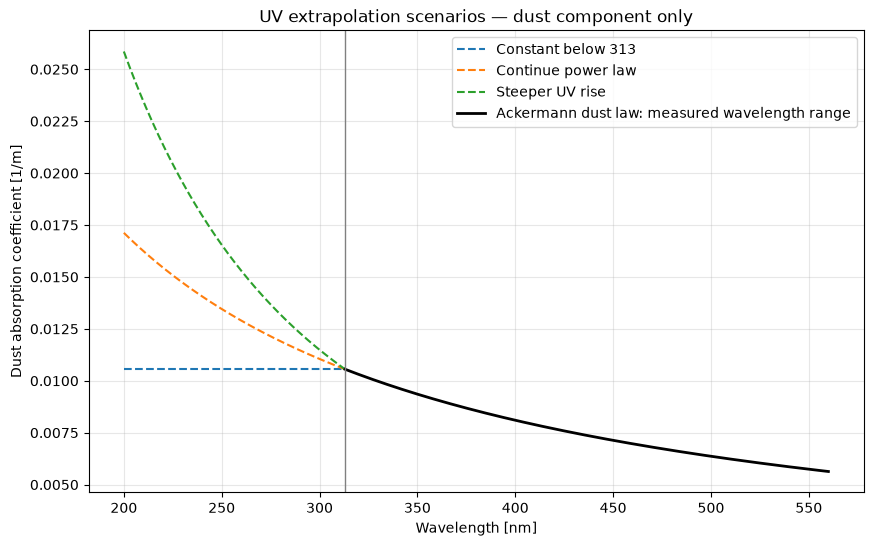

In [49]:
plt.figure(figsize=(10, 6))

for label, exponent in UV_SCENARIOS.items():
    plt.plot(
        wl_uv, dust_uv_scenario(wl_uv, exponent),
        "--", label=label
    )

plt.plot(
    wl_measured, dust_uv_scenario(wl_measured, 1.08),
    color="black", linewidth=2,
    label="Ackermann dust law: measured wavelength range"
)
plt.axvline(313, color="grey", linewidth=1)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Dust absorption coefficient [1/m]")
plt.title("UV extrapolation scenarios — dust component only")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

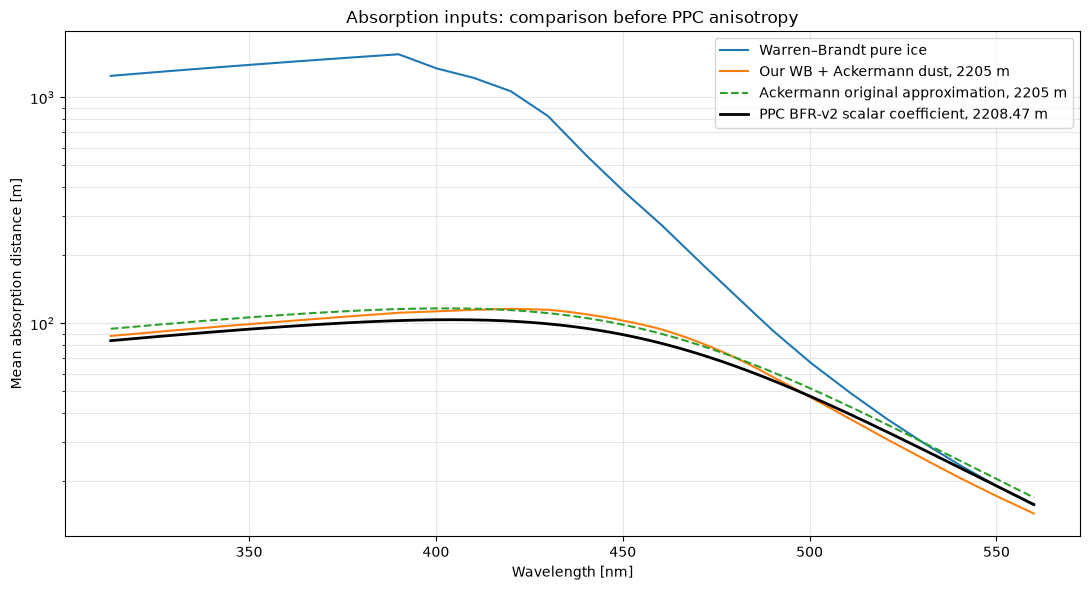

In [50]:
plt.figure(figsize=(11, 6))
plt.semilogy(
    wl_compare, 1 / a_wb_compare,
    label="Warren–Brandt pure ice"
)
plt.semilogy(
    wl_compare, 1 / a_combined_compare,
    label=f"Our WB + Ackermann dust, {ACK_DEPTH_M:g} m"
)
plt.semilogy(
    wl_compare, 1 / a_ack_compare, "--",
    label=f"Ackermann original approximation, {ACK_DEPTH_M:g} m"
)
plt.semilogy(
    wl_compare, 1 / a_ppc_compare, color="black", linewidth=2,
    label=f"PPC BFR-v2 scalar coefficient, {PPC_DEPTH_M:.2f} m"
)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Mean absorption distance [m]")
plt.title("Absorption inputs: comparison before PPC anisotropy")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()


**500–560 nm close-up.** This uses the same four absorption inputs and colors as the full-range comparison above. The linear vertical axis and distinct line styles expose small differences between the curves.


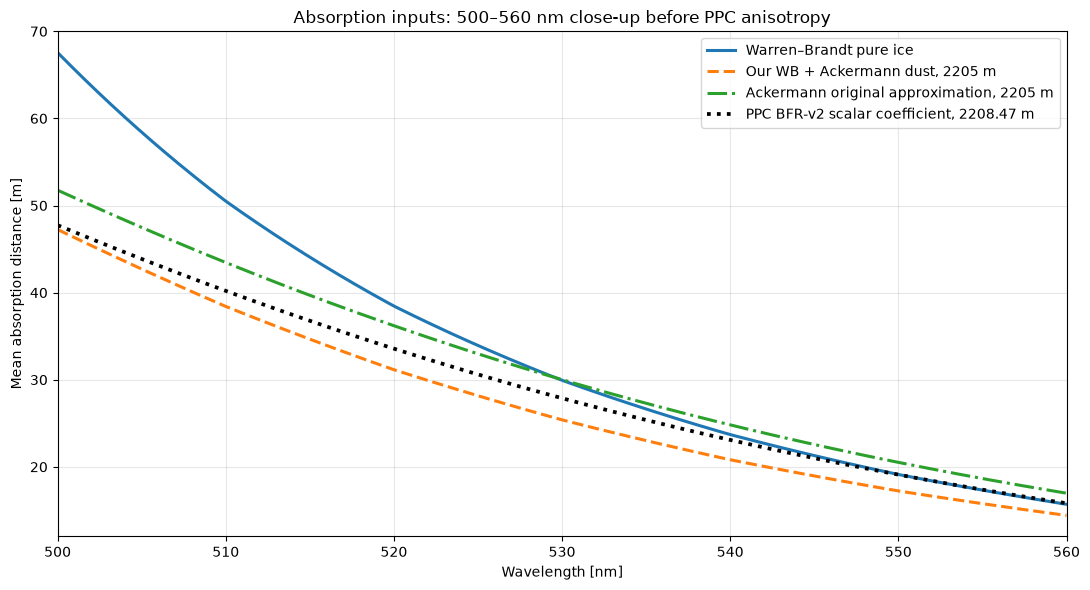

In [51]:
# Plotting only: exact 500-560 nm inputs are calculated in Section 2.
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(wl_input_zoom, 1. / a_wb_input_zoom, color='tab:blue', lw=2.2,
        label='Warren–Brandt pure ice')
ax.plot(wl_input_zoom, 1. / a_combined_input_zoom, '--', color='tab:orange',
        lw=2.2, label=f'Our WB + Ackermann dust, {ACK_DEPTH_M:g} m')
ax.plot(wl_input_zoom, 1. / a_ack_input_zoom, '-.', color='tab:green',
        lw=2.2, label=f'Ackermann original approximation, {ACK_DEPTH_M:g} m')
ax.plot(wl_input_zoom, 1. / a_ppc_input_zoom, ':', color='black', lw=2.7,
        label=f'PPC BFR-v2 scalar coefficient, {PPC_DEPTH_M:.2f} m')
ax.set(xlim=(500., 560.), ylim=(12., 70.), xlabel='Wavelength [nm]',
       ylabel='Mean absorption distance [m]',
       title='Absorption inputs: 500–560 nm close-up before PPC anisotropy')
ax.set_xticks(np.arange(500., 561., 10.))
ax.grid(alpha=.3)
ax.legend()
fig.tight_layout()
fig.savefig(figure_folder / 'absorption_inputs_zoom_500_560nm.png',
            dpi=160, bbox_inches='tight')
plt.show()


**500–700 nm continuation.** Warren–Brandt uses its tabulated optical constants throughout. The orange WB-plus-dust curve and the black PPC scalar curve continue their formulas beyond 560 nm; that part is outside the Ackermann comparison interval. The green Ackermann original curve ends at 560 nm. The vertical axis is logarithmic to show the shorter lengths at longer wavelengths.


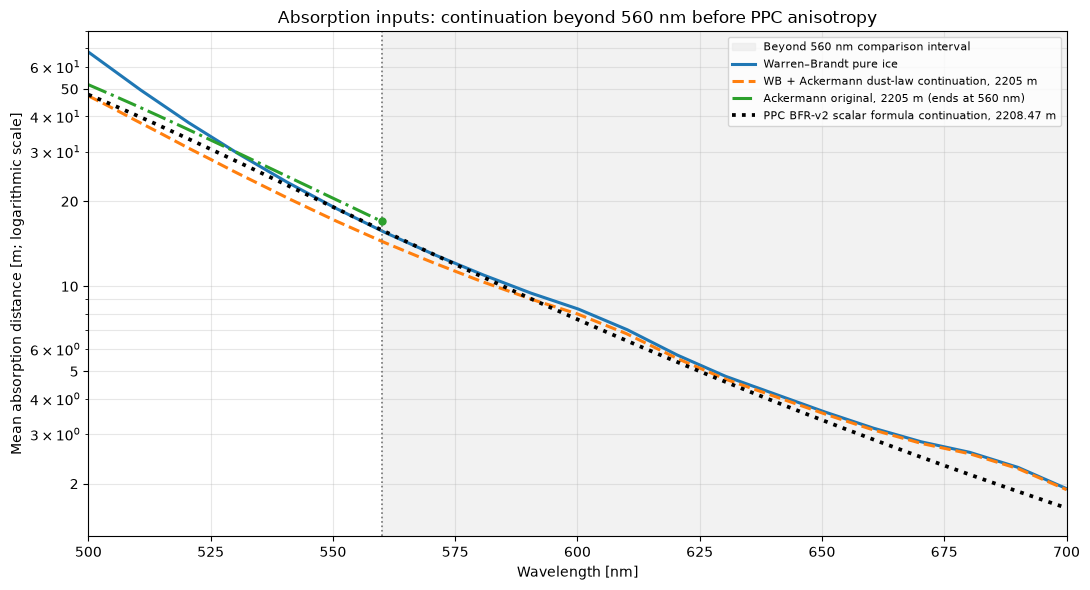

In [52]:
# Plotting only: the extended inputs are prepared in Section 2.
fig, ax = plt.subplots(figsize=(11, 6))
ax.axvspan(560., EXTENDED_INPUT_RANGE_NM[1], color='0.92', alpha=.65,
           label='Beyond 560 nm comparison interval')
ax.plot(wl_extended_compare, 1. / a_wb_extended, color='tab:blue', lw=2.2,
        label='Warren–Brandt pure ice')
ax.plot(wl_extended_compare, 1. / a_hybrid_extended, '--',
        color='tab:orange', lw=2.2,
        label=f'WB + Ackermann dust-law continuation, {ACK_DEPTH_M:g} m')
ax.plot(wl_extended_compare[ackermann_extended_mask],
        1. / a_ackermann_through_560, '-.', color='tab:green', lw=2.2,
        label=f'Ackermann original, {ACK_DEPTH_M:g} m (ends at 560 nm)')
ax.plot(wl_extended_compare, 1. / a_ppc_extended, ':',
        color='black', lw=2.7,
        label=f'PPC BFR-v2 scalar formula continuation, {PPC_DEPTH_M:.2f} m')
ax.plot(560., 1. / a_ackermann_through_560[-1], 'o',
        color='tab:green', ms=5, zorder=5)
ax.axvline(560., color='0.45', ls=':', lw=1.2)
ax.set_yscale('log')
ax.set_ylim(1.3, 80.)
ax.set_yticks([2., 5., 10., 20., 50.])
ax.set_yticklabels(['2', '5', '10', '20', '50'])
ax.set_xlim(*EXTENDED_INPUT_RANGE_NM)
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Mean absorption distance [m; logarithmic scale]')
ax.set_title('Absorption inputs: continuation beyond 560 nm before PPC anisotropy')
ax.grid(alpha=.3, which='both')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(figure_folder / f'absorption_inputs_continued_{EXTENDED_INPUT_RANGE_NM[0]:g}_{EXTENDED_INPUT_RANGE_NM[1]:g}nm.png',
            dpi=160, bbox_inches='tight')
plt.show()


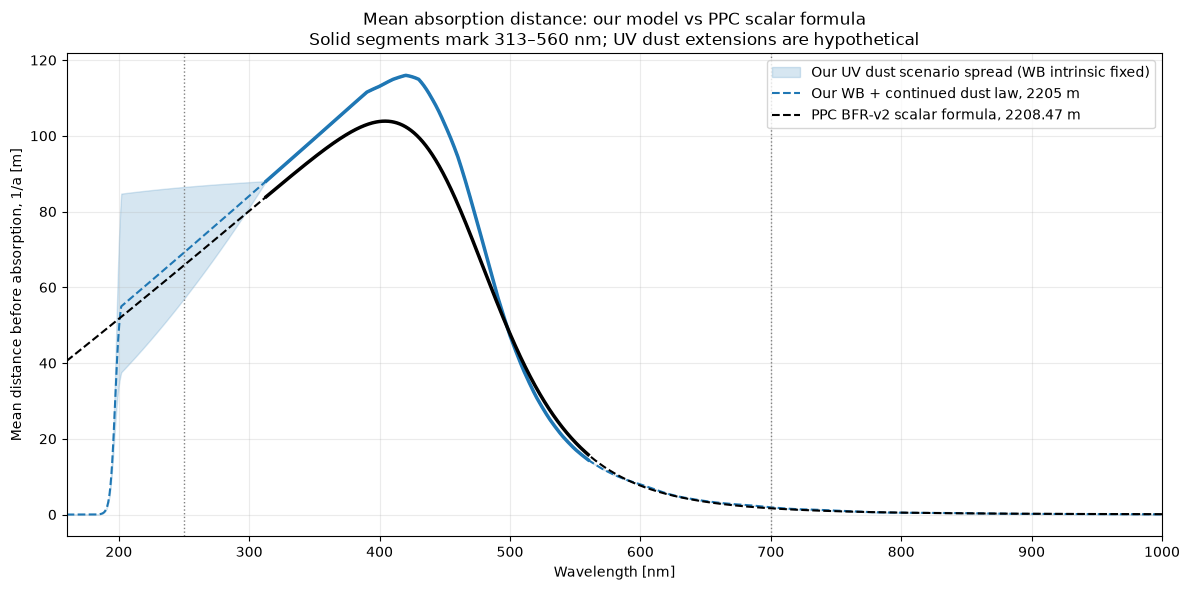

In [53]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(
    wl_full,
    scenario_lengths.min(axis=0),
    scenario_lengths.max(axis=0),
    color="tab:blue", alpha=0.18,
    label="Our UV dust scenario spread (WB intrinsic fixed)"
)

# Dashed curves show the full formula evaluations.
ax.plot(
    wl_full, our_mean_distance, "--", color="tab:blue",
    label=f"Our WB + continued dust law, {ACK_DEPTH_M:g} m"
)
ax.plot(
    wl_full, ppc_mean_distance, "--", color="black",
    label=f"PPC BFR-v2 scalar formula, {PPC_DEPTH_M:.2f} m"
)

# Solid portions identify the earlier measurement interval.
measured_interval = (wl_full >= 313) & (wl_full <= 560)
ax.plot(
    wl_full[measured_interval],
    our_mean_distance[measured_interval],
    color="tab:blue", linewidth=2.5
)
ax.plot(
    wl_full[measured_interval],
    ppc_mean_distance[measured_interval],
    color="black", linewidth=2.5
)

ax.axvline(250, color="grey", linestyle=":", linewidth=1)
ax.axvline(700, color="grey", linestyle=":", linewidth=1)

#ax.set_yscale("log")
ax.set_xlim(160, 1000)
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Mean distance before absorption, 1/a [m]")
ax.set_title(
    "Mean absorption distance: our model vs PPC scalar formula\n"
    "Solid segments mark 313–560 nm; UV dust extensions are hypothetical"
)
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.tight_layout()
plt.show()

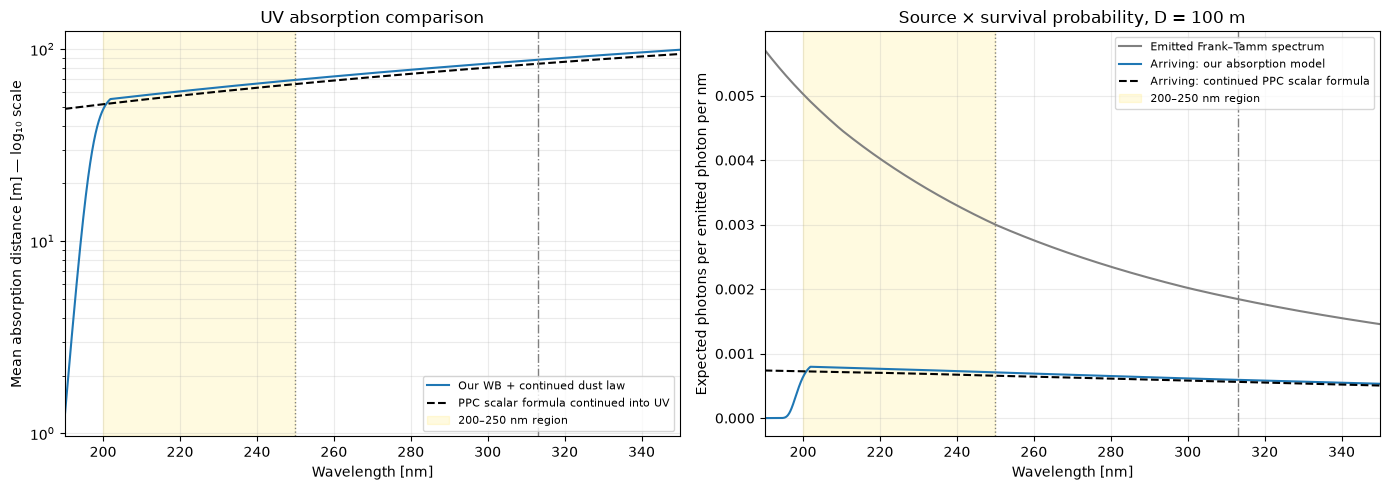

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean absorption distance.
axes[0].semilogy(
    wl_zoom, 1 / a_ours_zoom, color="tab:blue",
    label="Our WB + continued dust law"
)
axes[0].semilogy(
    wl_zoom, 1 / a_ppc_zoom, "--", color="black",
    label="PPC scalar formula continued into UV"
)
axes[0].set_ylabel("Mean absorption distance [m] — log₁₀ scale")
axes[0].set_title("UV absorption comparison")

# Emitted and arriving spectra, all with the same normalization.
axes[1].plot(
    wl_zoom, emitted_zoom, color="grey",
    label="Emitted Frank–Tamm spectrum"
)
axes[1].plot(
    wl_zoom, arriving_ours, color="tab:blue",
    label="Arriving: our absorption model"
)
axes[1].plot(
    wl_zoom, arriving_ppc, "--", color="black",
    label="Arriving: continued PPC scalar formula"
)
axes[1].set_ylabel("Expected photons per emitted photon per nm")
axes[1].set_title(f"Source × survival probability, D = {D_ZOOM:g} m")

for ax in axes:
    ax.axvspan(200, 250, color="gold", alpha=0.12,
               label="200–250 nm region")
    ax.axvline(250, color="grey", linestyle=":", linewidth=1)
    ax.axvline(313, color="grey", linestyle="-.", linewidth=1)
    ax.set_xlim(190, 350)
    ax.set_xlabel("Wavelength [nm]")
    ax.grid(alpha=0.25, which="both")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.3 Independent depth profiles: Warren–Brandt ice + published dust

This section uses our independent absorption model:
$a(\lambda,z)=a_{\mathrm{WB}}(\lambda)+a_{\mathrm{dust},400}(z)(\lambda/400)^{-1.08}$,
with $L=1/a$. No SPICE files or fitted SPICE parameters enter these calculations.
The dust profile comes from [Ackermann et al. (2006), Table 3](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2005JD006687),
the same source as the selected fixed-depth dust normalization. It uses AMANDA
measurements and an empirical scattering–dust correlation.

Blue/black/red curves show lower/nominal/upper values using the table's reported
errors. Length bounds invert the absorption bounds. These are **partial error
bounds**, holding Warren–Brandt absorption and spectral exponents fixed, not a
complete confidence interval. Rows without reported errors have open markers
and gaps in the bounds; no errors are invented. The third panel shows the
published effective-scattering profile scaled as $(\lambda/400)^{-0.9}$.

Warren–Brandt pure ice is held at its tabulated temperature (−7 °C) at every
depth: this independent model has no depth-temperature correction.
The default range avoids the deeper extrapolated region. Violin caps show the
minimum/maximum **nominal layer properties**, not photon travel distances or
uncertainty limits. Each 10 m layer contributes one value, including estimated
rows. These plots do not depend on the number of simulated photons.

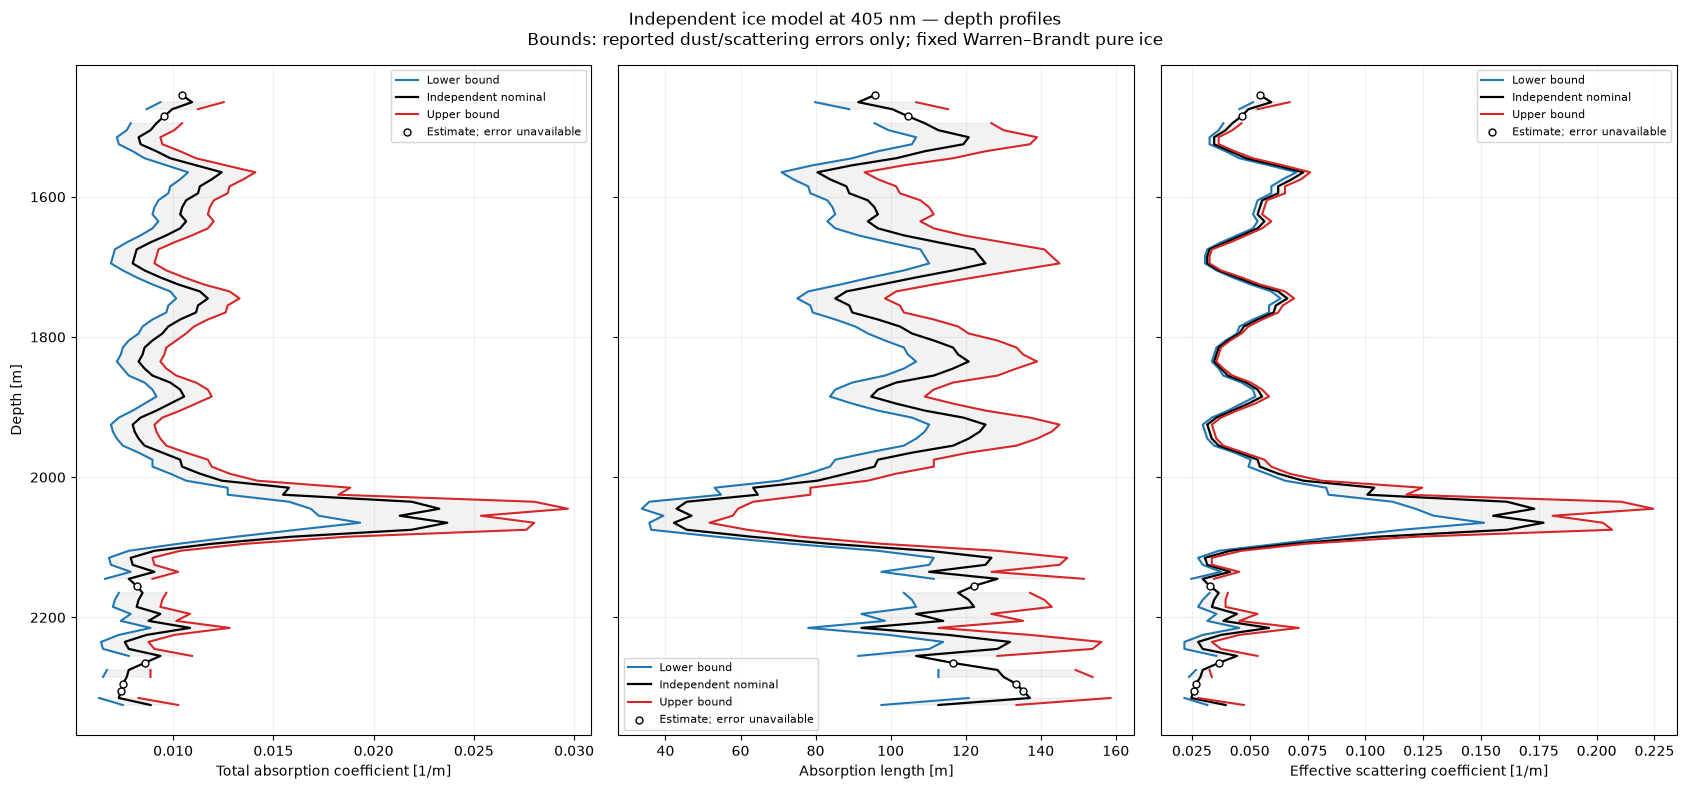

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(17, 8), sharey=True)
labels = ['Total absorption coefficient [1/m]', 'Absorption length [m]',
          'Effective scattering coefficient [1/m]']
for ax, key, label in zip(axes, ('a', 'L', 'be'), labels):
    nominal, lower, upper = [v[:, 0] for v in depth_properties[key]]
    ax.fill_betweenx(depth_m, lower, upper, color='0.7', alpha=0.16)
    ax.plot(lower, depth_m, color='tab:blue', lw=1.5, label='Lower bound')
    ax.plot(nominal, depth_m, color='black', lw=1.6, label='Independent nominal')
    ax.plot(upper, depth_m, color='tab:red', lw=1.5, label='Upper bound')
    missing = ~np.isfinite(lower)
    if missing.any():
        ax.scatter(nominal[missing], depth_m[missing], facecolors='white',
                   edgecolors='black', s=25, zorder=4, label='Estimate; error unavailable')
    ax.set_xlabel(label)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc='best')
axes[0].set_ylabel('Depth [m]')
axes[0].invert_yaxis()
fig.suptitle(f'Independent ice model at {DEPTH_REFERENCE_NM:g} nm — depth profiles\n'
             'Bounds: reported dust/scattering errors only; fixed Warren–Brandt pure ice')
fig.tight_layout()
fig.savefig(depth_output_dir / 'independent_depth_profiles.png', dpi=160, bbox_inches='tight')
plt.show()

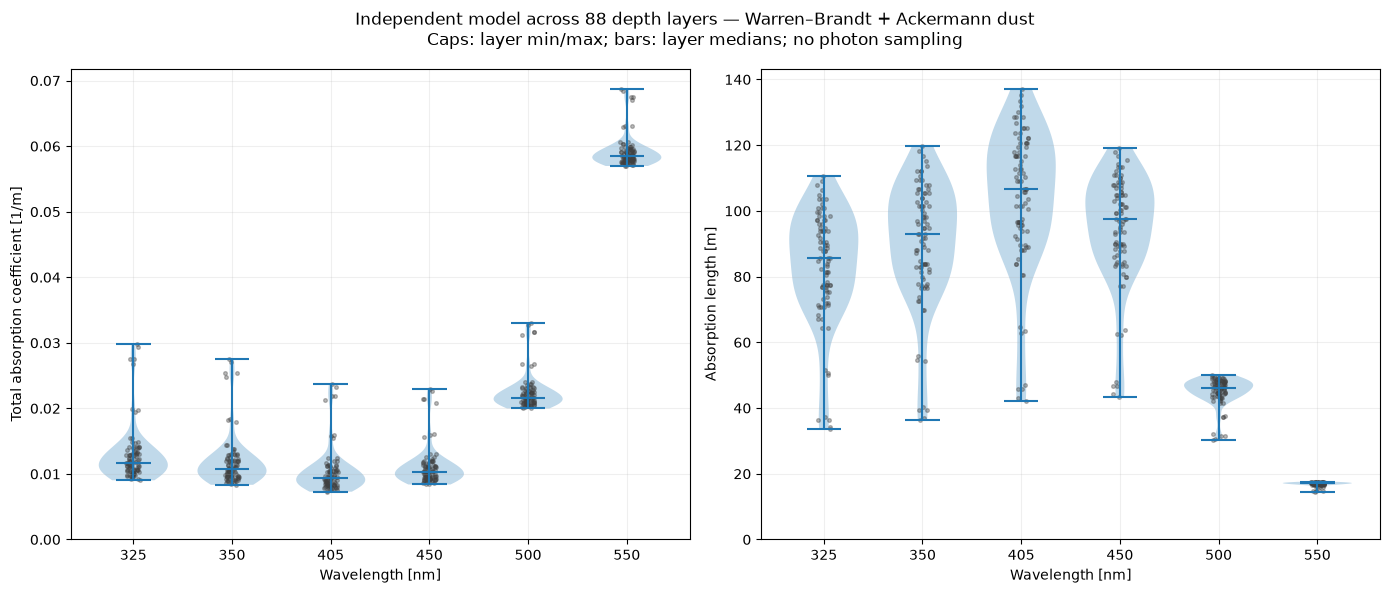

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, key, label in zip(axes, ('a', 'L'),
                         ('Total absorption coefficient [1/m]', 'Absorption length [m]')):
    values = depth_violin[key][0]
    parts = ax.violinplot(list(values.T), positions=depth_positions,
                          showmedians=True, showextrema=True, widths=0.7)
    for body in parts['bodies']:
        body.set_facecolor('tab:blue')
        body.set_alpha(0.28)
    for name in ('cmins', 'cmaxes', 'cbars', 'cmedians'):
        parts[name].set_color('tab:blue')
    for j, column in enumerate(values.T):
        ax.scatter(j + depth_violin_jitter[(key, j)], column,
                   s=7, alpha=0.35, color='0.25')
    ax.set_xticks(depth_positions, [f'{w:g}' for w in DEPTH_VIOLIN_NM])
    ax.set_xlabel('Wavelength [nm]')
    ax.set_ylabel(label)
    ax.grid(alpha=0.2)
    ax.set_ylim(bottom=0)
fig.suptitle(f'Independent model across {len(depth_table)} depth layers — Warren–Brandt + Ackermann dust\n'
             'Caps: layer min/max; bars: layer medians; no photon sampling')
fig.tight_layout()
fig.savefig(depth_output_dir / 'independent_layer_violins.png', dpi=160, bbox_inches='tight')
plt.show()

### 3.4 Same independent absorption law with three dust profiles

We can use the two SPICE depth tables as **dust inputs** while evaluating all
three curves with exactly the same independent formula:

$a(\lambda,z)=a_{\mathrm{WB}}(\lambda)
+a_{\mathrm{dust},400}(z)(\lambda/400)^{-1.08}$,
and $L=1/a$.

Blue and orange use the 400 nm dust columns from `spice_ftp-v3m` and
`spice_bfr-v2`. Black uses Ackermann's published 400 nm dust profile. All
three use Warren–Brandt pure ice and the Ackermann wavelength exponent.
The SPICE absorption formula, SPICE temperature term and PPC executable are
not used in this figure. The SPICE *dust values* remain outputs of IceCube
calibration involving PPC, so the blue and orange curves are not fully
independent of PPC. This is a hybrid comparison, not the complete SPICE model.

Each profile stays on its own published/tabulated depth grid. No uncertainty
bounds or photons are sampled. Warren–Brandt pure ice is held at its tabulated
temperature (−7 °C) at every depth.

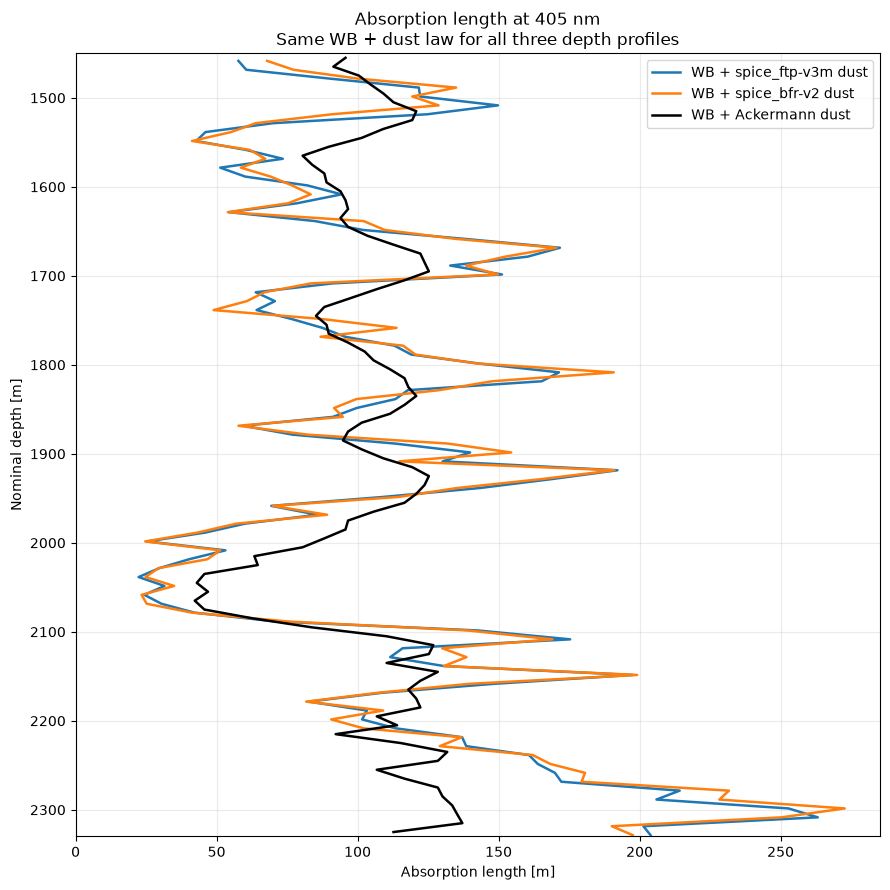

In [57]:
# Three depth curves; all lengths were computed in Section 2.5.
fig, ax = plt.subplots(figsize=(9, 9))
for (source, (depths, lengths)), color in zip(
    comparison_plot_data.items(), ('tab:blue', 'tab:orange', 'black')
):
    ax.plot(lengths, depths, lw=1.8, color=color, label=f'WB + {source} dust')

ax.set(
    xlabel='Absorption length [m]',
    ylabel='Nominal depth [m]',
    title=f'Absorption length at {COMPARISON_WAVELENGTH_NM:g} nm\n'
          'Same WB + dust law for all three depth profiles',
    ylim=(COMPARISON_DEPTH_RANGE_M[1], COMPARISON_DEPTH_RANGE_M[0]),
)
ax.set_xlim(left=0)
ax.grid(alpha=.25)
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(comparison_output / 'absorption_length_vs_depth.png',
            dpi=160, bbox_inches='tight')
plt.show()


### 3.5 Analytic dust/ice crossover

For one fixed wavelength, the cause-specific **joint PDFs** are
$f_{\rm dust}(d)=a_{\rm dust}e^{-(a_{\rm dust}+a_{\rm ice})d}$ and
$f_{\rm ice}(d)=a_{\rm ice}e^{-(a_{\rm dust}+a_{\rm ice})d}$.
Their ratio is $a_{\rm dust}/a_{\rm ice}$ at **every distance**; the
curves therefore change order as wavelength changes, not as distance
changes. The crossover is where $a_{\rm dust}=a_{\rm ice}$, or 50% of
absorptions are caused by dust. Each model uses its own intrinsic-ice term.
The scan is restricted to the measured 313–560 nm comparison interval.
These are model crossovers at the selected depth, not uncertainty bounds.


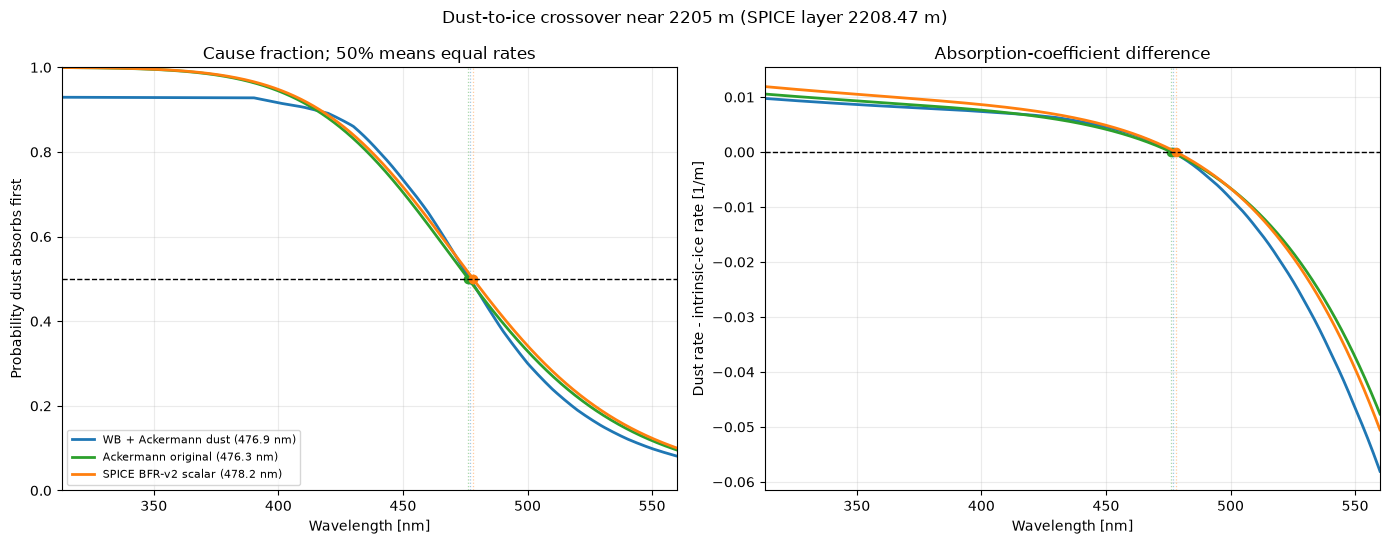

In [58]:
# Locate the model-specific wavelength where dust and ice win equally often.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
for model in crossover_models:
    data = crossover_rates[model]
    color = PDF_COLORS[model]
    roots = crossover_roots[model]
    label = model + (f' ({roots[0]:.1f} nm)' if len(roots) == 1 else '')
    axes[0].plot(crossover_wl, data['dust_fraction'], color=color,
                 lw=2., label=label)
    axes[1].plot(crossover_wl, data['difference'], color=color, lw=2.)
    for root in roots:
        axes[0].plot(root, .5, 'o', color=color, ms=6)
        axes[1].plot(root, 0., 'o', color=color, ms=6)
        for ax in axes:
            ax.axvline(root, color=color, lw=.9, alpha=.4, ls=':')
axes[0].axhline(.5, color='black', lw=1., ls='--')
axes[1].axhline(0., color='black', lw=1., ls='--')
axes[0].set(ylabel='Probability dust absorbs first', ylim=(0., 1.),
            title='Cause fraction; 50% means equal rates')
axes[1].set(ylabel='Dust rate - intrinsic-ice rate [1/m]',
            title='Absorption-coefficient difference')
for ax in axes:
    ax.set(xlim=PDF_CROSSOVER_RANGE_NM, xlabel='Wavelength [nm]')
    ax.grid(alpha=.25)
axes[0].legend(fontsize=8)
fig.suptitle(f'Dust-to-ice crossover near {ACK_DEPTH_M:g} m '
             f'(SPICE layer {PPC_DEPTH_M:.2f} m)')
fig.tight_layout()
fig.savefig(per_wl_output / 'dust_ice_crossover_by_wavelength.png',
            dpi=160, bbox_inches='tight')
plt.show()


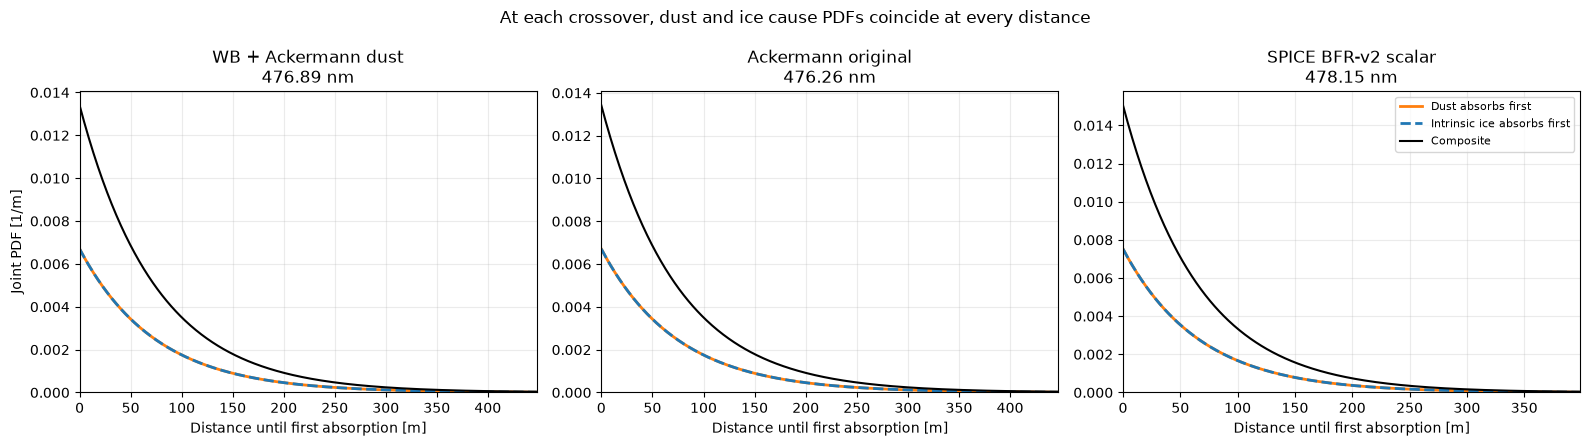

In [59]:
# At each model's crossover wavelength, show the two equal cause PDFs.
fig, axes = plt.subplots(1, len(crossover_models), figsize=(16, 4.5))
for ax, model in zip(axes, crossover_models):
    roots = crossover_roots[model]
    if len(roots) != 1:
        ax.text(.5, .5, f'{len(roots)} crossings in scan; see table',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue
    wavelength_nm = roots[0]
    profile = crossover_pdf_profiles[model]
    distance = profile['distance_m']
    dust_pdf = profile['dust_pdf']
    ice_pdf = profile['ice_pdf']
    ax.plot(distance, dust_pdf, color='tab:orange', lw=2., label='Dust absorbs first')
    ax.plot(distance, ice_pdf, '--', color='tab:blue', lw=2.,
            label='Intrinsic ice absorbs first')
    ax.plot(distance, dust_pdf + ice_pdf, color='black', lw=1.5,
            label='Composite')
    ax.set(xlim=(0., profile['max_distance_m']), ylim=(0., None),
           title=f'{model}\n{wavelength_nm:.2f} nm',
           xlabel='Distance until first absorption [m]')
    ax.grid(alpha=.25)
axes[0].set_ylabel('Joint PDF [1/m]')
axes[-1].legend(fontsize=8)
fig.suptitle('At each crossover, dust and ice cause PDFs coincide at every distance')
fig.tight_layout()
fig.savefig(per_wl_output / 'dust_ice_pdfs_at_crossover.png',
            dpi=160, bbox_inches='tight')
plt.show()


**Why the original curves cross near 550 nm:** At a fixed wavelength,
the mean distance of this competing-rate model is
$L=1/(a_{\rm ice}+a_{\rm dust})$. For the same Warren–Brandt intrinsic
ice, adding Ackermann dust raises the total absorption coefficient and
must shorten the distance. At 550 nm, its mean falls from **19.12 m**
(pure ice) to **17.23 m** (ice plus dust).

The **Ackermann original** model changes the intrinsic-ice formula as
well: at 550 nm its intrinsic coefficient is 0.04301 m$^{-1}$, versus
0.05230 m$^{-1}$ for Warren–Brandt. Adding Ackermann's dust coefficient
of 0.00574 m$^{-1}$ gives 0.04875 m$^{-1}$ total, or **20.51 m**.
That is why this dusty model slightly exceeds Warren–Brandt pure ice
there. It is a difference between ice parameterizations, not a physical
benefit from dust or a Monte Carlo artifact. SPICE BFR-v2 is close to
Warren–Brandt pure ice there (19.10 versus 19.12 m).

The Monte Carlo pooled PDF in Section 4.4 averages over the Cherenkov wavelength range and shows
that pure ice has a much longer overall tail. A crossing of *PDF
heights* is expected even for a consistently longer-lived distribution:
each PDF integrates to one, so the longer-lived distribution has less
density near zero and more density in its tail. Compare means or survival
probabilities to judge which model permits longer travel. The pooled PDF
cannot by itself explain a crossover at one wavelength; compare the
550 nm individual-wavelength PDF in Section 4.6 with the absorption
coefficients above.

The PPC/WB crossing near 551 nm is much smaller than the published spread of
the WB snow-transmission estimate at 550–560 nm. It should be read as a
crossing of parameterizations, not evidence that dusty ice physically
outperforms dust-free ice. The WB baseline is nominally at 266 K, whereas
the PPC scalar fit applies its own layer-temperature factor.


## 4. Monte Carlo

Every figure in this section contains sampled photon wavelengths or absorption distances. Some include analytic curves for reference; the captions distinguish sampled results from exact model predictions. Model-parameter uncertainty is separate from Monte Carlo sampling uncertainty.


### 4.1 Cherenkov wavelengths and pure-ice travel samples

The histogram tests random wavelength sampling against the Frank–Tamm spectrum. The emitted and arriving wavelength spectra share a denominator of **all emitted photons**, so their difference represents losses. Wavelength-band percentages in Section 2 instead describe the composition of arriving photons; use the survival column there for the fraction of emitted photons that arrive. The scatter plot shows individual simulated absorption distances beside the analytic mean $1/a(\lambda)$.


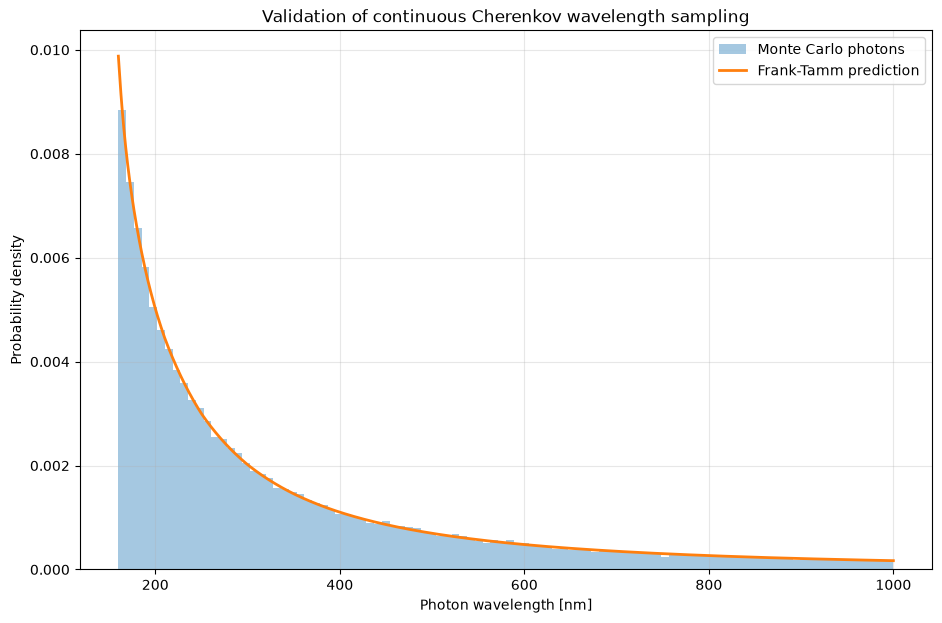

In [60]:
plt.figure(figsize=(11, 7))


# Monte Carlo wavelengths
plt.hist(
    photon_wavelengths,
    bins=100,
    density=True,
    alpha=0.4,
    label="Monte Carlo photons"
)


# Theoretical Frank-Tamm distribution
plt.plot(
    wavelength_plot,
    source_pdf,
    linewidth=2,
    label="Frank-Tamm prediction"
)


plt.xlabel(
    "Photon wavelength [nm]"
)

plt.ylabel(
    "Probability density"
)

plt.title(
    "Validation of continuous Cherenkov wavelength sampling"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

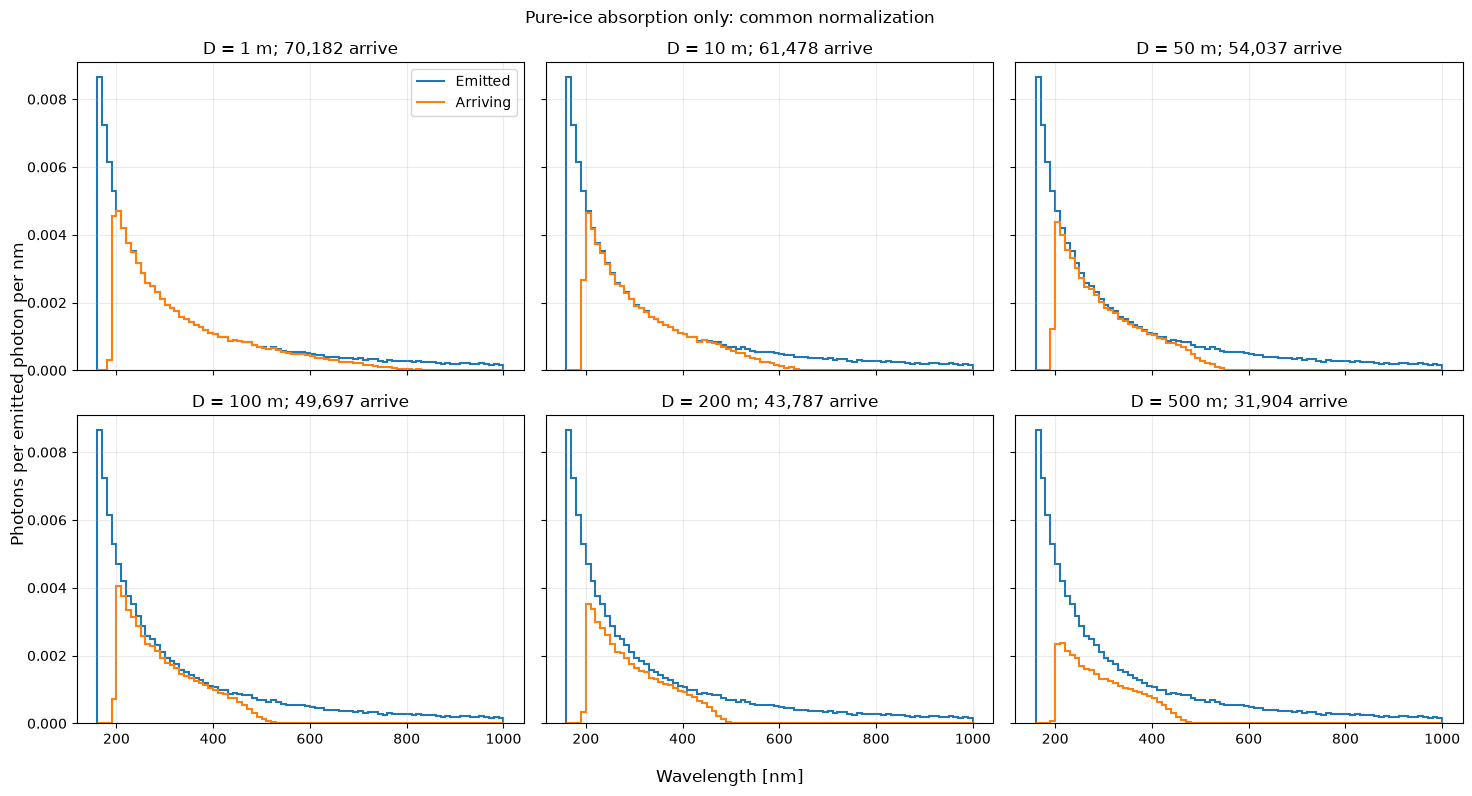

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for ax, D in zip(axes.flat, distances_m):
    arriving_density = arriving_density_by_distance[D]

    ax.stairs(emitted_density, edges_nm, label="Emitted", linewidth=1.5)
    ax.stairs(arriving_density, edges_nm, label="Arriving", linewidth=1.5)
    ax.set_title(f"D = {D:g} m; {arrives[D].sum():,} arrive")
    ax.grid(alpha=0.25)

axes[0, 0].legend()
fig.supxlabel("Wavelength [nm]")
fig.supylabel("Photons per emitted photon per nm")
fig.suptitle("Pure-ice absorption only: common normalization")
plt.tight_layout()
plt.show()

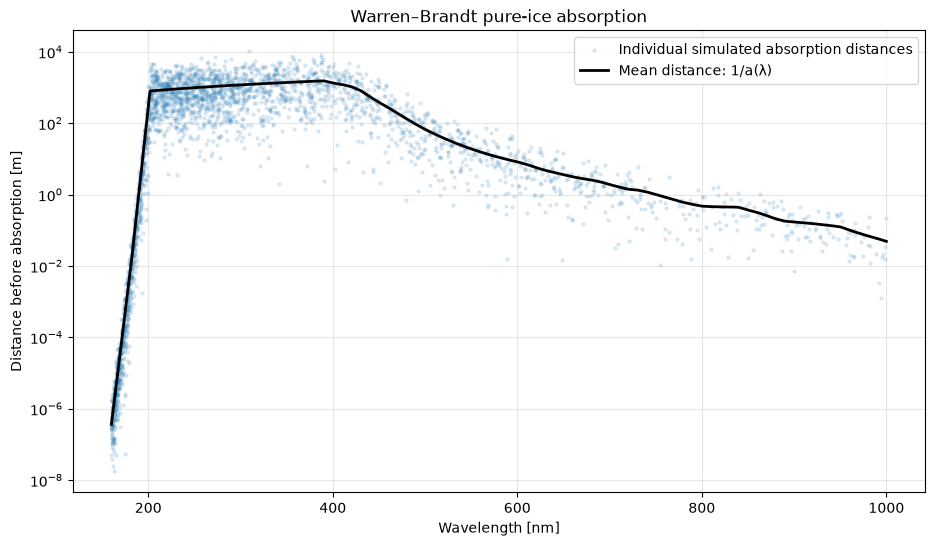

In [62]:
plt.figure(figsize=(11, 6))
plt.scatter(
    photon_wavelengths[shown],
    d_abs_m[shown],
    s=5, alpha=0.12,
    label="Individual simulated absorption distances"
)
plt.plot(
    wavelength_grid,
    mean_absorption_distance,
    color="black", linewidth=2,
    label="Mean distance: 1/a(λ)"
)
plt.yscale("log")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Distance before absorption [m]")
plt.title("Warren–Brandt pure-ice absorption")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

### 4.2 Monte Carlo means at tabulated wavelengths

Dots are **sample means of first-absorption distances** for all four models. The 21 wavelength positions from 500 to 700 nm come from the Warren–Brandt table; each model's absorption rates are evaluated at those positions and photons are sampled from them. Ackermann original stops at 560 nm. Error bars are approximate 95% confidence intervals for the sampled mean with `N_INPUT_POINT_MC_PHOTONS` photons per model and wavelength. They do **not** include uncertainty in the Warren–Brandt, Ackermann, or PPC optical parameters. Markers are offset horizontally by at most 1.8 nm for visibility; calculations use the exact table wavelengths.

At the default 2,000 photons, the expected 95% relative half-width is about 4.4%. This is useful for showing sampling variation, but not for resolving model differences near 1%. For example, at 700 nm the analytic WB pure-ice and WB + Ackermann continuation means differ by only about 0.8%, so the sampled dots can appear in the opposite order. About 40,000 photons per point gives roughly 1% sampling half-width; roughly 250,000 per point is needed to reliably distinguish a 0.8% difference between independent samples. The analytic curves in Section 3 remain the exact comparison for fixed model inputs.


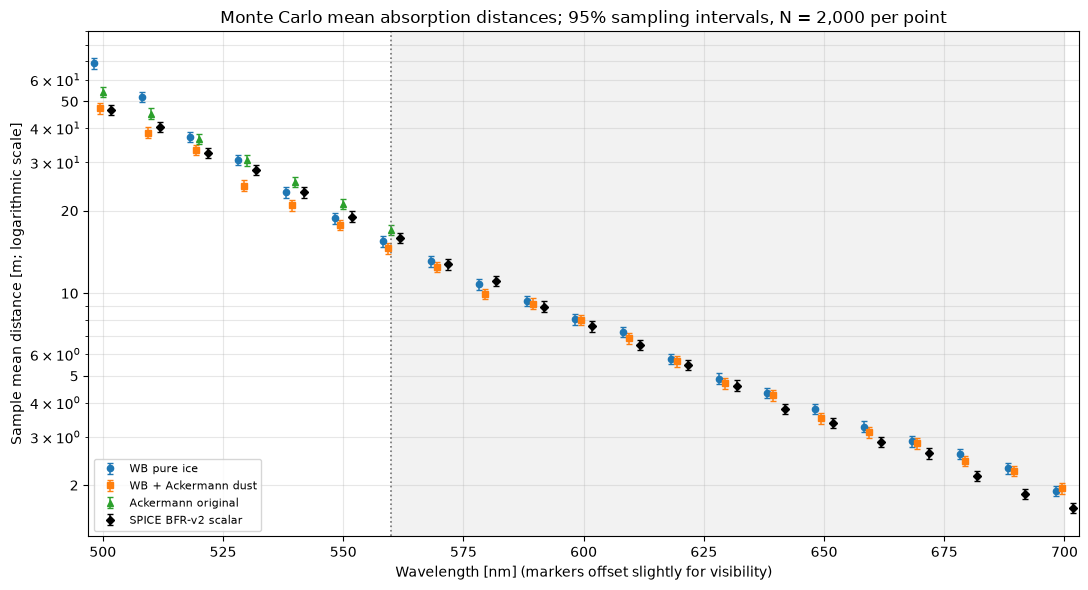

In [63]:
# Plotting only: discrete Monte Carlo means and CIs are prepared in Section 2.7.
fig, ax = plt.subplots(figsize=(11, 6))
ax.axvspan(560., EXTENDED_INPUT_RANGE_NM[1], color='0.92', alpha=.65)
point_styles = (
    ('WB pure ice', 'tab:blue', 'o', -1.8),
    ('WB + Ackermann dust', 'tab:orange', 's', -0.6),
    ('Ackermann original', 'tab:green', '^', 0.),
    ('SPICE BFR-v2 scalar', 'black', 'D', 1.8),
)
for model, color, marker, x_offset in point_styles:
    rows = input_point_mc_summary.loc[input_point_mc_summary['model'] == model]
    mean = rows['mc_mean_m'].to_numpy()
    yerr = np.vstack((
        mean - rows['mc_mean_ci95_low_m'].to_numpy(),
        rows['mc_mean_ci95_high_m'].to_numpy() - mean,
    ))
    ax.errorbar(rows['wavelength_nm'].to_numpy() + x_offset, mean, yerr=yerr,
                fmt=marker, ls='none', color=color, ecolor=color,
                ms=4.5, elinewidth=1.1, capsize=2.2, label=model)
ax.axvline(560., color='0.45', ls=':', lw=1.2)
ax.set_yscale('log')
ax.set_xlim(EXTENDED_INPUT_RANGE_NM[0] - 3., EXTENDED_INPUT_RANGE_NM[1] + 3.)
ax.set_ylim(1.3, 90.)
ax.set_yticks([2., 5., 10., 20., 50.])
ax.set_yticklabels(['2', '5', '10', '20', '50'])
ax.set_xlabel('Wavelength [nm] (markers offset slightly for visibility)')
ax.set_ylabel('Sample mean distance [m; logarithmic scale]')
ax.set_title(f'Monte Carlo mean absorption distances; 95% sampling intervals, '
             f'N = {N_INPUT_POINT_MC_PHOTONS:,} per point')
ax.grid(alpha=.3, which='both')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(figure_folder / 'absorption_inputs_mc_points_500_700nm.png',
            dpi=160, bbox_inches='tight')
plt.show()


### 4.3 Photon-distance violins with lower and upper caps

Both the blue and orange violins now show a lower cap (sample minimum), an upper
cap (sample maximum), a connecting vertical line, and a black median bar, like
the original violin style. Both figures show the full sampled range.

Set `N_PER_WAVELENGTH` in the Variables section to change the photon count. The same
sampled optical depths are reused for both models. The caps depend on sample
size and random seed: they are **not confidence intervals or physical limits**.
An exponential absorption distribution has no finite maximum distance.
These violins contain photon distances, whereas the original SPICE figure
contained material properties across depth layers.


Each wavelength category samples exactly `N_PER_WAVELENGTH` photons. Violin
widths therefore do **not** represent Frank–Tamm emission counts. The red
line is the ideal sensor distance; the fraction surviving it is
$e^{-aD}$. The violin shape is smoothed, so use the printed survival values
for quantitative comparisons.


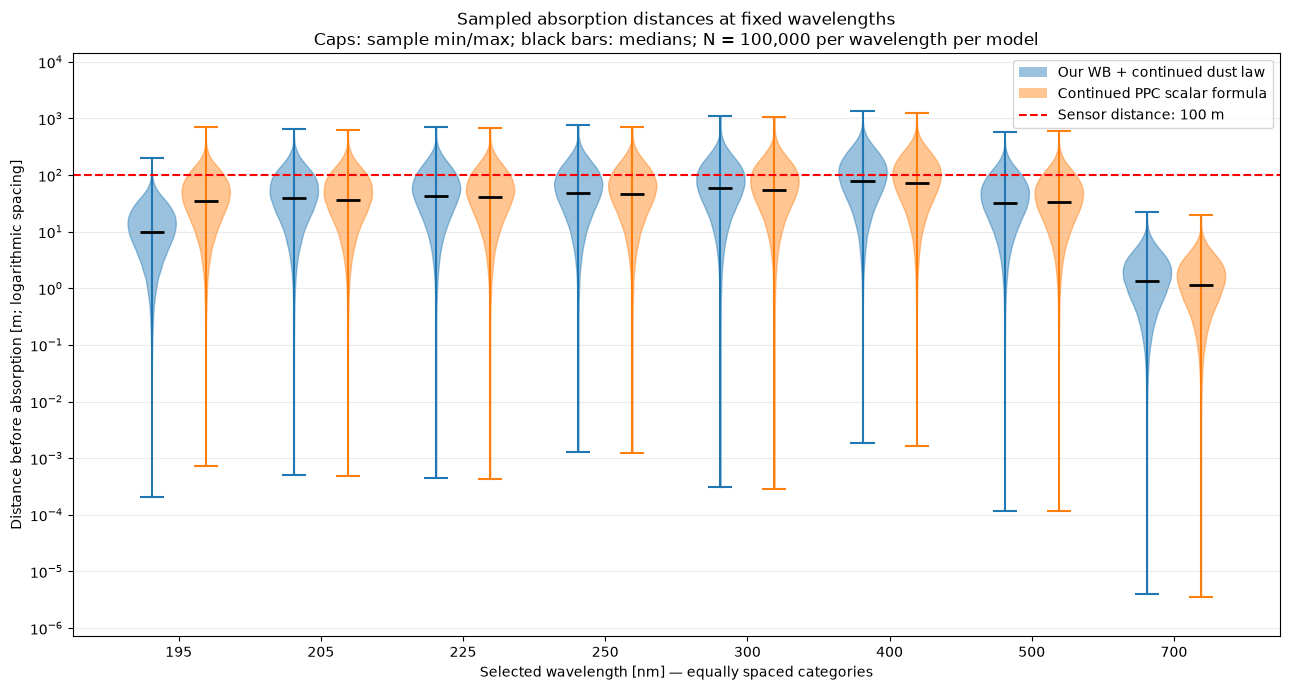

In [64]:
fig, ax = plt.subplots(figsize=(13, 7))

for samples, offset, color in [
    (log_ours, -0.19, "tab:blue"),
    (log_ppc,   0.19, "tab:orange"),
]:
    violin = ax.violinplot(
        samples,
        positions=positions + offset,
        widths=0.34,
        showmedians=True,
        showextrema=True
    )
    for body in violin["bodies"]:
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.45)

    # End caps show the exact minimum/maximum of this photon sample.
    for part in ("cmins", "cmaxes", "cbars"):
        violin[part].set_color(color)
        violin[part].set_linewidth(1.5)

    violin["cmedians"].set_color("black")
    violin["cmedians"].set_linewidth(2)

ax.axhline(
    np.log10(D_SENSOR), color="red", linestyle="--",
    label=f"Sensor distance: {D_SENSOR:g} m"
)

# Show the entire sampled range so both end caps remain visible.
display_low = min(
    np.log10(distances_ours.min()),
    np.log10(distances_ppc.min())
)
display_high = max(
    np.log10(distances_ours.max()),
    np.log10(distances_ppc.max()),
    np.log10(D_SENSOR)
)
tick_low = int(np.floor(display_low))
tick_high = int(np.ceil(display_high))
ticks = np.arange(tick_low, tick_high + 1)

ax.set_ylim(tick_low - 0.15, tick_high + 0.15)
ax.set_yticks(ticks)
ax.set_yticklabels([f"$10^{{{int(t)}}}$" for t in ticks])
ax.set_xticks(positions)
ax.set_xticklabels([f"{w:g}" for w in wl])
ax.set_xlabel("Selected wavelength [nm] — equally spaced categories")
ax.set_ylabel("Distance before absorption [m; logarithmic spacing]")
ax.set_title(
    "Sampled absorption distances at fixed wavelengths\n"
    f"Caps: sample min/max; black bars: medians; N = {N_PER_WAVELENGTH:,} per wavelength per model"
)

from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=[
        Patch(facecolor="tab:blue", alpha=0.45,
              label="Our WB + continued dust law"),
        Patch(facecolor="tab:orange", alpha=0.45,
              label="Continued PPC scalar formula"),
        *handles
    ]
)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
fig.savefig(figure_folder / "independent_photon_violins_log_bounds.png", dpi=160, bbox_inches="tight")
plt.show()


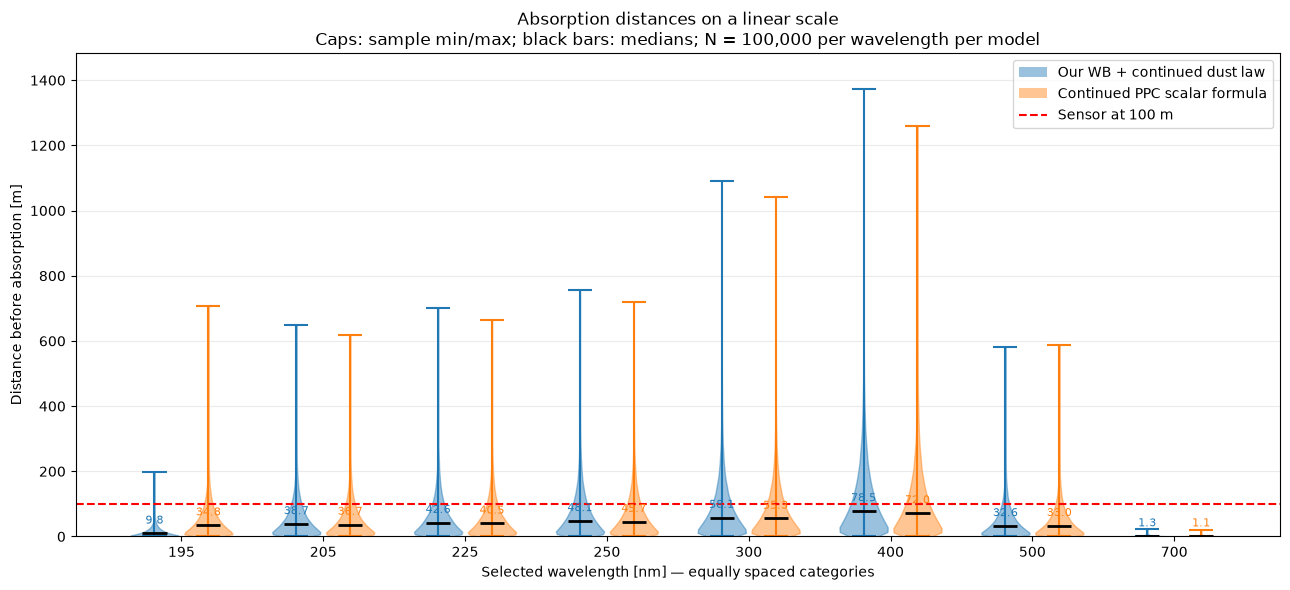

In [65]:
fig, ax = plt.subplots(figsize=(13, 6))

for distances, offset, color, label in [
    (distances_ours, -0.19, "tab:blue",
     "Our WB + continued dust law"),
    (distances_ppc, 0.19, "tab:orange",
     "Continued PPC scalar formula"),
]:
    violin = ax.violinplot(
        [row for row in distances],
        positions=positions + offset,
        widths=0.34,
        showmedians=True,
        showextrema=True
    )

    for body in violin["bodies"]:
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.45)

    # End caps show the exact minimum/maximum of this photon sample.
    for part in ("cmins", "cmaxes", "cbars"):
        violin[part].set_color(color)
        violin[part].set_linewidth(1.5)

    violin["cmedians"].set_color("black")
    violin["cmedians"].set_linewidth(2)

    for x, median in zip(
        positions + offset, np.median(distances, axis=1)
    ):
        ax.annotate(
            f"{median:.1f}",
            (x, median),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center", fontsize=8, color=color
        )

ax.axhline(
    D_SENSOR, color="red", linestyle="--",
    label=f"Sensor at {D_SENSOR:g} m"
)

upper_limit = max(distances_ours.max(), distances_ppc.max(), D_SENSOR)
ax.set_ylim(0, 1.08 * upper_limit)
ax.set_xticks(positions)
ax.set_xticklabels([f"{w:g}" for w in selected_wavelengths])
ax.set_xlabel("Selected wavelength [nm] — equally spaced categories")
ax.set_ylabel("Distance before absorption [m]")
ax.set_title(
    "Absorption distances on a linear scale\n"
    f"Caps: sample min/max; black bars: medians; N = {N_PER_WAVELENGTH:,} per wavelength per model"
)

ax.legend(handles=[
    Patch(facecolor="tab:blue", alpha=0.45,
          label="Our WB + continued dust law"),
    Patch(facecolor="tab:orange", alpha=0.45,
          label="Continued PPC scalar formula"),
    plt.Line2D([0], [0], color="red", linestyle="--",
               label=f"Sensor at {D_SENSOR:g} m")
])
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
fig.savefig(figure_folder / "independent_photon_violins_linear_bounds.png", dpi=160, bbox_inches="tight")
plt.show()

### 4.4 Composite absorption-distance PDFs

The first comparison pools all emitted wavelengths from 313–560 nm. Wavelengths follow the notebook's
Cherenkov emission spectrum; the same wavelength sample is reused for all
four models.

At each sampled wavelength and for each model, two independent exponential
distances are drawn: $D_{\rm dust}$ from the dust absorption rate and
$D_{\rm ice}$ from the intrinsic-ice rate. The model's composite distance is
$D=\min(D_{\rm dust},D_{\rm ice})$. Pure Warren–Brandt ice has zero dust rate.
The plot compares the three dusty composite PDFs with the pure-ice PDF.
It shows **random absorption distances**, not a distribution of the model
parameter $L=1/a$.

The dashed expectation is a Cherenkov-weighted mixture of exponentials, not
a single exponential fitted to the pooled histogram. This scalar model does
not simulate grain collisions, scattering or a changing depth along a photon
path. Original Ackermann and SPICE use different intrinsic-ice terms from
Warren–Brandt, so their curves can cross the Warren–Brandt pure-ice curve
without implying that dust improves transparency.

A second pooled figure below compares the selected model's separate dust
and intrinsic-ice clocks with their minimum, and identifies which clock
ended each photon.

The pooled PDF is shown on **linear axes from 0 to 1000 m**. Distances
beyond 1000 m remain in the Monte Carlo sample but are outside this view;
the displayed portion is not renormalized. Pooling wavelengths cannot
diagnose a crossover at one particular wavelength, so the original
wavelength-specific PDFs are restored below.

#### 4.4.1 Pooled comparison plot — 0 to 1000 m, linear axes

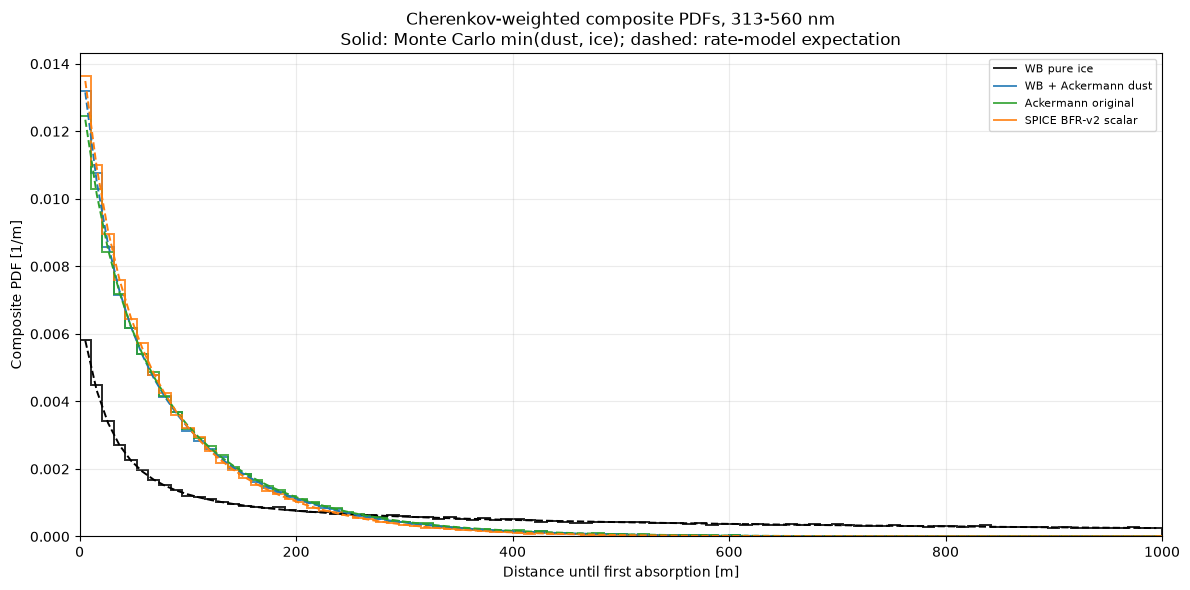

In [66]:
# ONE POOLED-WAVELENGTH COMPOSITE COMPARISON - both axes linear.
fig, ax = plt.subplots(figsize=(12, 6))
for model in PDF_MODELS:
    color = PDF_COLORS[model]
    ax.stairs(pdf_histograms[model], pdf_linear_edges, color=color,
              lw=1.4, alpha=.85, label=model)
    ax.plot(pdf_centres, pdf_expected[model], '--', color=color, lw=1.4)

ax.set_xlim(0, PDF_PLOT_MAX_M)
ax.set_ylim(bottom=0)
ax.set_xlabel('Distance until first absorption [m]')
ax.set_ylabel('Composite PDF [1/m]')
ax.set_title(
    f'Cherenkov-weighted composite PDFs, {PDF_WAVELENGTH_RANGE_NM[0]:g}-'
    f'{PDF_WAVELENGTH_RANGE_NM[1]:g} nm\n'
    'Solid: Monte Carlo min(dust, ice); dashed: rate-model expectation'
)
ax.grid(alpha=.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(pdf_output_dir / 'pooled_composite_pdf_comparison.png',
            dpi=160, bbox_inches='tight')
plt.show()


### 4.5 Which component absorbs first?

Set `PDF_COMPONENT_MODEL` in Section 1 to `WB + Ackermann dust`,
`Ackermann original`, or `SPICE BFR-v2 scalar`. For each emitted wavelength,
the selected model draws an independent dust distance and intrinsic-ice
distance. The **composite** distance is their minimum; a photon is assigned to
the component with the shorter sampled distance. The colored filled areas
partition the composite PDF by winning cause and sum to the black curve.

The dashed curves show what each component's distance distribution would be
*on its own*, before competition. For the WB-plus-dust selection the ice clock
uses Warren–Brandt; Ackermann original and SPICE each use their **own**
intrinsic-ice formula. All curves pool the same Cherenkov-weighted 313–560 nm
photon sample, use linear 0–1000 m axes, and are normalized by **all** sampled
photons. The reported cause percentages include photons beyond the displayed
range. This scalar competing-rates model labels a cause of absorption; it does
not resolve individual dust-grain collisions.


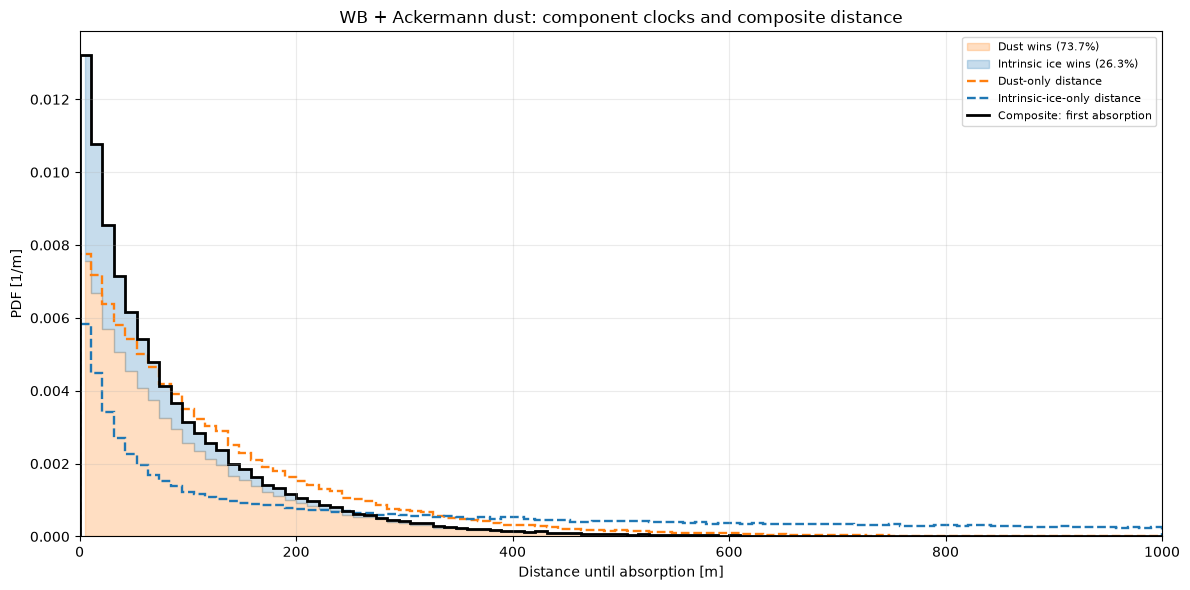

In [67]:
# Pooled component-clock plot; inputs are prepared in Section 2.6.
fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(
    pdf_centres, 0., component_pdfs['dust_wins'], step='mid',
    color='tab:orange', alpha=.25, label=f'Dust wins ({dust_fraction:.1%})',
)
ax.fill_between(
    pdf_centres, component_pdfs['dust_wins'], component_pdfs['composite'],
    step='mid', color='tab:blue', alpha=.25,
    label=f'Intrinsic ice wins ({ice_fraction:.1%})',
)
ax.stairs(component_pdfs['dust_only'], pdf_linear_edges, color='tab:orange',
          linestyle='--', linewidth=1.7, label='Dust-only distance')
ax.stairs(component_pdfs['ice_only'], pdf_linear_edges, color='tab:blue',
          linestyle='--', linewidth=1.7, label='Intrinsic-ice-only distance')
ax.stairs(component_pdfs['composite'], pdf_linear_edges, color='black',
          linewidth=2.0, label='Composite: first absorption')
ax.set(xlim=(0., PDF_PLOT_MAX_M), ylim=(0., None),
       xlabel='Distance until absorption [m]', ylabel='PDF [1/m]',
       title=f'{PDF_COMPONENT_MODEL}: component clocks and composite distance')
ax.grid(alpha=.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(pdf_output_dir / 'pooled_component_clocks_and_causes.png',
            dpi=160, bbox_inches='tight')
plt.show()


### 4.6 Fixed-wavelength PDFs, residuals, and ratios

Between 500 and 550 nm, figures are shown every 10 nm, followed by 560 nm. All wavelengths stay within the 313-560 nm comparison interval.

Each wavelength has one figure: the four **composite** absorption-distance PDFs
are at the top, with the residual and ratio comparisons directly below. The
top panel includes Warren–Brandt pure ice and all three dusty models. It shows
the total PDF for each model, not the separate dust and intrinsic-ice causes;
the selected-wavelength component-clock diagnostic in Section 4.7 retains
that decomposition.

Faint steps are Monte Carlo estimates on common distance bins; model-styled curves
are analytic competing-rate PDFs. They are divided by **all** sampled photons,
so the visible distance range is not renormalized. The lower panels show
analytic residuals $f_{\rm model}-f_{\rm WB}$ and ratios
$f_{\rm model}/f_{\rm WB}$ against pure ice. Zero and one, respectively,
indicate equal PDF density at that distance. A ratio above one does not
imply a longer mean absorption distance; read it together with the PDF and
residual panels, especially in the tails.

Line style identifies the model in all three panels: solid black for pure ice, dashed blue for WB + Ackermann dust, dash-dot green for Ackermann original, and dotted orange for the SPICE scalar approximation.


In [68]:
# Plotting only: all rates, samples, and shared-bin PDFs are prepared in Section 2.6.
def plot_fixed_wavelength_pdf_comparison(wavelength_nm):
    '''Show the composite PDFs with residual and ratio panels below.'''
    wavelength_nm = float(wavelength_nm)
    data = per_wl_comparison_data[wavelength_nm]
    distance = data['distance_m']
    bin_edges = data['bin_edges_m']
    limit = float(distance[-1])

    fig, (pdf_ax, residual_ax, ratio_ax) = plt.subplots(
        3, 1, figsize=(14, 10), sharex=True,
        gridspec_kw={'height_ratios': (2.5, 1.2, 1.2)},
        constrained_layout=True,
    )
    for model in PER_WL_MODELS:
        color = PDF_COLORS[model]
        pdf_ax.stairs(data['mc_pdfs'][model]['combined'], bin_edges,
                      color=color, lw=.75, alpha=.25)
        pdf_ax.plot(distance, data['exact_pdfs'][model]['combined'],
                    color=color, linestyle=PDF_LINESTYLES[model],
                    lw=2.4, label=model)
    pdf_ax.set(title='Composite: distance to first absorption',
               ylabel='PDF [1/m]', xlim=(0., limit), ylim=(0., None))
    pdf_ax.legend(ncol=2, fontsize=9, loc='upper right')

    for model in crossover_models:
        color = PDF_COLORS[model]
        residual_ax.plot(distance, data['residuals'][model], color=color,
                         linestyle=PDF_LINESTYLES[model], lw=2.2)
        ratio_ax.plot(distance, data['ratios'][model], color=color,
                      linestyle=PDF_LINESTYLES[model], lw=2.2)
    residual_ax.axhline(0., color='black', lw=1., alpha=.65)
    ratio_ax.axhline(1., color='black', lw=1., alpha=.65)
    residual_ax.set(ylabel='Model - WB PDF [1/m]', xlim=(0., limit))
    ratio_ax.set(ylabel='Model / WB PDF', xlim=(0., limit),
                 xlabel='Distance until first absorption [m]')

    for ax in (pdf_ax, residual_ax, ratio_ax):
        ax.grid(alpha=.22)
    fig.suptitle(
        f'{wavelength_nm:g} nm - absorption PDFs at Ackermann {ACK_DEPTH_M:g} m '
        f'and SPICE {PPC_DEPTH_M:.2f} m\n'
        f'{N_PER_WL_PDF_SAMPLES:,} photons per model; styled lines = rate model, '
        'faint steps = Monte Carlo', fontsize=14,
    )
    fig.savefig(per_wl_output / f'fixed_{wavelength_nm:g}nm_pdf_diagnostics.png',
                dpi=160, bbox_inches='tight')
    plt.show()


#### 325 nm


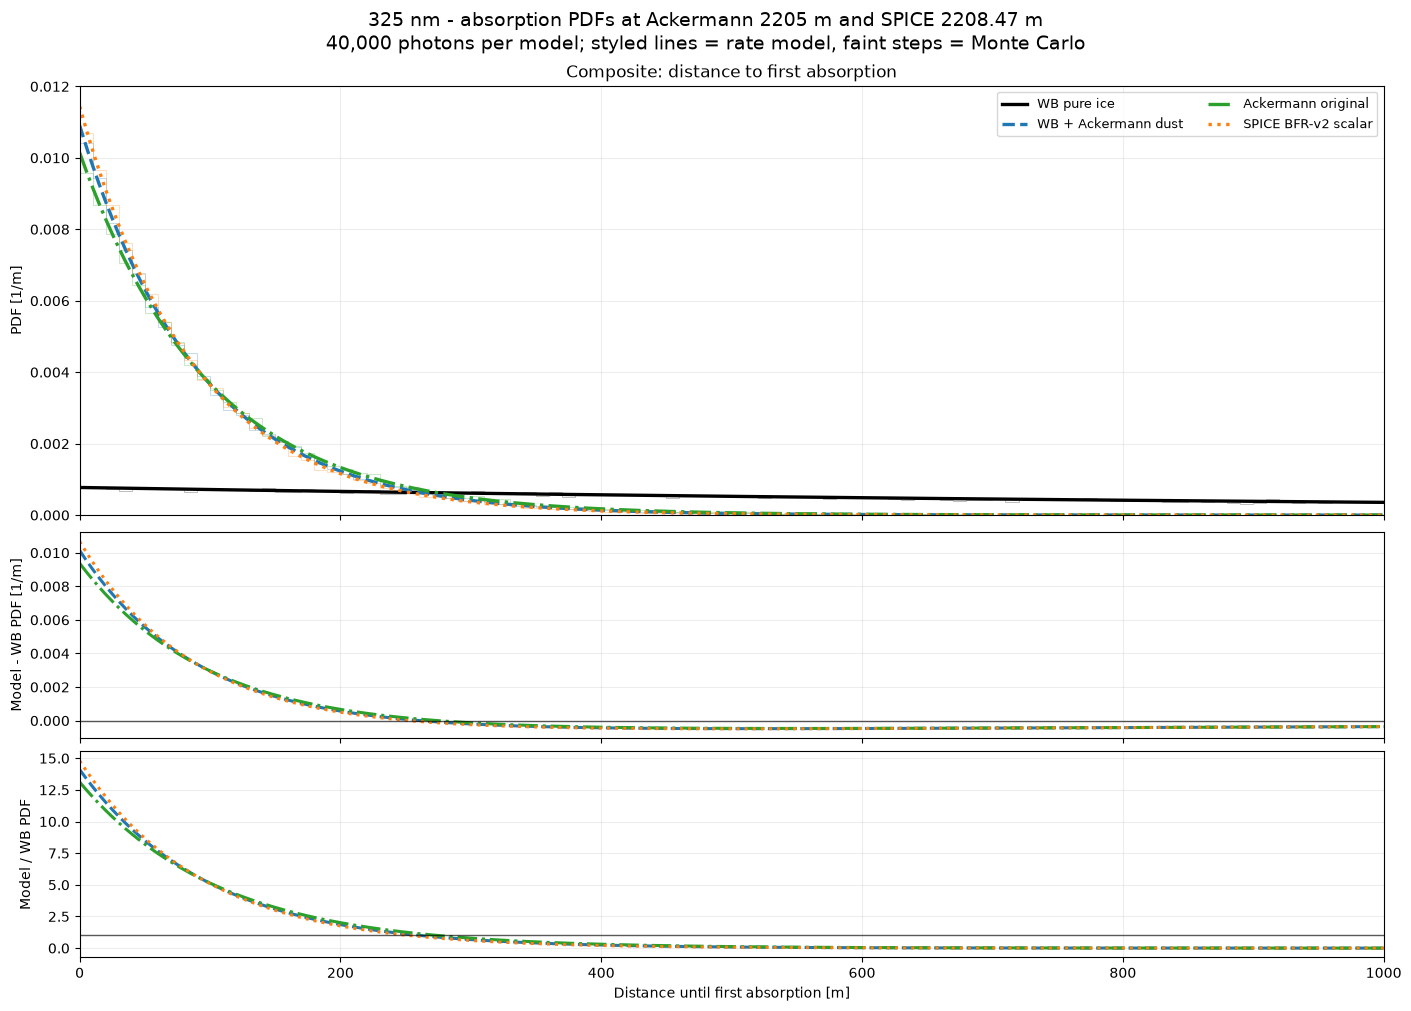

In [69]:
plot_fixed_wavelength_pdf_comparison(325.)


#### 405 nm


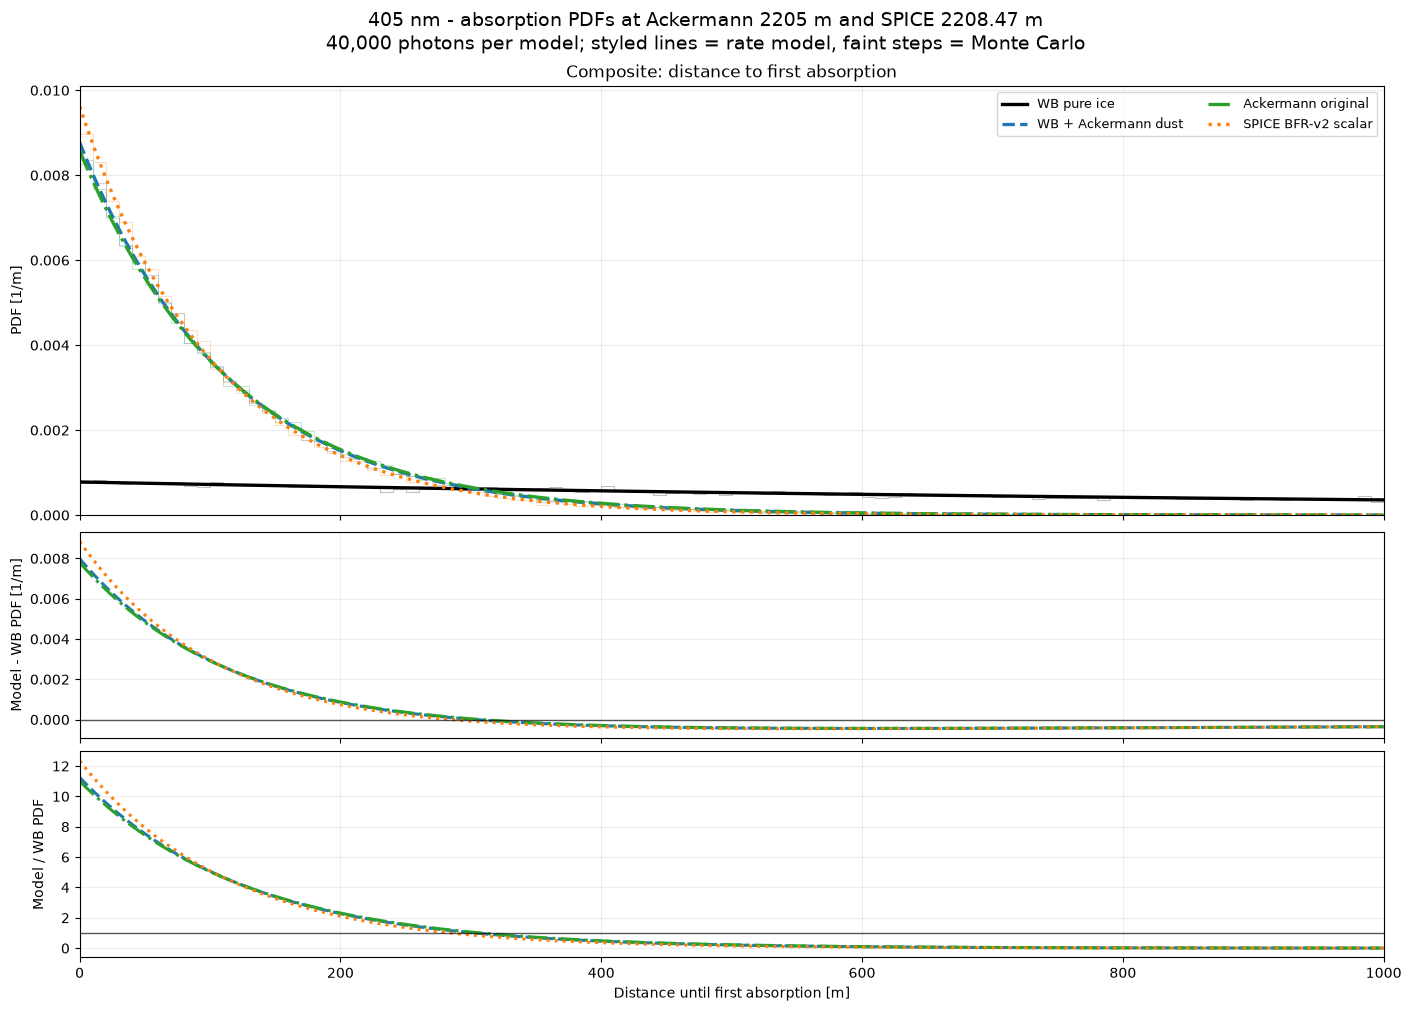

In [70]:
plot_fixed_wavelength_pdf_comparison(405.)


#### 500 nm


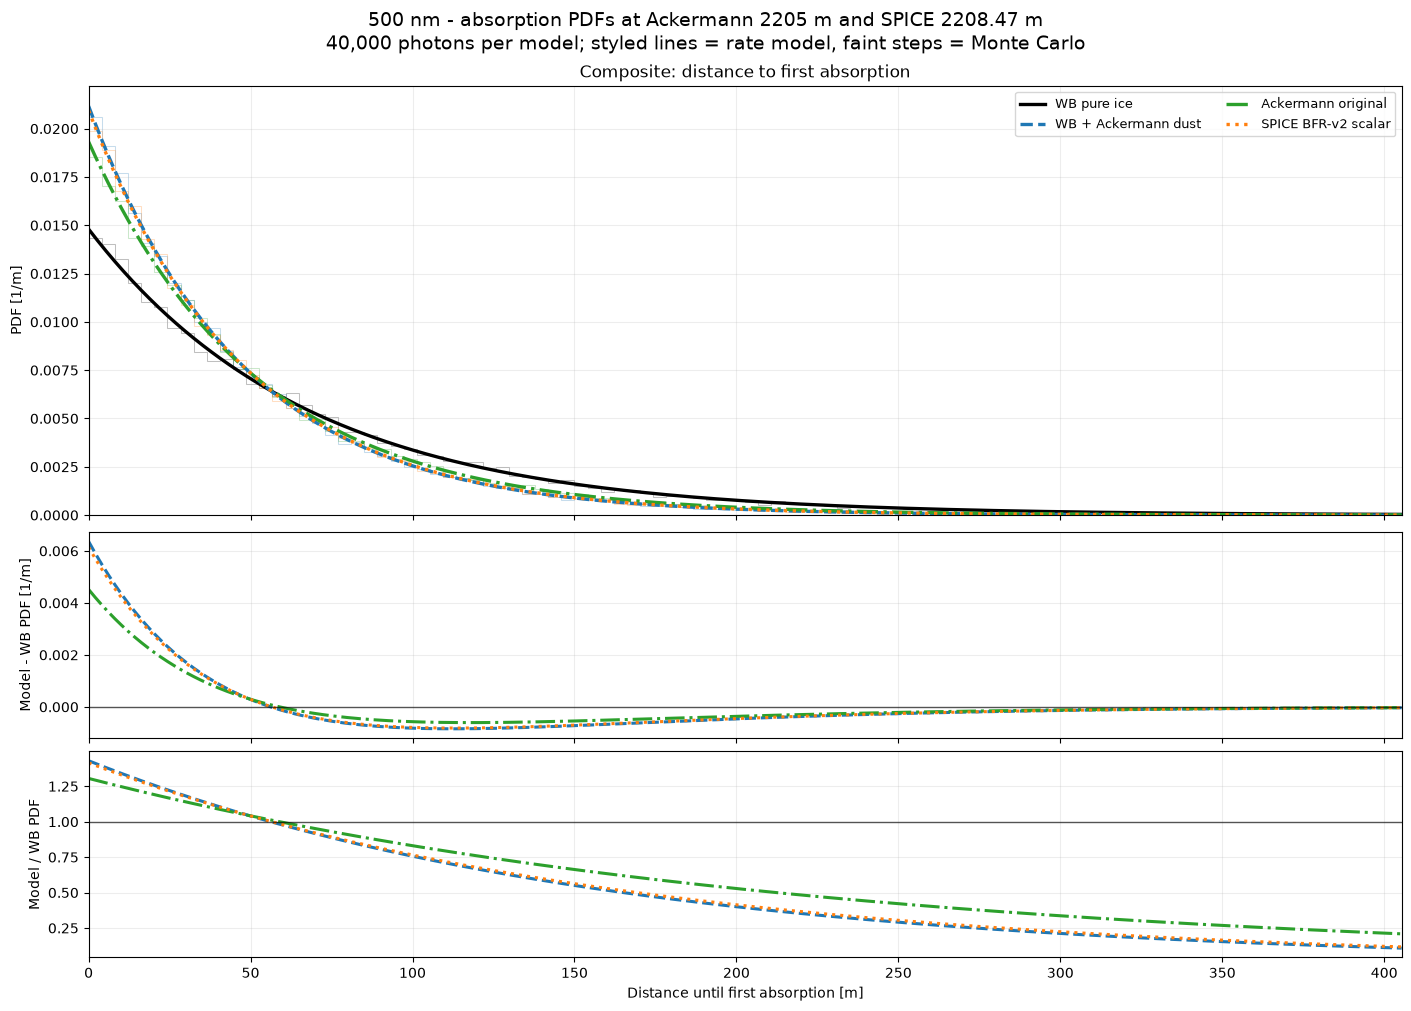

In [71]:
plot_fixed_wavelength_pdf_comparison(500.)


#### 510 nm


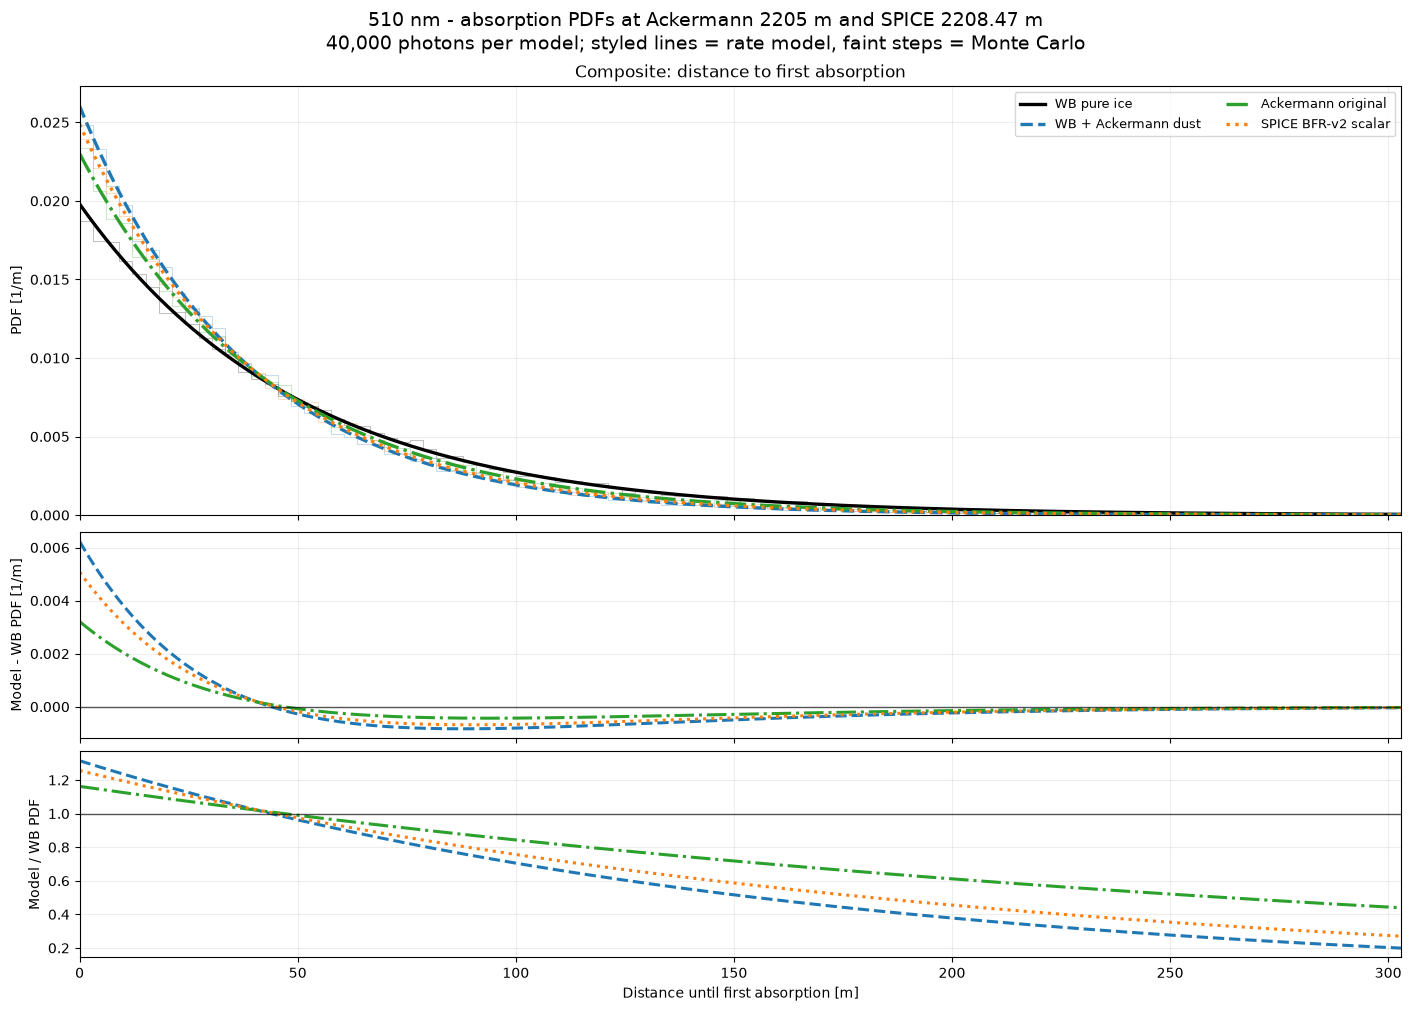

In [72]:
plot_fixed_wavelength_pdf_comparison(510.)


#### 520 nm


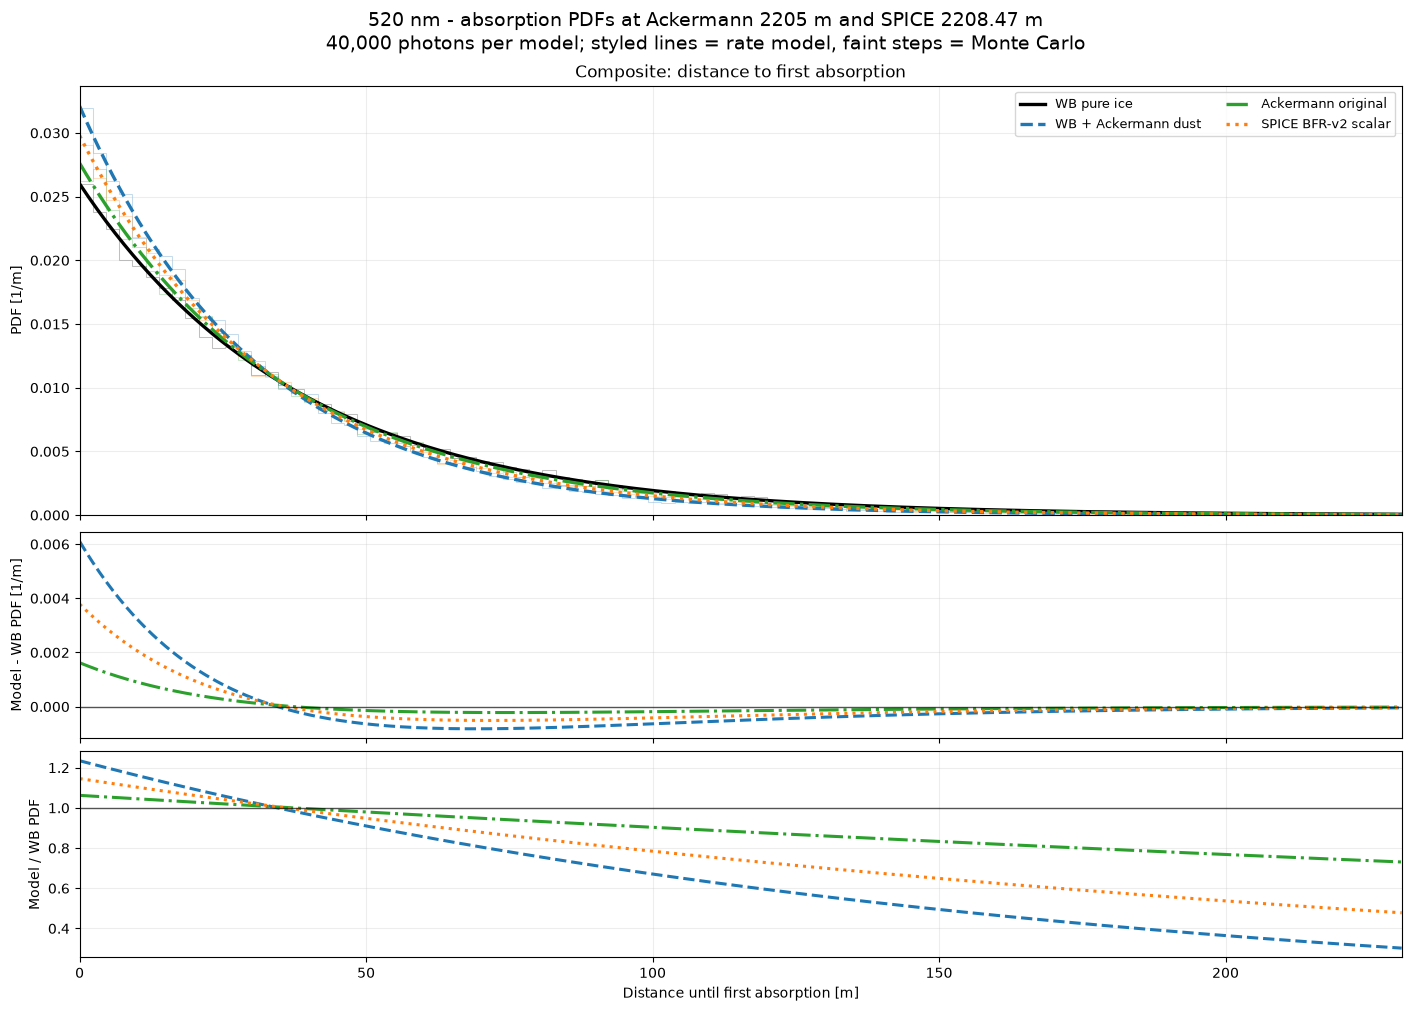

In [73]:
plot_fixed_wavelength_pdf_comparison(520.)


#### 530 nm


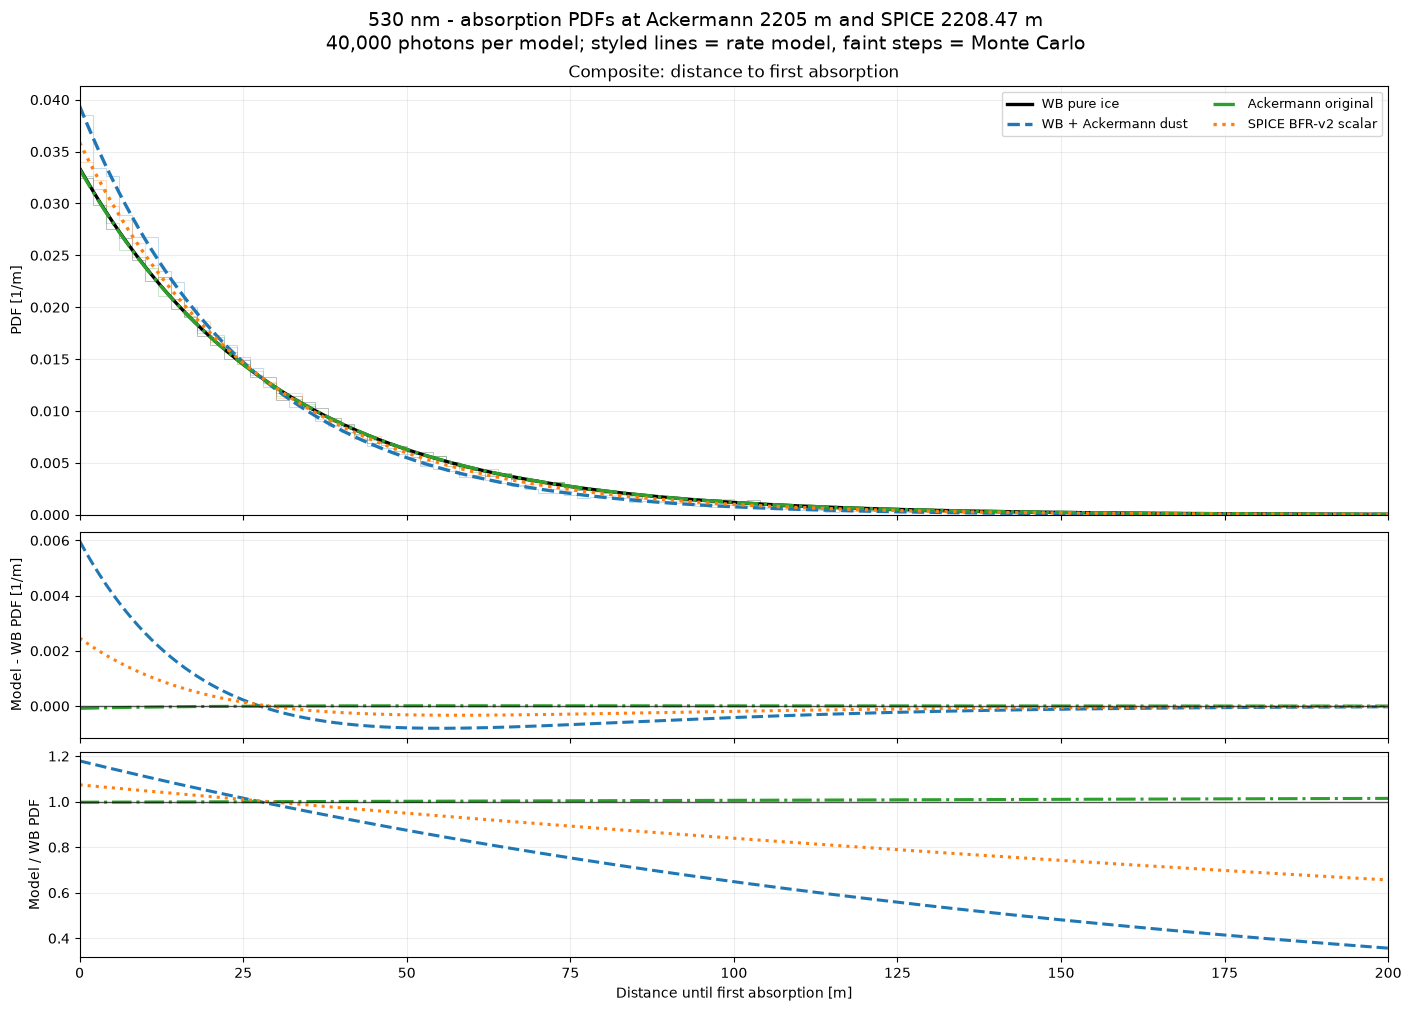

In [74]:
plot_fixed_wavelength_pdf_comparison(530.)


#### 540 nm


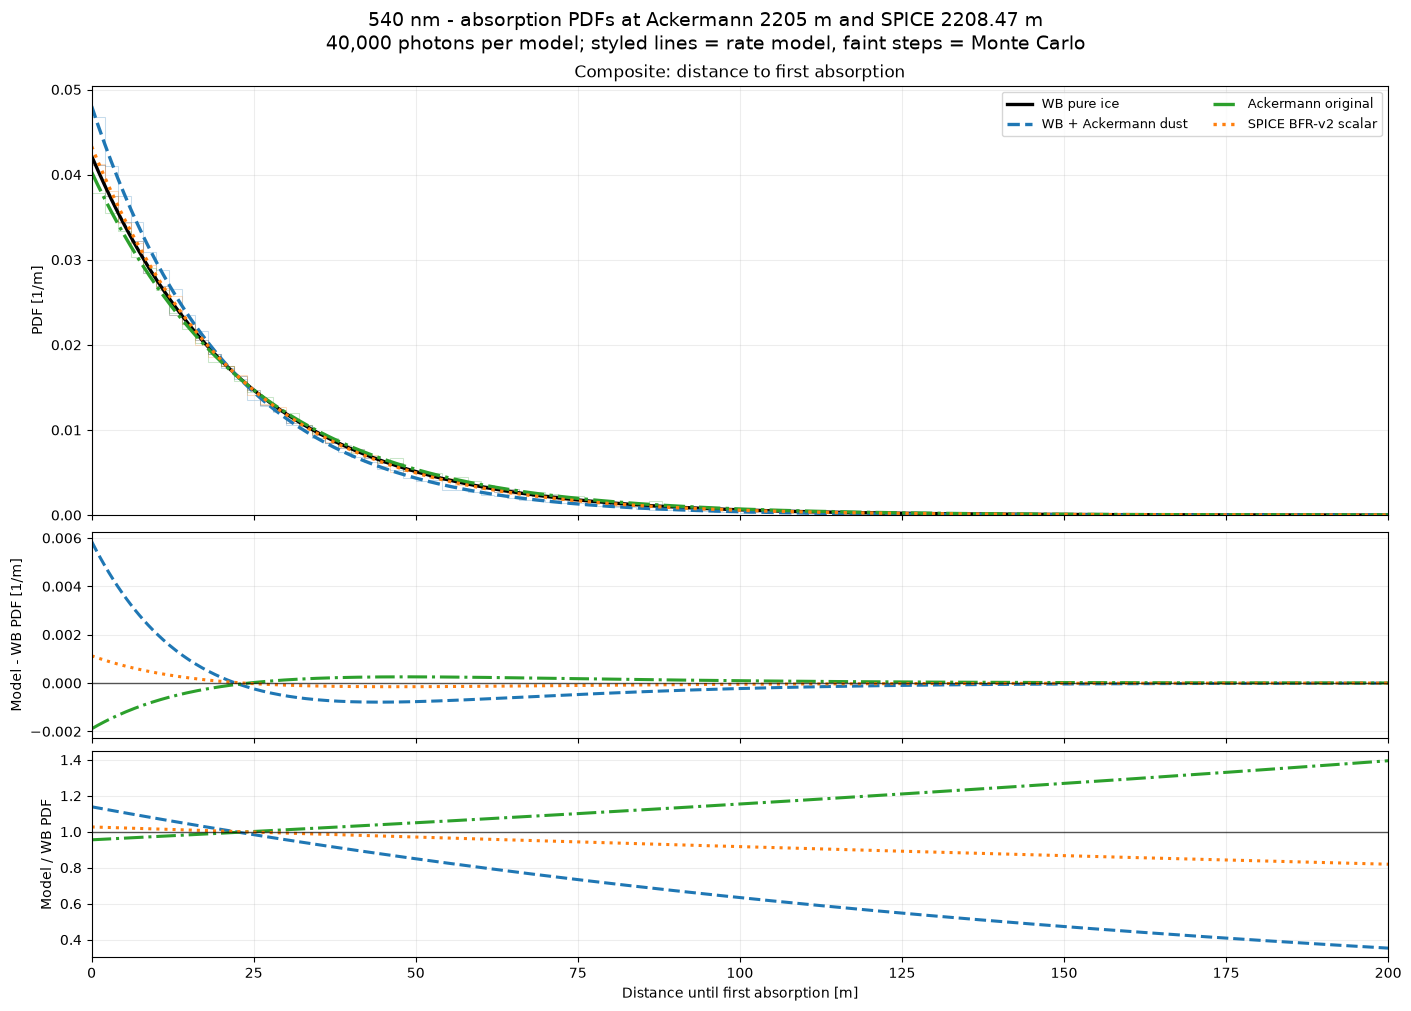

In [75]:
plot_fixed_wavelength_pdf_comparison(540.)


#### 550 nm


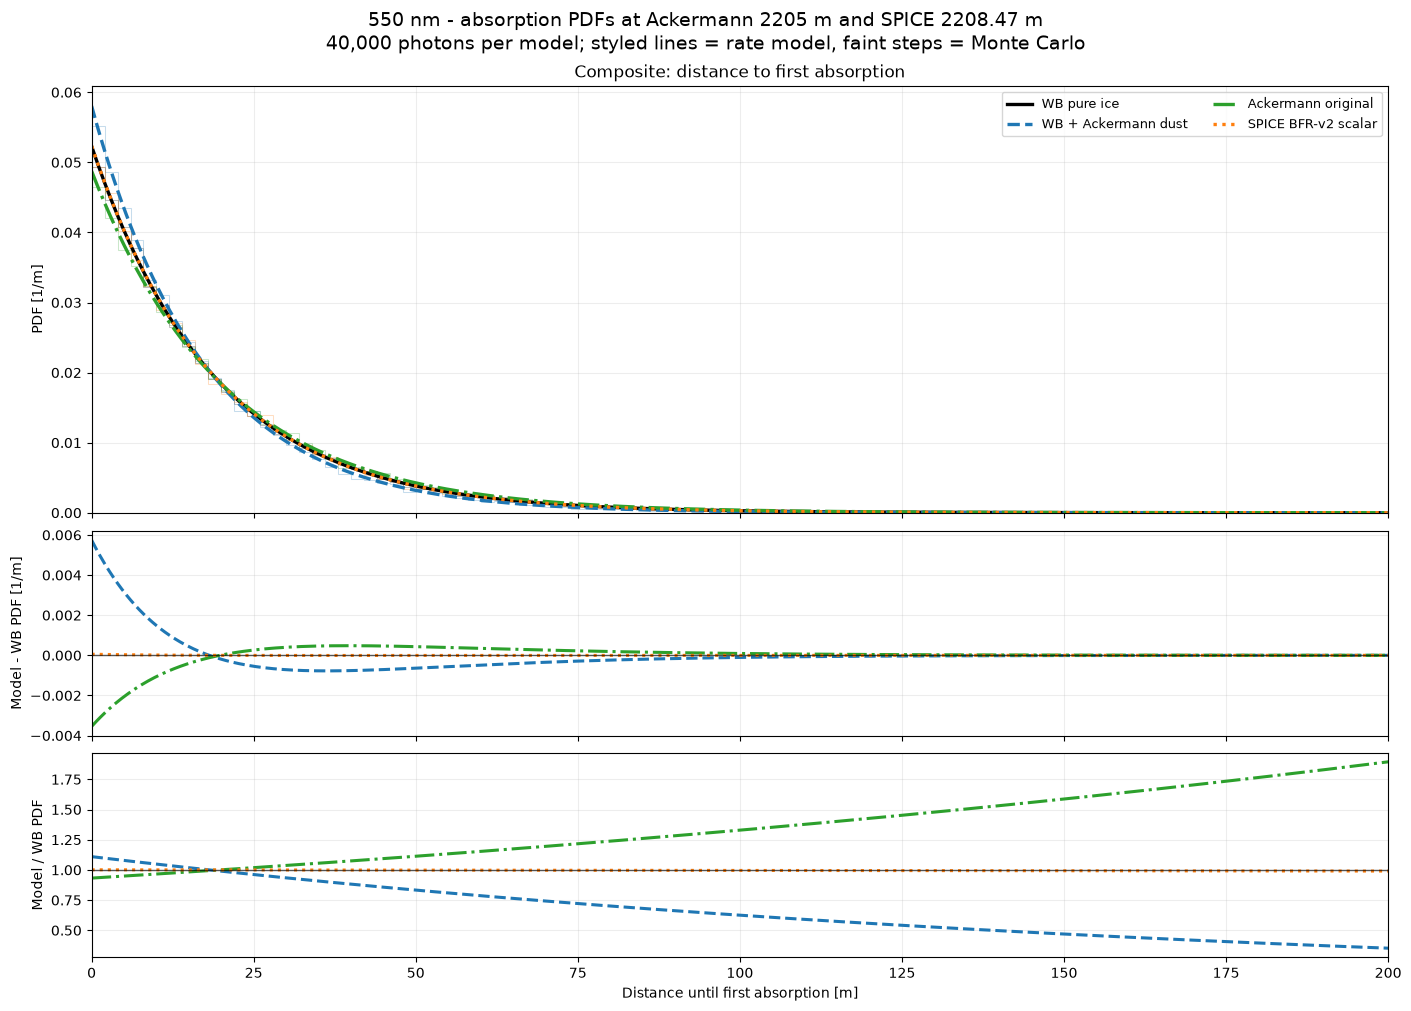

In [76]:
plot_fixed_wavelength_pdf_comparison(550.)


#### 560 nm


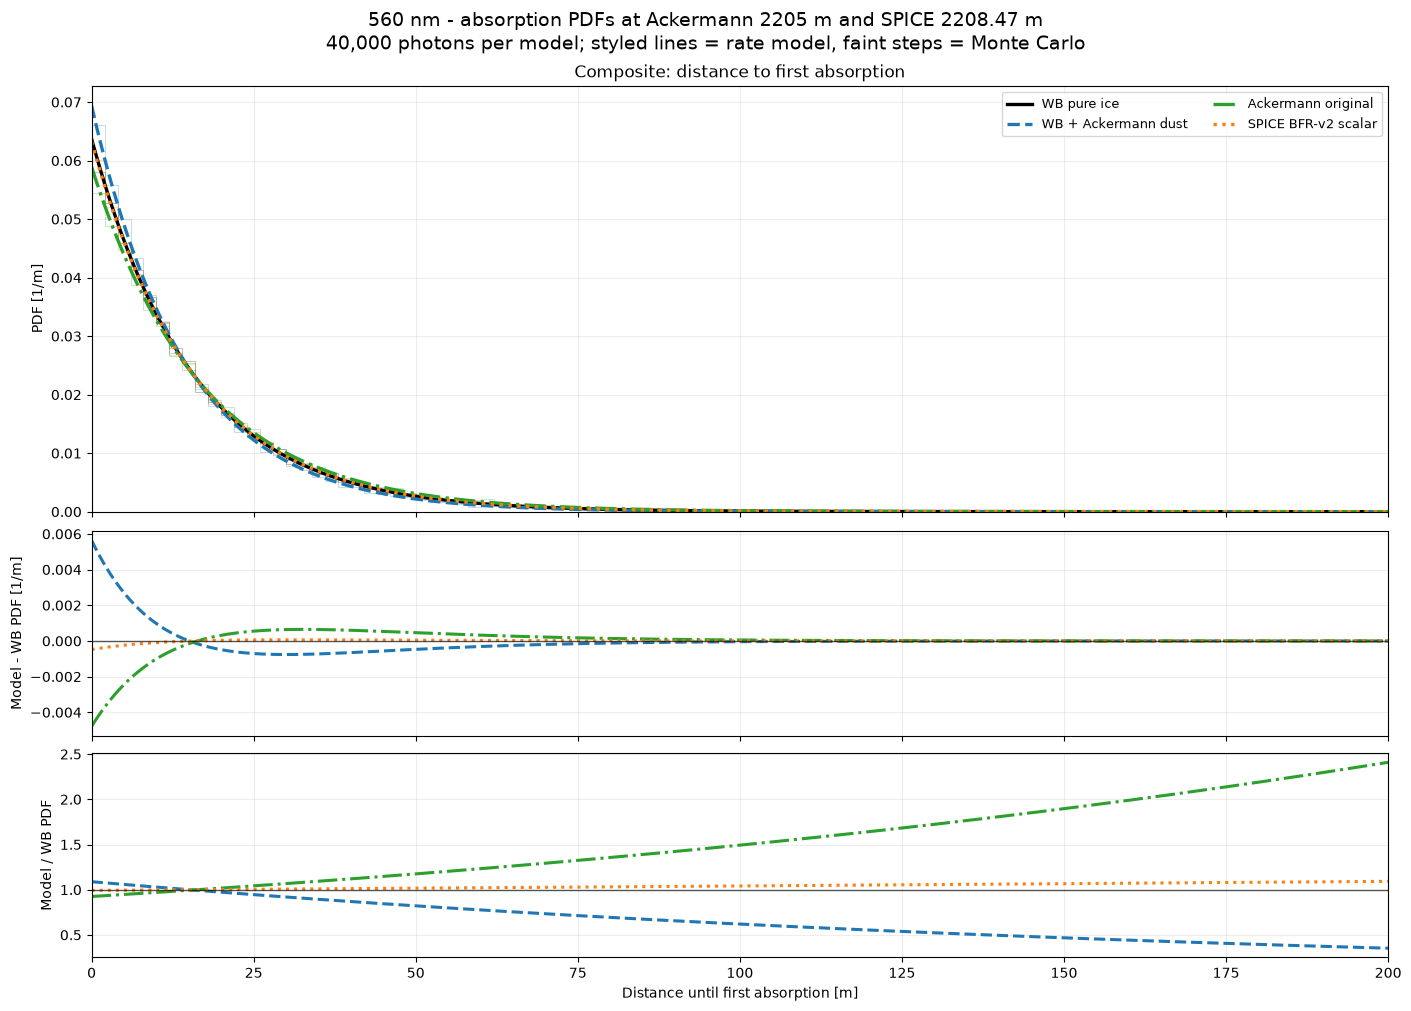

In [77]:
plot_fixed_wavelength_pdf_comparison(560.)


### 4.7 Separate component clocks at the selected wavelength

This additional diagnostic retains the **unconditioned** dust-only and
ice-only clocks for each dusty model. The filled areas instead show which
cause wins for each sampled photon, and the black curve is their composite.
It uses `PDF_SINGLE_WAVELENGTH_NM` from Section 1; the overview for that
wavelength, including residual and ratio, appears above.


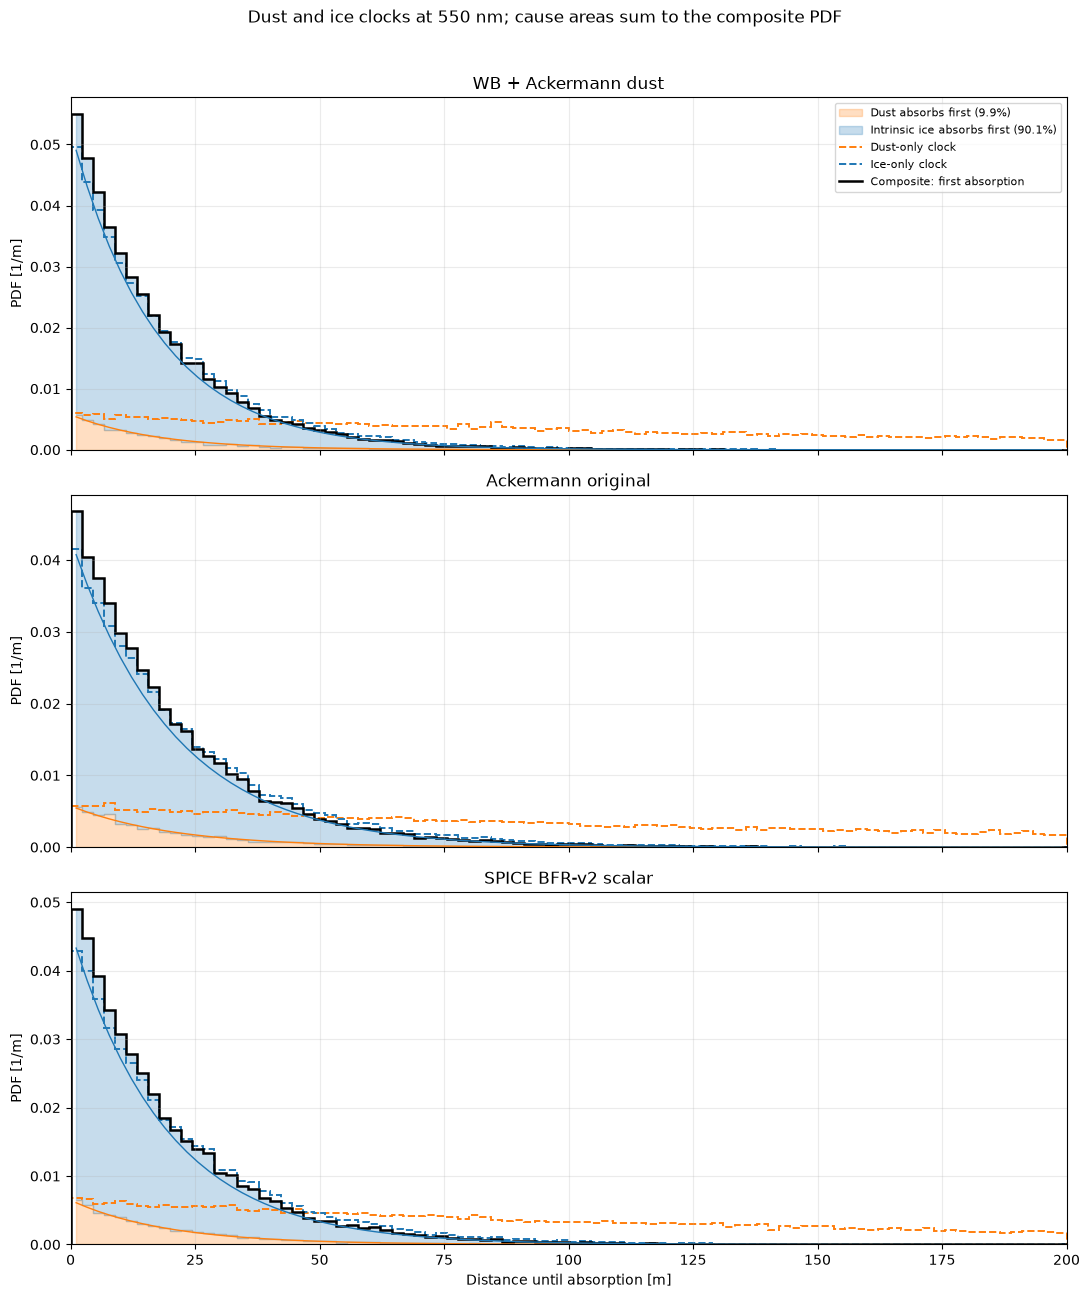

In [78]:
# At the selected wavelength, show separate clocks and winning causes.
fig, axes = plt.subplots(3, 1, figsize=(11, 13), sharex=True)
for ax, model in zip(axes, crossover_models):
    hist = single_component_histograms[model]
    exact = single_component_exact[model]
    fraction = float(single_summary.loc[
        single_summary.model == model, 'dust_fraction_exact'
    ].iloc[0])
    ax.fill_between(single_centres, 0., hist['dust_wins'], step='mid',
                    color='tab:orange', alpha=.25,
                    label=f'Dust absorbs first ({fraction:.1%})')
    ax.fill_between(single_centres, hist['dust_wins'],
                    single_histograms[model], step='mid',
                    color='tab:blue', alpha=.25,
                    label=f'Intrinsic ice absorbs first ({1.-fraction:.1%})')
    ax.stairs(hist['dust_only'], single_edges, color='tab:orange',
              linestyle='--', lw=1.4, label='Dust-only clock')
    ax.stairs(hist['ice_only'], single_edges, color='tab:blue',
              linestyle='--', lw=1.4, label='Ice-only clock')
    ax.stairs(single_histograms[model], single_edges, color='black',
              lw=1.8, label='Composite: first absorption')
    ax.plot(single_centres, exact['dust_wins'], color='tab:orange', lw=1.)
    ax.plot(single_centres, exact['ice_wins'], color='tab:blue', lw=1.)
    ax.set(xlim=(0., PDF_SINGLE_PLOT_MAX_M), ylim=(0., None),
           ylabel='PDF [1/m]', title=model)
    ax.grid(alpha=.25)
axes[-1].set_xlabel('Distance until absorption [m]')
axes[0].legend(fontsize=8)
fig.suptitle(f'Dust and ice clocks at {single_wl:g} nm; '
             'cause areas sum to the composite PDF', y=.995)
fig.tight_layout(rect=(0., 0., 1., .98))
fig.savefig(per_wl_output / f'fixed_{single_wl:g}nm_component_clocks.png',
            dpi=160, bbox_inches='tight')
plt.show()


## 5. Dust logger depth comparisons

### 5.1 Supplied course logger record

The left panel repeats the 405 nm absorption-length comparison from Section 3.4. The right panel shows the **supplied optical logger signal** from `dust_logger.txt` at the same plotted depths. Its signal has a separate, logarithmic x-axis so the observed variations in clearer ice remain visible. The gray area marks depths above the first logger measurement.

The file contains depth and a positive logger value, but does not identify the borehole or provide an absolute intensity or dust-mass calibration. These are **not absorption lengths or coefficients**, so the two horizontal scales must not be equated. Any feature-by-feature comparison also requires confirming that the logger and model depths refer to the same registered location. No photons are sampled in this figure.


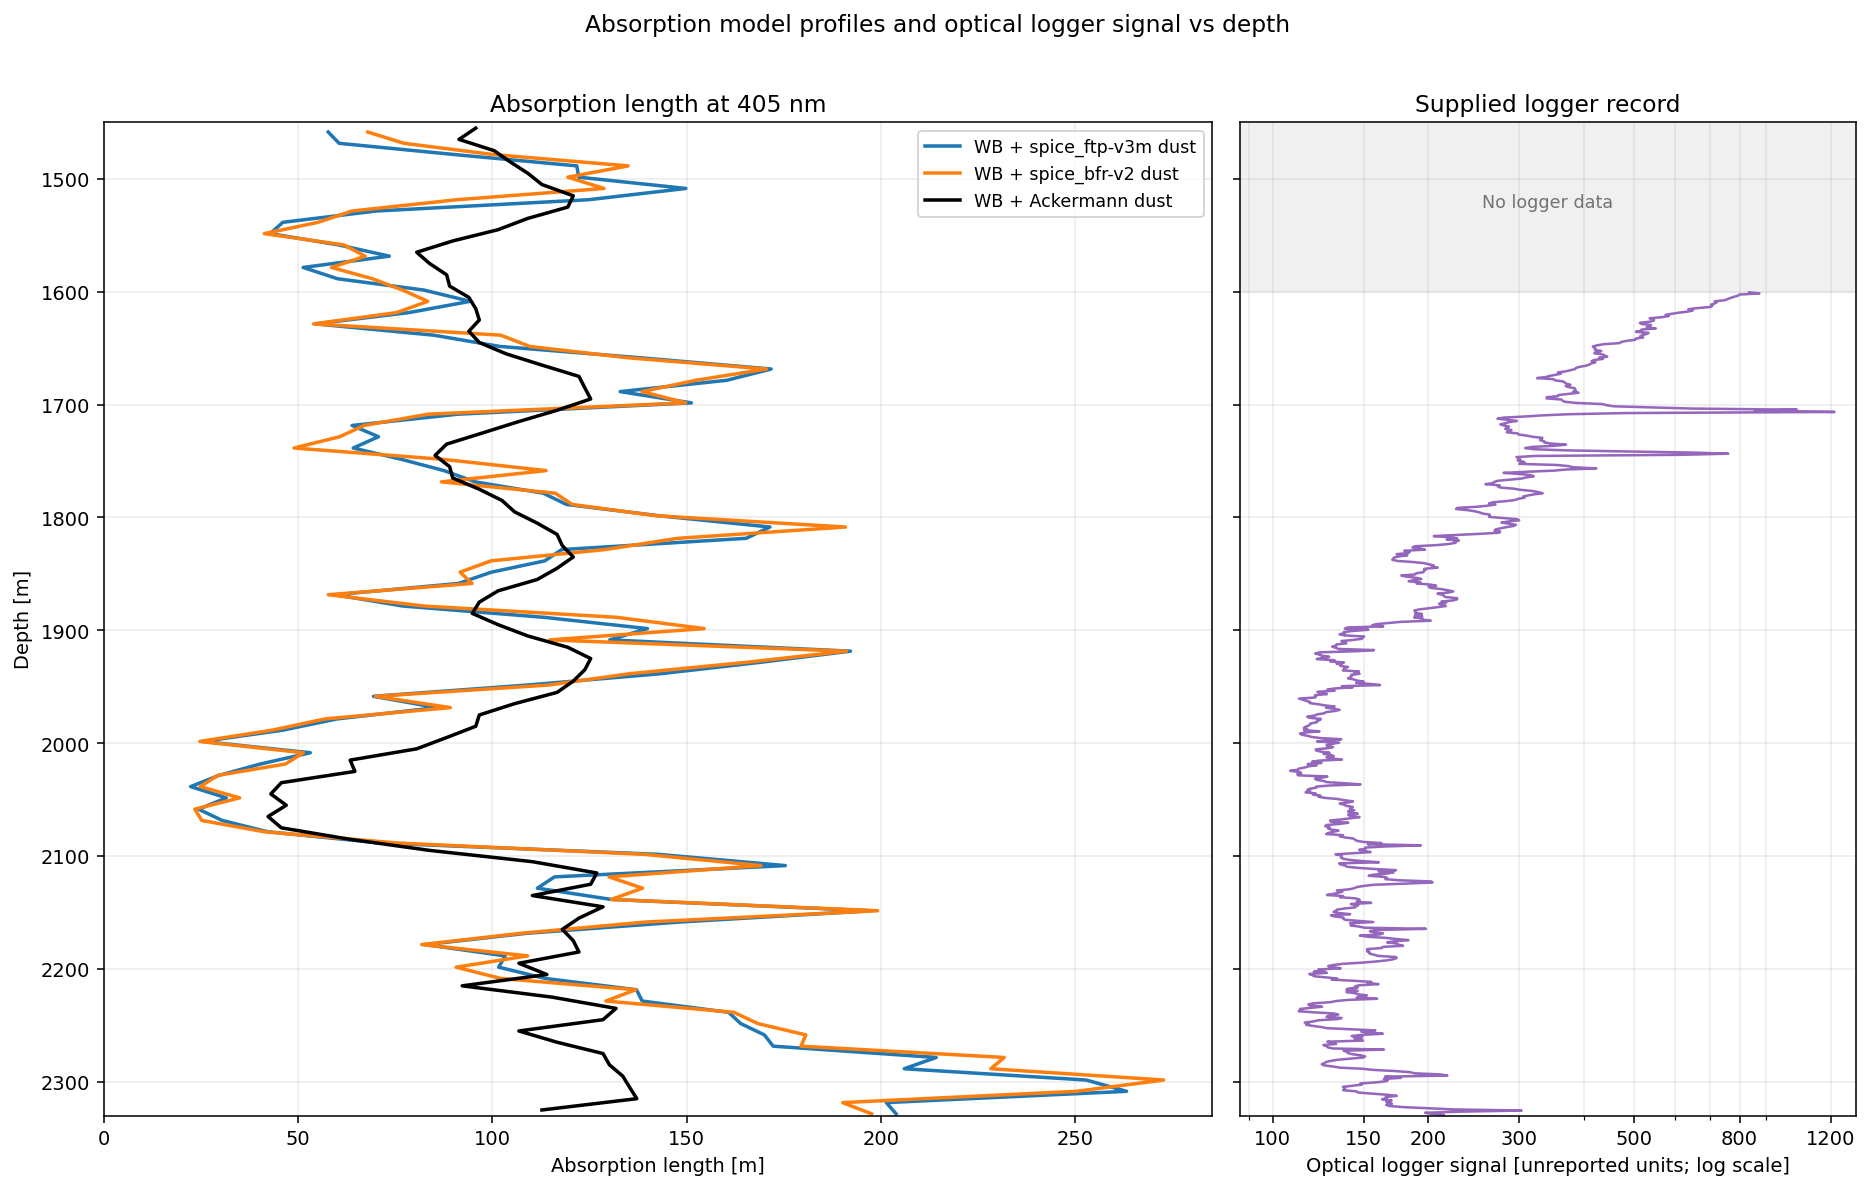

In [79]:
# Plotting only: depth curves and validated logger values were prepared in Section 2.5.
fig, (ax_length, ax_logger) = plt.subplots(
    1, 2, figsize=(13.5, 8.5), sharey=True,
    gridspec_kw={'width_ratios': (1.8, 1.)},
)
for (source, (depths, lengths)), color in zip(
    comparison_plot_data.items(), ('tab:blue', 'tab:orange', 'black')
):
    ax_length.plot(lengths, depths, lw=1.8, color=color,
                   label=f'WB + {source} dust')
ax_length.set(
    xlabel='Absorption length [m]', ylabel='Depth [m]',
    title=f'Absorption length at {COMPARISON_WAVELENGTH_NM:g} nm',
    ylim=(COMPARISON_DEPTH_RANGE_M[1], COMPARISON_DEPTH_RANGE_M[0]),
)
ax_length.set_xlim(left=0.)
ax_length.grid(alpha=.25)
ax_length.legend(loc='best', fontsize=9)

ax_logger.plot(dust_logger_plot_signal, dust_logger_plot_depth_m,
               color='tab:purple', lw=1.3, label='Supplied dust logger')
ax_logger.axhspan(COMPARISON_DEPTH_RANGE_M[0], dust_logger_depth_m.min(),
                  color='0.94', zorder=0)
ax_logger.text(.5, .92, 'No logger data', transform=ax_logger.transAxes,
               ha='center', va='center', color='0.45', fontsize=9)
ax_logger.set_xscale('log')
ax_logger.set_xlim(dust_logger_plot_signal.min() * .8,
                   dust_logger_plot_signal.max() * 1.1)
logger_ticks = np.array([100, 150, 200, 300, 500, 800, 1200])
logger_ticks = logger_ticks[(logger_ticks > ax_logger.get_xlim()[0])
                            & (logger_ticks < ax_logger.get_xlim()[1])]
ax_logger.set_xticks(logger_ticks)
ax_logger.set_xticklabels([str(value) for value in logger_ticks])
ax_logger.set_xlabel('Optical logger signal [unreported units; log scale]')
ax_logger.set_title('Supplied logger record')
ax_logger.grid(alpha=.25, which='both')

fig.suptitle('Absorption model profiles and optical logger signal vs depth', y=.995)
fig.tight_layout(rect=(0., 0., 1., .98))
fig.savefig(comparison_output / 'absorption_length_and_dust_logger_vs_depth.png',
            dpi=160, bbox_inches='tight')
plt.show()


### 5.2 Published IceCube dust profile on the absorption-depth comparison

The purple curve uses the public [IceCube Dust Map](https://dustmap.icecube.wisc.edu/)
[profile for String 86](https://dustmap.icecube.wisc.edu/profiles/string_86_dust.dat),
near the array centre. The site publishes a composite formed by registering eight
optical logs, then mapping the composite to individual strings. This is a
**logger-derived dust profile**, with concentration approximately normalized to
Dome C ice-core **mass ppb** (release: 15 August 2011). It is not the unidentified
course signal in Section 5.1. The original numerical download is kept in
`data/dustmap2011/`; its URL and checksum are recorded in `provenance.json`.

The bottom axis shows the same three absorption-length curves as Section 3.4;
the purple top axis shows the dust concentration, **decreasing from left to
right**. High dust concentration and short absorption length therefore both
appear on the left; cleaner ice appears on the right. Only the display axis
is reversed: all measured dust values and depths retain their original order.
**The horizontal scales are
independent: compare the depths of features, not the curves' horizontal
intersections.** More mineral dust generally corresponds to stronger dust
absorption and shorter absorption length. No conversion from ppb to an
absorption coefficient or fitted rescaling is applied.

For a readable figure, the logger samples are averaged into depth bins of
`PUBLIC_DUST_BIN_WIDTH_M` (default 1 m); the full downloaded profile is retained.
The site estimates absolute logger depth accuracy at approximately 1–2 m.
String 86 and the model tables have different spatial/depth references, so a
precise layer comparison requires registration. This plot samples no photons.


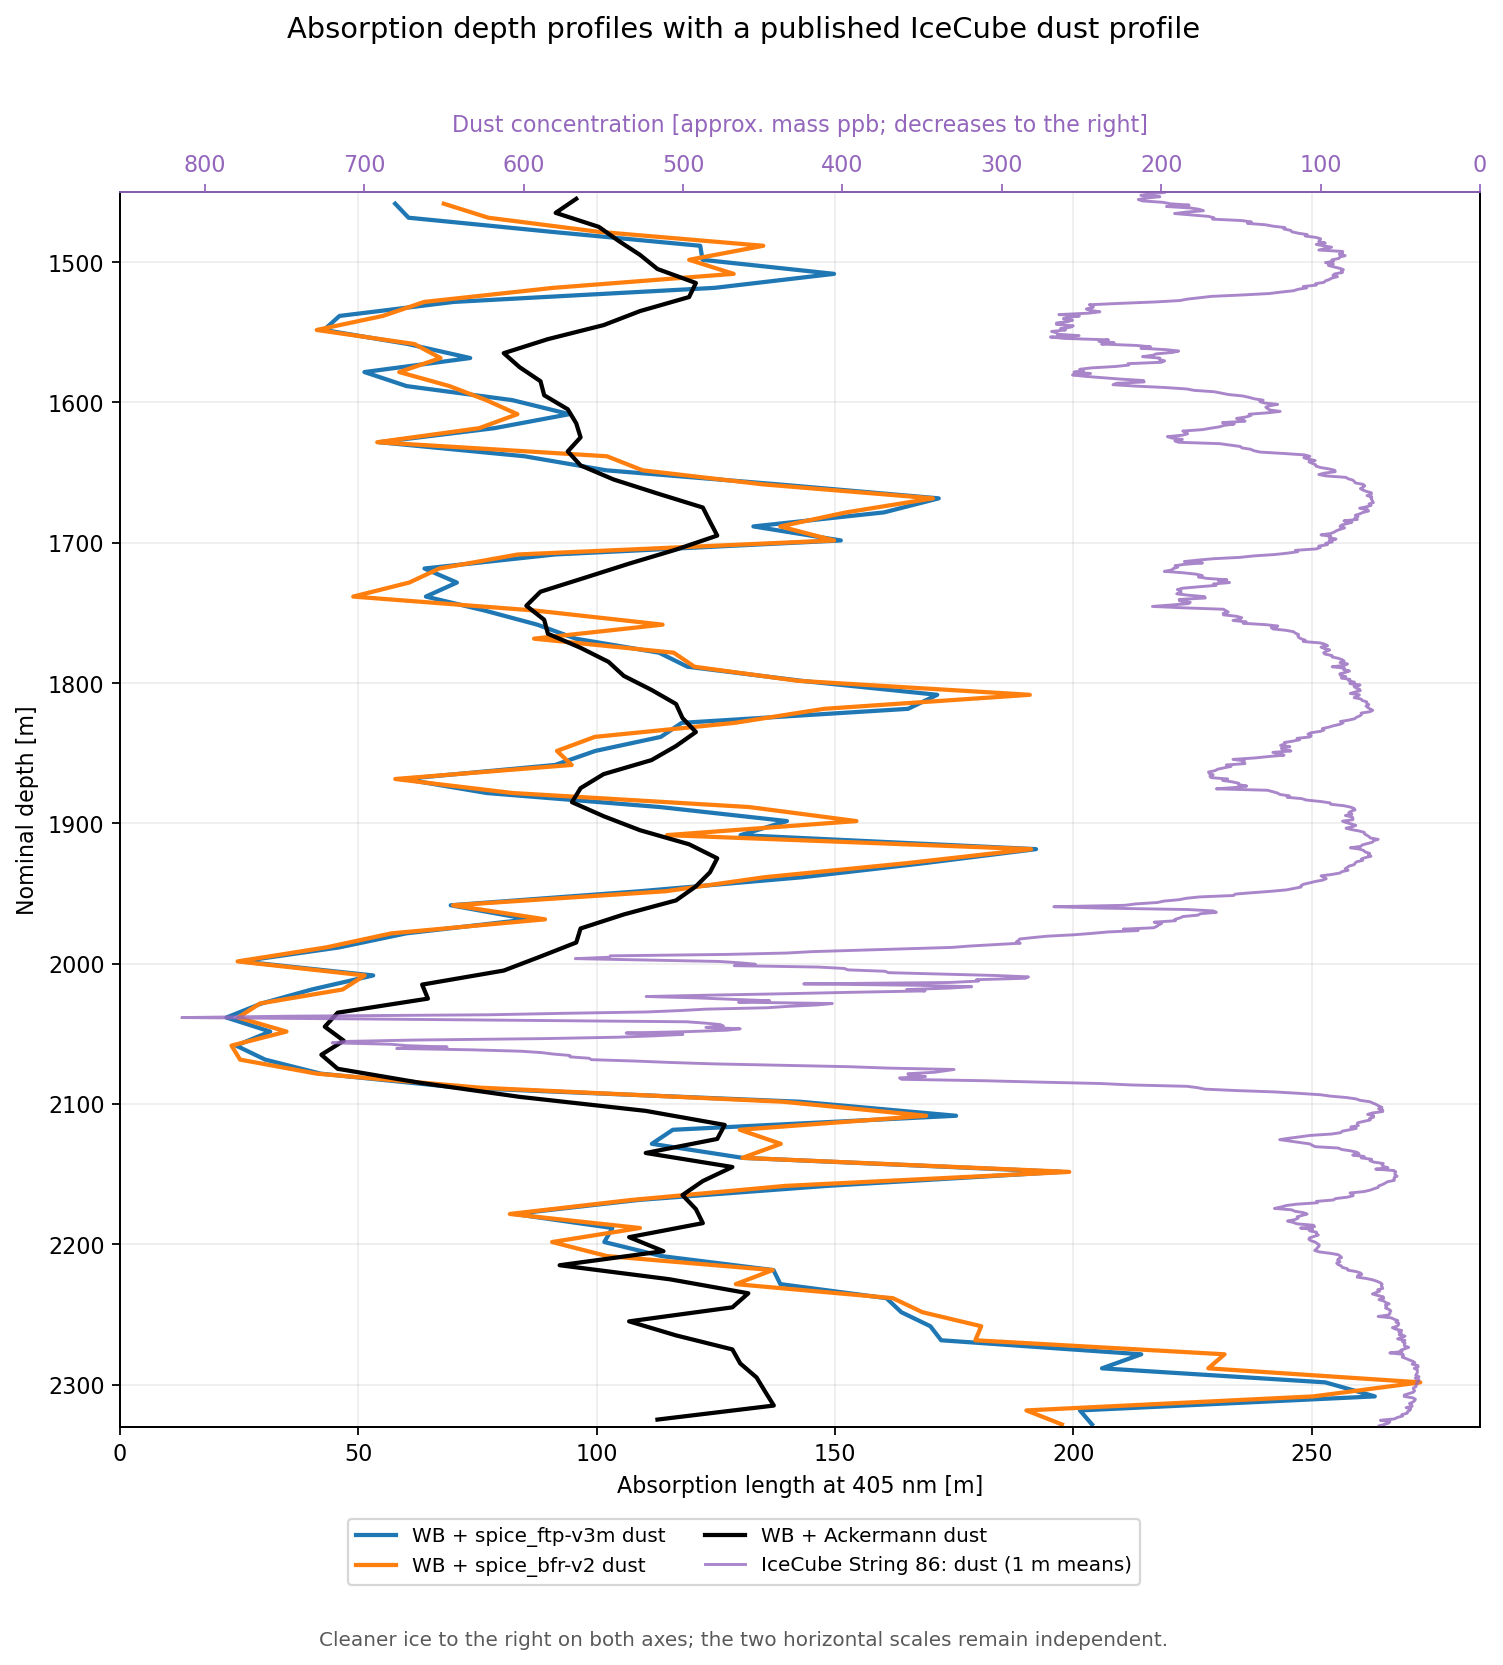

In [ ]:
# Plotting only: absorption lengths and depth-bin means were prepared in Section 2.5.
fig, ax_length = plt.subplots(figsize=(10, 10.5))
ax_dust = ax_length.twiny()
for (source, (depths, lengths)), color in zip(
    comparison_plot_data.items(), ('tab:blue', 'tab:orange', 'black')
):
    ax_length.plot(lengths, depths, lw=1.9, color=color,
                   label=f'WB + {source} dust')
ax_length.set(
    xlabel=f'Absorption length at {COMPARISON_WAVELENGTH_NM:g} nm [m]',
    ylabel='Nominal depth [m]',
    ylim=(COMPARISON_DEPTH_RANGE_M[1], COMPARISON_DEPTH_RANGE_M[0]),
)
ax_length.set_xlim(left=0.)
ax_length.grid(alpha=.22)
ax_dust.plot(
    public_dust_plot_ppb, public_dust_plot_depth_m,
    color='tab:purple', lw=1.3, alpha=.8,
    label=f'IceCube String {PUBLIC_DUST_STRING}: dust ({PUBLIC_DUST_BIN_WIDTH_M:g} m means)',
)
ax_dust.set_xlabel('Dust concentration [approx. mass ppb; decreases to the right]',
                   color='tab:purple', labelpad=10)
ax_dust.set_xlim(left=0.)
# High dust and short absorption length both appear on the left.
# Reverse only this display axis; retain the measured concentration and depth.
ax_dust.invert_xaxis()
ax_dust.tick_params(axis='x', colors='tab:purple')
ax_dust.spines['top'].set_color('tab:purple')
fig.suptitle('Absorption depth profiles with a published IceCube dust profile',
             y=.985, fontsize=13)
fig.legend(
    handles=ax_length.get_lines() + ax_dust.get_lines(),
    loc='lower center', bbox_to_anchor=(.5, .045), ncol=2, fontsize=9,
)
fig.text(.5, .015,
         'Cleaner ice to the right on both axes; the two horizontal scales remain independent.',
         ha='center', fontsize=9, color='0.35')
fig.subplots_adjust(left=.11, right=.96, bottom=.145, top=.88)
fig.savefig(comparison_output / 'absorption_length_with_public_dust_profile.png',
            dpi=160, bbox_inches='tight')
plt.show()


### 5.3 AMANDA vicinity: dust profiles, absorption coefficients and lengths

AMANDA had its own **19 detector strings**, separate from IceCube's 86 strings,
with most sensors at approximately 1500–2000 m depth
([IceCube AMANDA description](https://icecube.wisc.edu/data-releases/2008/09/amanda-7-year-data/)).
IceCube's [SPICE comparison notes](https://user-web.icecube.wisc.edu/~dima/work/WISC/ppc/spice/)
identify **Hole 48 as the closest hole to AMANDA's centre**. We therefore use the
public Dust Map profile mapped to String 48 as a nearby-location proxy.

The [Dust Map](https://dustmap.icecube.wisc.edu/) directly logged eight holes,
including **50 and 66**, but not 48. The per-string files all contain a registered,
mapped composite; even the files for 50 and 66 are processed composite products.
Relative to String 48, holes 66 and 50 are approximately **210 m and 250 m** away
horizontally; String 86 is approximately **362 m** away. These distances use
in-ice string positions extracted from the local geometry table; no PPC
propagation is performed. Download URLs and checksums are recorded in
`data/dustmap2011/amanda_profiles_provenance.json`.

The three panels share depth:

- **Left:** the current total absorption lengths at the selected wavelength,
  using the same Warren–Brandt pure-ice term and dust wavelength law for all
  three optical depth tables.
- **Middle:** their **dust-only absorption coefficients** in 1/m at that same
  wavelength. The 400 nm table values are scaled by `(wavelength/400)**(-1.08)`.
  Black error bars show only the coefficient errors reported in
  [Ackermann Table 3](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2005JD006687);
  entries without reported errors are still shown as the connected profile.
- **Right:** approximate dust mass concentrations for String 48 and nearby
  logged locations 50/66, with String 86 retained as the previous reference.
  All concentrations use the same ordinary horizontal axis and the same depth-bin width.

The optical tables retain their nominal depth coordinates; the Dust Map profiles
are mapped to individual string locations. Small feature offsets can therefore
reflect tilted layers and different depth registration. **Changing the location
does not calibrate ppb into an absorption coefficient.** Compare layer depths
and trends across panels; absolute conversion would require optical calibration.
The exported `dust_and_coefficients_at_layer_depths.csv` supplies depth-averaged
dust values over each 10 m optical layer for that future work, without fitting a
conversion or shifting layers. Existing figures remain available above.


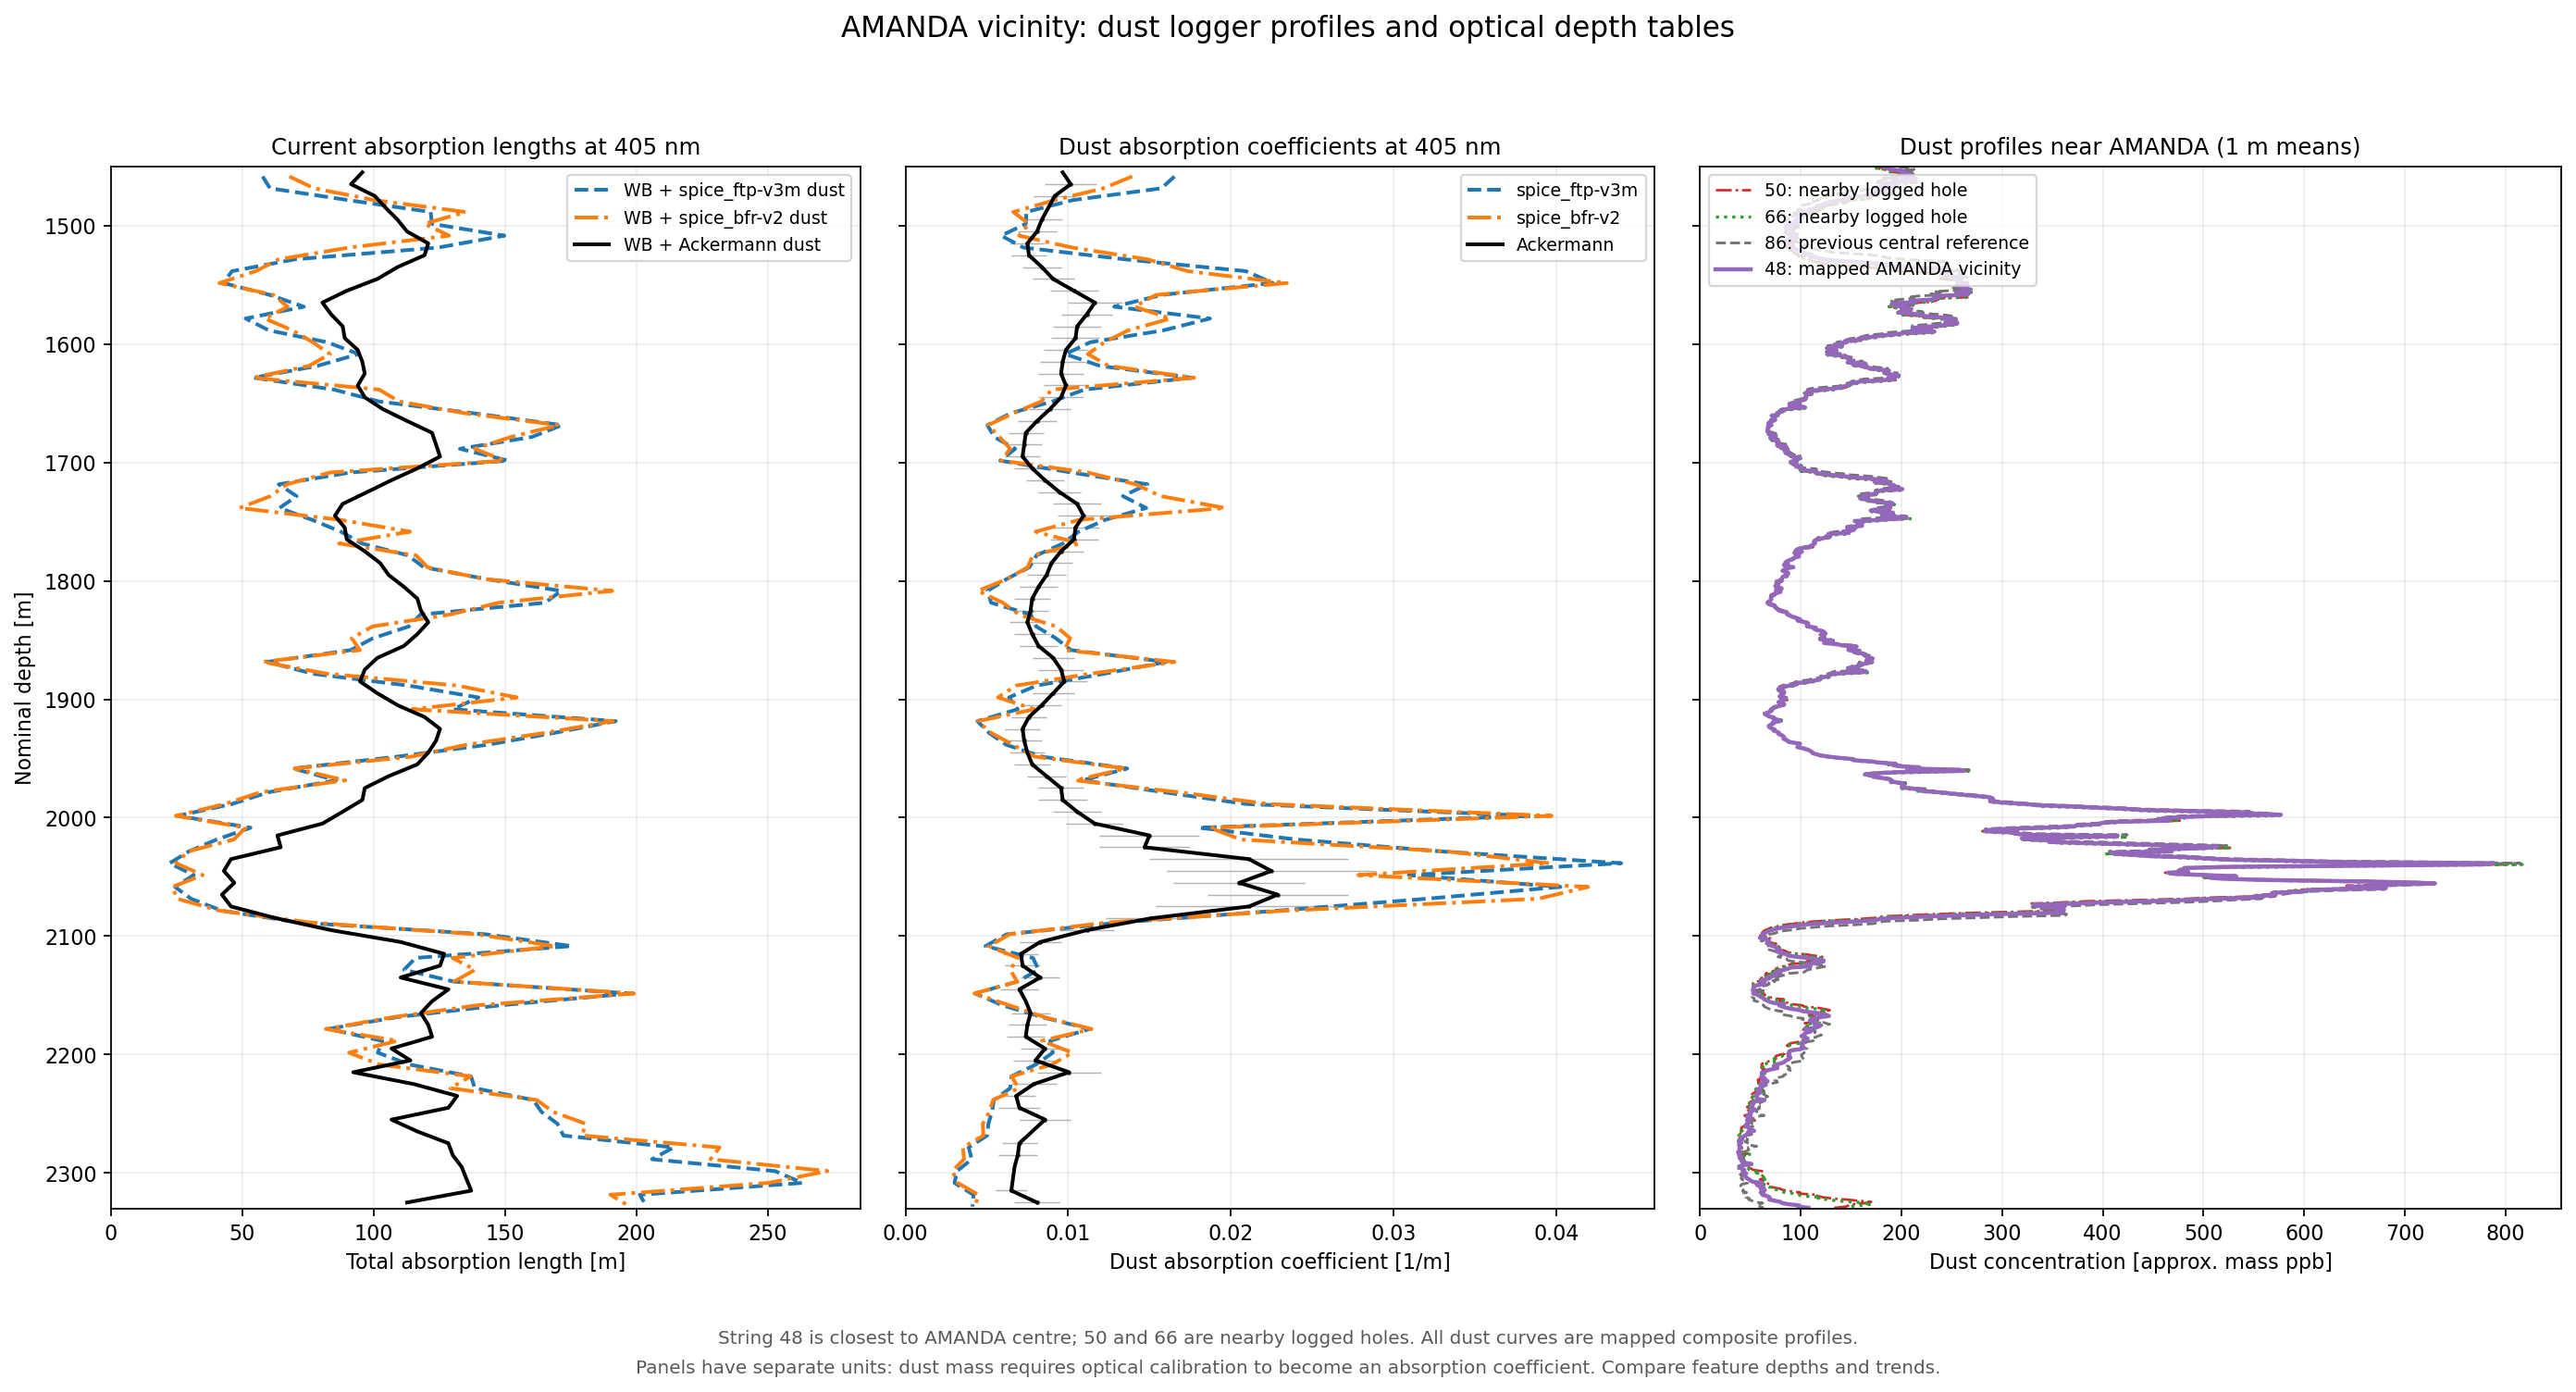

In [ ]:
# Plotting only: all profiles and coefficients were prepared in Section 2.5.
fig, (ax_amanda_length, ax_amanda_coefficient, ax_amanda_dust) = plt.subplots(
    1, 3, figsize=(17.5, 9.5), sharey=True,
    gridspec_kw={'width_ratios': (1., 1., 1.15)},
)
for (amanda_source, (amanda_depths, amanda_lengths)), amanda_color, amanda_style in zip(
    comparison_plot_data.items(), ('tab:blue', 'tab:orange', 'black'), ('--', '-.', '-')
):
    ax_amanda_length.plot(amanda_lengths, amanda_depths, color=amanda_color,
                          ls=amanda_style, lw=1.8, label=f'WB + {amanda_source} dust')
for (amanda_source, (amanda_depths, amanda_coefficients)), amanda_color, amanda_style in zip(
    amanda_coefficient_plot_data.items(), ('tab:blue', 'tab:orange', 'black'), ('--', '-.', '-')
):
    ax_amanda_coefficient.plot(amanda_coefficients, amanda_depths, color=amanda_color,
                               ls=amanda_style, lw=1.8, label=amanda_source)
ax_amanda_coefficient.errorbar(
    amanda_ack_errors.dust_absorption_per_m, amanda_ack_errors.depth_m,
    xerr=amanda_ack_errors.dust_absorption_error_per_m,
    fmt='.', ms=2.5, color='black', ecolor='0.5', elinewidth=.65, alpha=.6,
    zorder=1, label='_nolegend_',
)
for amanda_string, amanda_color, amanda_style, amanda_width, amanda_label in (
    (50, 'tab:red', '-.', 1.2, '50: nearby logged hole'),
    (66, 'tab:green', ':', 1.5, '66: nearby logged hole'),
    (86, '0.45', '--', 1.3, '86: previous central reference'),
    (48, 'tab:purple', '-', 2.0, '48: mapped AMANDA vicinity'),
):
    if amanda_string in amanda_dust_binned:
        ax_amanda_dust.plot(
            amanda_dust_binned[amanda_string].dust_mass_ppb_approx,
            amanda_dust_binned[amanda_string].depth_m,
            color=amanda_color, ls=amanda_style, lw=amanda_width, label=amanda_label,
        )
ax_amanda_length.set(
    title=f'Current absorption lengths at {COMPARISON_WAVELENGTH_NM:g} nm',
    xlabel='Total absorption length [m]', ylabel='Nominal depth [m]',
    ylim=(COMPARISON_DEPTH_RANGE_M[1], COMPARISON_DEPTH_RANGE_M[0]),
)
ax_amanda_coefficient.set(
    title=f'Dust absorption coefficients at {COMPARISON_WAVELENGTH_NM:g} nm',
    xlabel='Dust absorption coefficient [1/m]',
)
ax_amanda_dust.set(
    title=f'Dust profiles near AMANDA ({PUBLIC_DUST_BIN_WIDTH_M:g} m means)',
    xlabel='Dust concentration [approx. mass ppb]',
)
for amanda_axis in (ax_amanda_length, ax_amanda_coefficient, ax_amanda_dust):
    amanda_axis.set_xlim(left=0.)
    amanda_axis.grid(alpha=.22)
    amanda_axis.legend(loc='upper right' if amanda_axis is not ax_amanda_dust else 'upper left',
                       fontsize=8.5)
    amanda_axis.title.set_fontsize(11)
fig.suptitle('AMANDA vicinity: dust logger profiles and optical depth tables',
             fontsize=14, y=.985)
fig.text(.5, .04,
         'String 48 is closest to AMANDA centre; 50 and 66 are nearby logged holes. '
         'All dust curves are mapped composite profiles.',
         ha='center', fontsize=9, color='0.35')
fig.text(.5, .019,
         'Panels have separate units: dust mass requires optical calibration to become an absorption coefficient. '
         'Compare feature depths and trends.',
         ha='center', fontsize=9, color='0.35')
fig.tight_layout(rect=(0., .075, 1., .95))
fig.savefig(amanda_output / 'amanda_dust_coefficients_and_lengths.png', dpi=160, bbox_inches='tight')
plt.show()


### 5.4 Published South Pole laser curve versus the public Dust Map

[IceCube (2013), Figure 6b](https://doi.org/10.3189/2013JoG13J068) shows a
scaled South Pole laser signal against depth. Its violet curve was digitised
from the PDF; the grey Dome C curve was excluded. This is an **approximate
figure reconstruction**, with about **3.75 m per image column**, rather than
the original millimetre-resolution measurements. Source, pixel coordinates,
checksums and a reproducible extraction script are in `data/icecube_glaciology2013`.

The [public Dust Map](https://dustmap.icecube.wisc.edu/) files provide a
composite approximately normalised to dust mass concentration. The paper and
website share the eight-hole logging campaign, although their processing and
publication versions differ. Their agreement is therefore a consistency check,
not independent validation.

The three panels show the digitised paper curve on its native proxy scale,
website concentrations for **String 86** and **String 48**, and an overlay in
which each series is divided by its own median over the same complete depth
bins. All curves use depth averages with `PAPER_DUST_BIN_WIDTH_M` (default 10 m).
The shaded 1950-2100 m interval marks the paper's dust-rich MIS4 region. No depth
shift or optical calibration is fitted, and no absorption coefficient is inferred.

The correlation shown below the figure measures similarity of shape. The
normalised overlay does not establish equality of absolute concentrations.
Prepared comparison values and metrics are exported to
`independent_results/three_model_comparison/paper_dust_comparison/`.


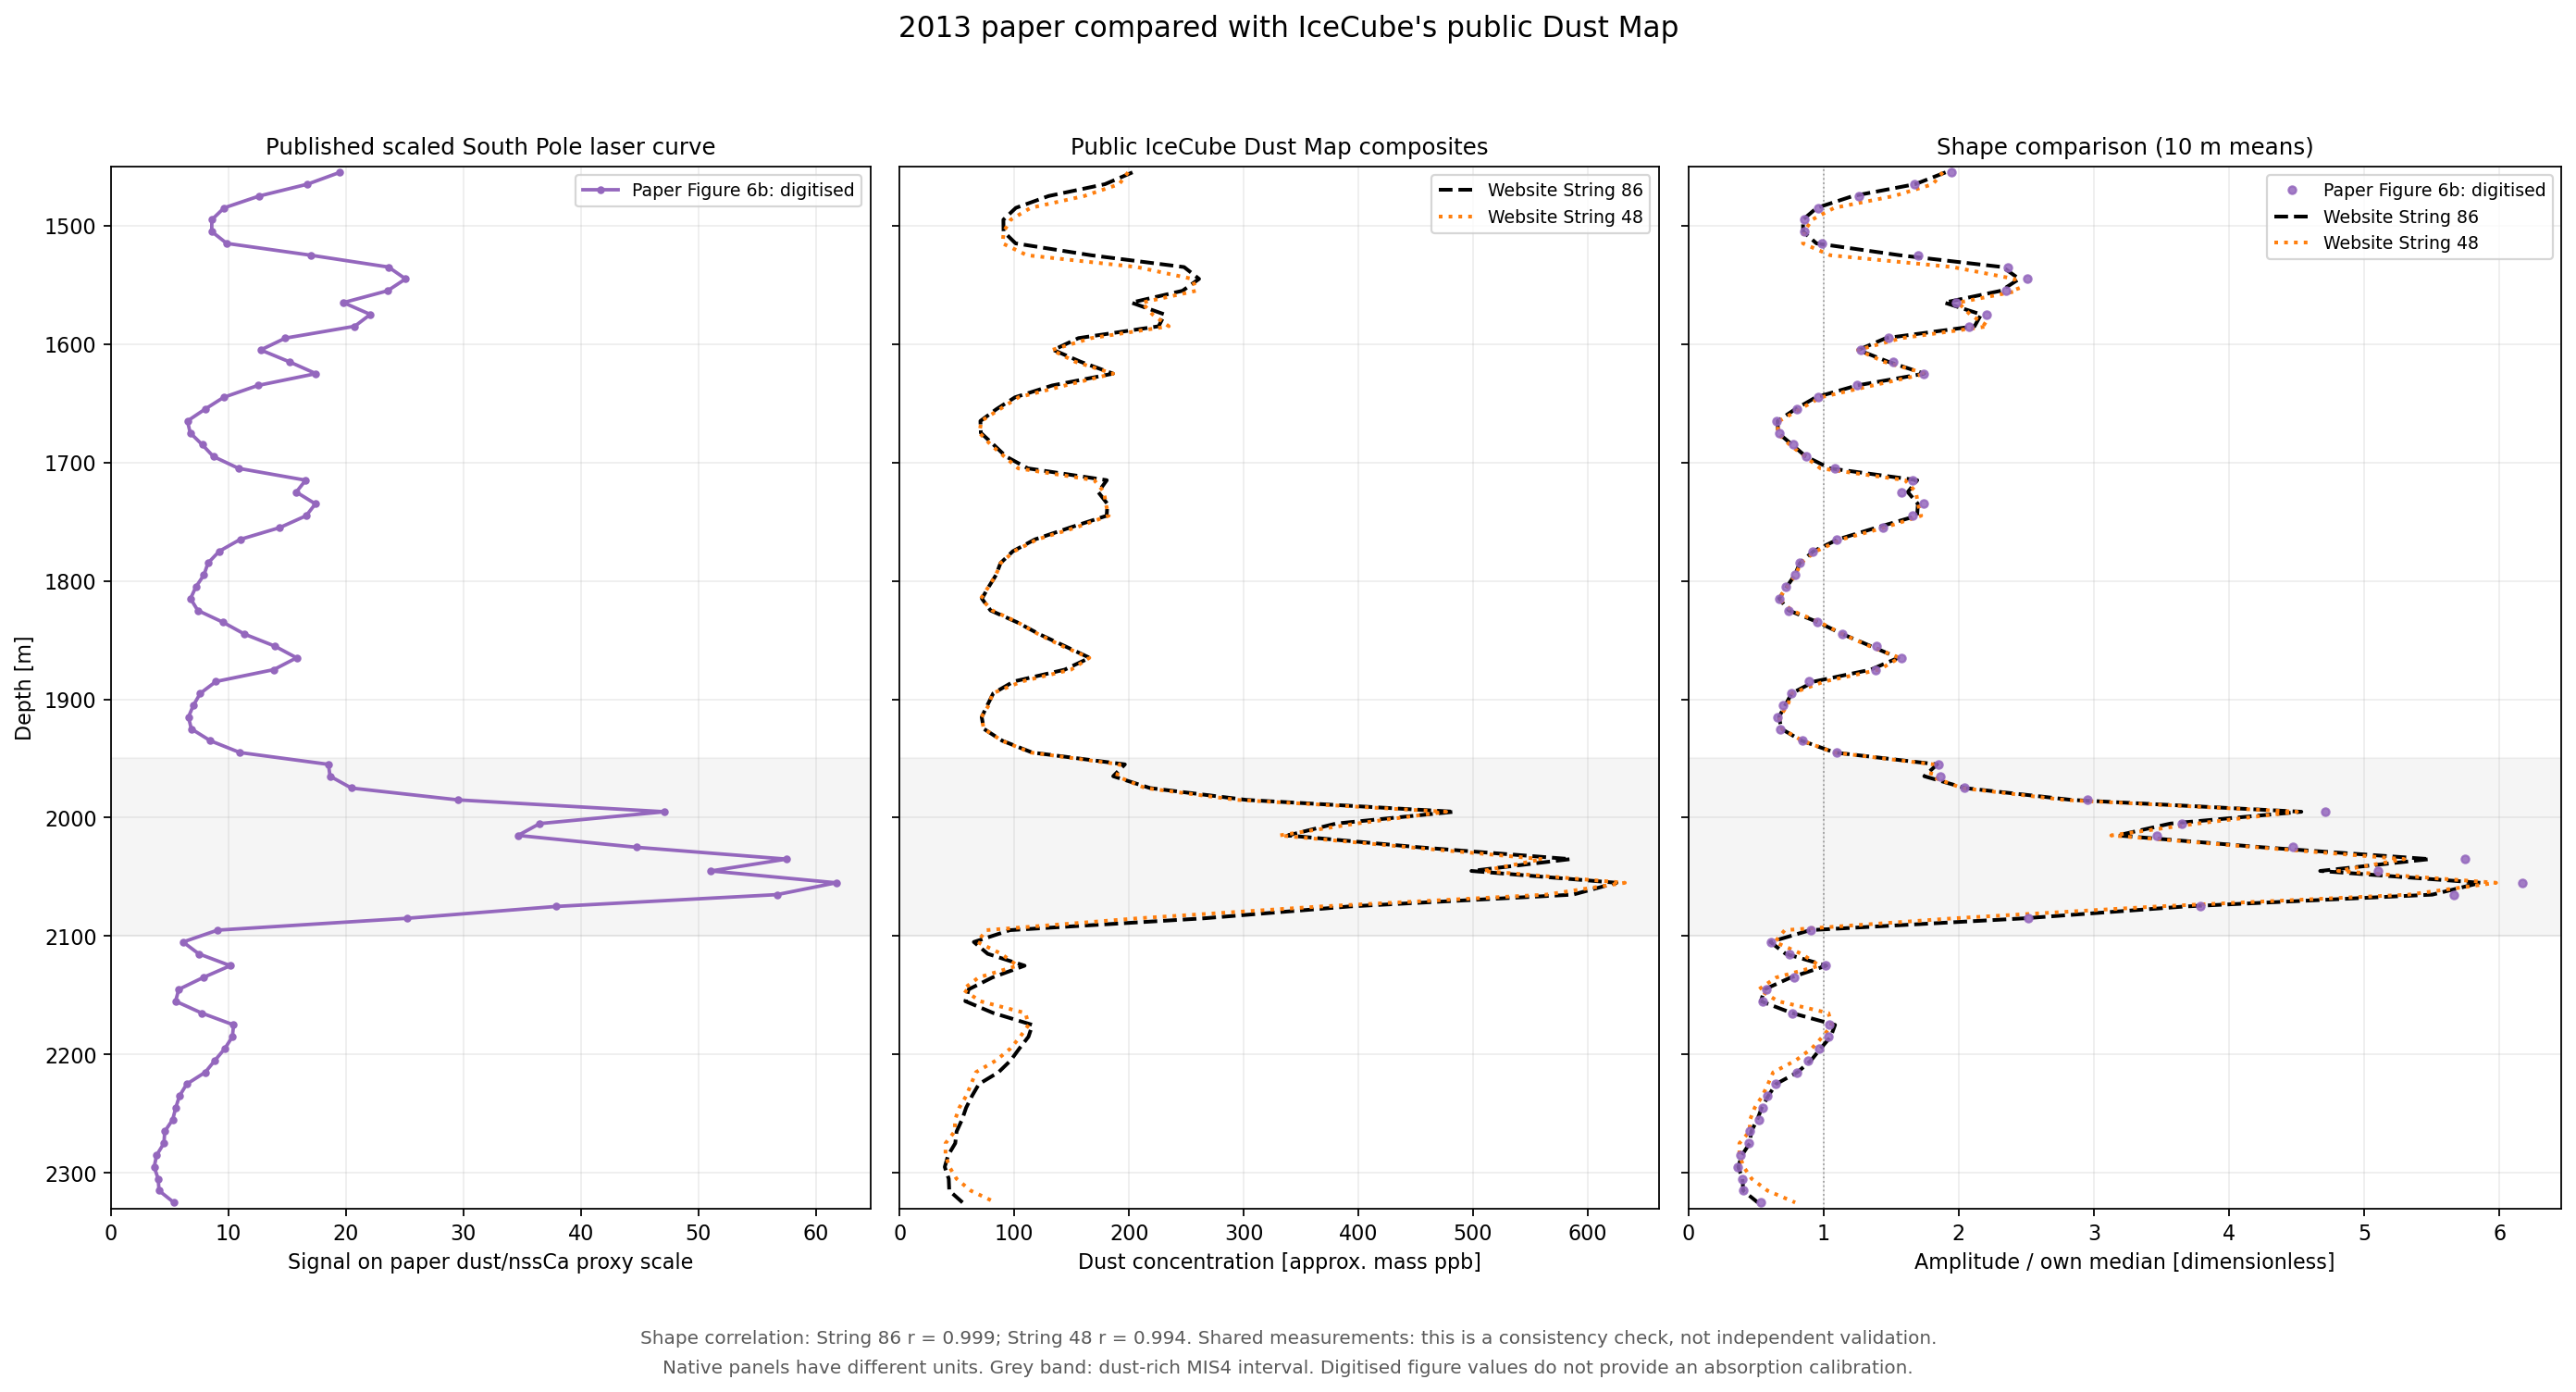

In [ ]:
# Plotting only: native-unit and normalised data were prepared in Section 2.5.
fig, (ax_paper_native, ax_paper_website, ax_paper_overlay) = plt.subplots(
    1, 3, figsize=(17.5, 9.5), sharey=True,
    gridspec_kw={'width_ratios': (1., 1., 1.15)},
)
ax_paper_native.plot(
    paper_dust_proxy_means, paper_dust_centres, color='tab:purple', lw=1.7,
    marker='o', ms=2.8, label='Paper Figure 6b: digitised',
)
ax_paper_overlay.plot(
    paper_dust_normalised, paper_dust_centres, color='tab:purple', ls='none',
    marker='o', ms=3.7, alpha=.85, label='Paper Figure 6b: digitised', zorder=3,
)
for paper_plot_string, paper_plot_color, paper_plot_style in zip(
    paper_dust_public_means, ('black', 'tab:orange', 'tab:blue', 'tab:green'),
    ('--', ':', '-.', '-'),
):
    ax_paper_website.plot(
        paper_dust_public_means[paper_plot_string], paper_dust_centres,
        color=paper_plot_color, ls=paper_plot_style, lw=1.8,
        label=f'Website String {paper_plot_string}',
    )
    ax_paper_overlay.plot(
        paper_dust_public_normalised[paper_plot_string], paper_dust_centres,
        color=paper_plot_color, ls=paper_plot_style, lw=1.8,
        label=f'Website String {paper_plot_string}',
    )
ax_paper_native.set(
    title='Published scaled South Pole laser curve',
    xlabel='Signal on paper dust/nssCa proxy scale', ylabel='Depth [m]',
    ylim=(paper_dust_edges[-1], paper_dust_edges[0]),
)
ax_paper_website.set(
    title='Public IceCube Dust Map composites',
    xlabel='Dust concentration [approx. mass ppb]',
)
ax_paper_overlay.set(
    title=f'Shape comparison ({PAPER_DUST_BIN_WIDTH_M:g} m means)',
    xlabel='Amplitude / own median [dimensionless]',
)
ax_paper_overlay.axvline(1., color='0.6', lw=.8, ls=':', zorder=0)
for paper_plot_axis in (ax_paper_native, ax_paper_website, ax_paper_overlay):
    paper_plot_axis.axhspan(1950., 2100., color='0.5', alpha=.08, zorder=0)
    paper_plot_axis.set_xlim(left=0.)
    paper_plot_axis.grid(alpha=.22)
    paper_plot_axis.legend(loc='upper right', fontsize=8.5)
    paper_plot_axis.title.set_fontsize(11)
fig.suptitle("2013 paper compared with IceCube's public Dust Map", fontsize=14, y=.985)
fig.text(.5, .04, paper_dust_caption, ha='center', fontsize=9, color='0.35')
fig.text(.5, .019,
         'Native panels have different units. Grey band: dust-rich MIS4 interval. '
         'Digitised figure values do not provide an absorption calibration.',
         ha='center', fontsize=9, color='0.35')
fig.tight_layout(rect=(0., .075, 1., .95))
fig.savefig(paper_dust_output / 'paper_vs_icecube_dust_profiles.png', dpi=160, bbox_inches='tight')
plt.show()
